**Group Members:**

- Sumbal Zehra (CS-23024)
- Fatima Mushtaq (CS-23011)
- Athar Hassan (CS-23041)
- Laiba Khan (CS-23022)

### Project Overview: Construction Incident Fatality Prediction ###

This notebook implements a comparative study of Binary Classification models to predict the fatality status of construction incidents. The system is designed to identify high-risk scenarios based on environmental and operational features.

#### Concepts Applied: ####

**Incremental Learning:** The concept of incremental learning is introduced in the algorithms. However, proper demonstration is done through an interface on the best selected model.

**Algorithms chosen for the project:**

1. Support Vector Machines

2. Logistic Regression

3. K Nearest Neighbors

4. Artificial Neural Networks

5. Naive Bayes Classifier

**Models:** A total of 15 models (3 variations per algorithm) are developed through hyperparameter tuning to find the best model.

**Objective**
The goal is to determine which model best maintains high recall while evolving through new batch data updates.

**1. Necessary Imports**

In [2]:
import os
import time
import warnings
import joblib
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    cross_val_predict
)
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import SGDClassifier
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    matthews_corrcoef,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [3]:
from google.colab import drive
import os

drive.mount('/content/drive', force_remount=True)

path = "/content/drive/MyDrive/Colab Notebooks/Machine Learning Project"
os.chdir(path)

print("will save :", os.getcwd())

Mounted at /content/drive
will save : /content/drive/MyDrive/Colab Notebooks/Machine Learning Project


In [4]:
warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


**2. Splitting the preprocessed dataset and then applying Standardization and SMOTE on it**

***Note:*** SMOTE is applied **only on the training set** to resolve class imbalance, preventing data leakage into the test set. The 80-20 split is performed first, and SMOTE is applied inside a pipeline. For cross-validation, SMOTE is applied inside each fold via `ImbPipeline` to avoid leakage into validation folds.

In [5]:
warnings.filterwarnings("ignore")
os.environ["LOKY_MAX_CPU_COUNT"] = "1"

def main():
    # 1. Load the standardized test and train data after split
    train_df = pd.read_csv('Standardized_Train.csv')
    test_df  = pd.read_csv('Standardized_Test.csv')

    X_train = train_df.drop('fatality', axis=1)
    y_train = train_df['fatality']

    X_test = test_df.drop('fatality', axis=1)
    y_test = test_df['fatality']

    # 2. SMOTE pipeline with Knn classifier and k = 5
    pipeline = ImbPipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('smote', SMOTE(random_state=42, k_neighbors=5)),
        ('classifier', KNeighborsClassifier(
            n_neighbors=5,
            metric='euclidean'
        ))
    ])

    # 3. Cross-validation (SMOTE is applied per fold inside pipeline on Training set)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1', n_jobs=1)

    print(f"Cross-validation F1 scores: {cv_scores}")
    print(f"Mean CV F1 score: {cv_scores.mean():.4f}")

    # 4. Final Model Training & Test Evaluation
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    # 5. Exporting the Balanced Training Set
    imputer = SimpleImputer(strategy='median')
    X_train_imputed = imputer.fit_transform(X_train)

    smote_exporter = SMOTE(random_state=42, k_neighbors=5)
    X_train_resampled, y_train_resampled = smote_exporter.fit_resample(X_train_imputed, y_train)

    df_train_balanced = pd.DataFrame(X_train_resampled, columns=X_train.columns)
    df_train_balanced['fatality'] = y_train_resampled

    df_train_balanced.to_csv('Balanced_Training_Set_Only.csv', index=False)
    print(f"File Saved: Balanced_Training_Set_Only.csv")
    print(f"Training set rows: {len(df_train_balanced)}")

    # 6. Exporting the Test Set
    df_test = X_test.copy()
    df_test['fatality'] = y_test.values

    df_test.to_csv('Test_Set_Only.csv', index=False)
    print(f"File Saved: Test_Set_Only.csv")
    print(f"Test set rows: {len(df_test)}")

if __name__ == "__main__":
    main()

Cross-validation F1 scores: [0.70769231 0.71186441 0.47457627 0.52631579 0.58064516]
Mean CV F1 score: 0.6002
File Saved: Balanced_Training_Set_Only.csv
Training set rows: 1736
File Saved: Test_Set_Only.csv
Test set rows: 251


**Note:** The test cases have been integrated in the algorithm's code.

***Test cases code explanation:***

The test cases filters the test set to find representative raw examples of successful hits, successful misses, and model failures. By mapping these specific cases back to their original environmental features like rainfall and temperature, it allows us to observe exactly what the model saw before making a prediction.

### Algorithm 1: Logistic Regression ###

In [6]:
np.random.seed(42)

# Reading the training and test set files
construction_incident_data = pd.read_csv('Balanced_Training_Set_Only.csv')
test_data = pd.read_csv('Test_Set_Only.csv')
y_test_lr = test_data['fatality'].values

# test data for display in test cases
test_data_raw = pd.read_csv('Test_Set_Only.csv')

# Features to display in test case breakdowns
DISPLAY_FEATURES = [
    'latitude', 'longitude',
    'temperature', 'wind_speed', 'rainfall',
    'is_repeat_site', 'permit_count',
    'unique_job_types', 'unique_work_types',
    'residential_any', 'day_incident_pct'
]

# Test cases code
def print_test_cases(model, test_data, y_test, input_features, model_name, threshold=0.5):
    X_test = test_data[input_features].values
    y_proba = model.predict_probability(X_test)
    y_pred  = (y_proba >= threshold).astype(int)
    yt      = y_test

    tp_idx  = np.where((y_pred == 1) & (yt == 1))[0]
    tn_idx  = np.where((y_pred == 0) & (yt == 0))[0]
    err_idx = np.where(y_pred != yt)[0]

    pick_tp  = tp_idx[len(tp_idx)   // 2] if len(tp_idx)  > 0 else None
    pick_tn  = tn_idx[len(tn_idx)   // 3] if len(tn_idx)  > 0 else None
    pick_err = err_idx[len(err_idx) // 2] if len(err_idx) > 0 else None

    # Define test cases with their descriptions
    cases = [
        (pick_tp,  "TC-1", "Correct   — Fatal caught          (True Positive)"),
        (pick_tn,  "TC-2", "Correct   — Non-Fatal confirmed   (True Negative)"),
        (pick_err, "TC-3", "Incorrect — model error           (FP or FN)"),
    ]

    # Print the test case breakdown
    SEP = "=" * 70
    print(SEP)
    print("  TEST CASE RESULTS BREAKDOWN")
    print(SEP)
    print(f"\n  MODEL : {model_name}")
    print(SEP)

    for (idx, tc_id, tc_desc) in cases:
        if idx is None:
            print(f"  {tc_id}: no qualifying sample found.")
            continue
        # Extracting details for the selected test case sample
        prob_val   = float(y_proba[idx])
        pred_int   = int(y_pred[idx])
        actual_int = int(yt[idx])
        pred_str   = "FATAL"   if pred_int   == 1 else "NON-FATAL"
        actual_str = "FATAL"   if actual_int == 1 else "NON-FATAL"
        verdict    = "CORRECT" if pred_int   == actual_int else "WRONG"

        print(f"\n  ┌─ {tc_id}  |  {tc_desc}")
        print( "  │")
        print(f"  │  Test-set sample index      : {idx}")
        print(f"  │  PREDICTED PROBABILITY      : {prob_val:.6f}")
        print( "  │  INPUT FEATURES:")
        row = test_data_raw.iloc[idx]
        for feat in DISPLAY_FEATURES:
            if feat in row.index:
                val = row[feat]
                v   = f"{val:.4f}" if isinstance(val, float) else str(val)
                print(f"  │    {feat:<30}: {v}")
        print( "  │")
        print(f"  │  PREDICTED LABEL  →  {pred_str:<12}  (encoded = {pred_int})")
        print(f"  │  ACTUAL LABEL     →  {actual_str:<12}  (encoded = {actual_int})")
        print(f"  │  OUTCOME          →  {verdict}")
        print( "  └" + "─" * 60)

    print()
    print(SEP)
    print("  Test set used : held-out 20% stratified split  (no data leakage)")
    print(SEP)

@dataclass
class ExperimentSettings:
    learning_rate: float
    number_epochs: int
    batch_size: int
    input_features: list
    optimizer: str = "mini-batch"
    momentum: float = 0.9
    lambda_reg: float = 0.0

# Creating the logistic regression class with Incremental learning based approach.

# Setting the parameters of the class
class LogisticRegressionModel:
    # Initialising the Logistic Regression Class
    def __init__(self, n_features, learning_rate, optimizer='mini-batch',
                 batch_size=32, momentum=0.9, lambda_reg=0.0):
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.lr = learning_rate
        self.optimizer = optimizer
        self.batch_size = batch_size
        self.iterations = 0
        self.momentum = momentum
        self.lambda_reg = lambda_reg
        self.v_w = np.zeros(n_features)
        self.v_b = 0.0

    # Function that calculates z using Sigmoid Function
    def sigmoid(self, X):
        z = np.dot(X, self.weights) + self.bias
        return 1 / (1 + np.exp(-z))

    # Function used to find the predicted y in the form of probability
    def predict_probability(self, X):
        return self.sigmoid(X)

    #using the standard threshold of 0.5 to predict the class labels
    def predict(self, X, threshold=0.5):
        return np.where(self.predict_probability(X) > threshold, 1, 0)

    # Function used to compute the gradients in every pass with L2 regularization
    def compute_gradients(self, X, y):
        y_pred = self.predict_probability(X)
        error = y_pred - y
        n = len(y)
        dw = (1/n) * (X.T @ error) + (self.lambda_reg * self.weights)
        db = (1/n) * np.sum(error)
        return dw, db

    # Function used to update the parameters using either mini-batch or Momentum based GD.
    # The learning rate is adaptive and decays over iterations.
    def update_parameters(self, dw, db):
        self.iterations += 1
        adaptive_lr = self.lr / (1 + 0.0001 * self.iterations)

        # Momentum-based Gradient Descent
        if self.optimizer == 'Momentum':
            self.v_w = (self.momentum * self.v_w) + (adaptive_lr * dw)
            self.v_b = (self.momentum * self.v_b) + (adaptive_lr * db)
            self.weights -= self.v_w
            self.bias -= self.v_b
        else:
            # Default to mini-batch gradient descent
            self.weights -= adaptive_lr * dw
            self.bias -= adaptive_lr * db

    # computing the log loss for the predicted probabilities and true labels
    def logloss(self, y, y_pred):
        y_pred_clip = np.clip(y_pred, 1e-15, 1 - 1e-15)
        return -np.mean(y * np.log(y_pred_clip) + (1 - y) * np.log(1 - y_pred_clip))

    # function for incremental learning by processing data in batches and updating parameters iteratively
    def partially_fit(self, X, y):
        n_samples = len(y)
        indices = np.arange(n_samples)
        # Shuffling the indices to ensure random sampling for mini-batches
        np.random.shuffle(indices)
        for start in range(0, n_samples, self.batch_size):
            batch_idx = indices[start:start + self.batch_size]
            dw, db = self.compute_gradients(X[batch_idx], y[batch_idx])
            self.update_parameters(dw, db)

# Generator function to read the dataset in batches for incremental learning
def streaming_batches(dataset_path, features, label, batch_size):
    for chunk in pd.read_csv(dataset_path, chunksize=batch_size):
        X_batch = chunk[features].values
        y_batch = chunk[label].values
        yield X_batch, y_batch

# Function to train the model incrementally and track log loss over epochs and batches
def train_model_incrementally(experiment_name, model, dataset_path,
                               label_name, settings, verbose=True):
    history = {"logloss": [], "epoch": [], "batch": []}
    total_samples_processed = 0
    batch_number = 0

    # Loop over epochs
    for epoch in range(settings.number_epochs):
        epoch_loss = []
        data_stream = pd.read_csv(dataset_path, chunksize=settings.batch_size)

        # Process each batch in the current epoch
        for chunk in data_stream:
            X_batch = chunk[settings.input_features].values
            y_batch = chunk[label_name].values

            y_pred_batch = model.predict_probability(X_batch)
            batch_loss   = model.logloss(y_batch, y_pred_batch)

            history["logloss"].append(batch_loss)
            history["epoch"].append(epoch + 1)
            history["batch"].append(batch_number)
            epoch_loss.append(batch_loss)

            model.partially_fit(X_batch, y_batch)
            total_samples_processed += len(y_batch)
            batch_number += 1

        avg_epoch_loss = np.mean(epoch_loss)
        if verbose:
            print(f"Epoch {epoch+1:03d}/{settings.number_epochs} | "
                  f"Avg LogLoss: {avg_epoch_loss:.4f} | "
                  f"Samples Seen: {total_samples_processed}")

    return {
        "name": experiment_name,
        "settings": settings,
        "model": model,
        "metrics_history": pd.DataFrame(history)
    }

# function to analyze the training history and report on incremental learning performance
def test_incremental_learning(experiment_results):
    # Analyze the log loss history to evaluate learning progress and final performance
    history = experiment_results["metrics_history"]
    window  = min(50, len(history) // 10)
    history['smoothed_loss'] = history['logloss'].rolling(window=window, min_periods=1).mean()

    # Calculate improvement from the start to the end of training
    initial_loss = history['smoothed_loss'].iloc[0]
    final_loss   = history['smoothed_loss'].iloc[-1]
    improvement  = (initial_loss - final_loss) / initial_loss * 100

    print(f"--- Diagnostic Report: {experiment_results['name']} ---")
    print(f"Initial Smoothed Loss : {initial_loss:.4f}")
    print(f"Final Smoothed Loss   : {final_loss:.4f}")
    print(f"Improvement           : {improvement:.1f}%")
    if final_loss < 0.693:
        print("Model is performing better than random guessing.")
    else:
        print("Model is not outperforming random guessing.")


### LR Models Hyperparameters

| Model | Optimizer | LR | Epochs | Batch | Lambda | What it tests |
|---|---|---|---|---|---|---|
| M1 | Mini-batch | 0.1 | 800 | 50 | 0.0 | Baseline: high-lr, no regularization |
| M2 | Mini-batch | 0.01 | 500 | 50 | 0.0 | Effect of lower learning rate |
| M3 | Momentum | 0.01 | 400 | 50 | 0.01 | Effect of momentum + L2 regularization |

### Logistic Regression: Model 1 ###

In [7]:
settings_1 = ExperimentSettings(
    learning_rate=0.1,
    number_epochs=800,
    batch_size=50,
    input_features=[
        'latitude', 'longitude',
        'temperature', 'wind_speed', 'rainfall',
        'is_repeat_site',
        'permit_count',
        'unique_job_types', 'unique_work_types',
        'residential_any',
        'day_incident_pct',
        'check2 description_Struck By',
        'check2 description_Worker Fell',
        'check2 description_Material Failure (Fell)',
        'check2 description_Scaffold/Shoring Installations',
        'check2 description_Other Construction Related',
        'check2 description_Mechanical Construction Equipment',
        'borough_Manhattan',
        'borough_Brooklyn',
        'borough_Queens',
        'borough_Staten Island'
    ],
    optimizer="mini-batch",
    lambda_reg=0.0,
)

def create_model_1(settings):
    return LogisticRegressionModel(
        n_features=len(settings.input_features),
        learning_rate=settings.learning_rate,
        optimizer=settings.optimizer,
        batch_size=settings.batch_size,
        momentum=settings.momentum,
        lambda_reg=settings.lambda_reg,
    )

model_1 = create_model_1(settings_1)

experiment_1 = train_model_incrementally(
    experiment_name="M1_LogReg",
    model=model_1,
    dataset_path="Balanced_Training_Set_Only.csv",
    label_name="fatality",
    settings=settings_1,
    verbose=False
)

test_incremental_learning(experiment_1)

y_pred_test = model_1.predict(test_data[settings_1.input_features].values)
print("\nTest Set Classification Report:")
print(classification_report(y_test_lr, y_pred_test, target_names=['Non-Fatal', 'Fatal']))

print_test_cases(model_1, test_data, y_test_lr, settings_1.input_features, "M1_LogReg")

--- Diagnostic Report: M1_LogReg ---
Initial Smoothed Loss : 0.6931
Final Smoothed Loss   : 0.1843
Improvement           : 73.4%
Model is performing better than random guessing.

Test Set Classification Report:
              precision    recall  f1-score   support

   Non-Fatal       0.96      0.97      0.97       218
       Fatal       0.78      0.76      0.77        33

    accuracy                           0.94       251
   macro avg       0.87      0.86      0.87       251
weighted avg       0.94      0.94      0.94       251

  TEST CASE RESULTS BREAKDOWN

  MODEL : M1_LogReg

  ┌─ TC-1  |  Correct   — Fatal caught          (True Positive)
  │
  │  Test-set sample index      : 141
  │  PREDICTED PROBABILITY      : 0.904977
  │  INPUT FEATURES:
  │    latitude                      : -1.0630
  │    longitude                     : -3.2866
  │    temperature                   : 1.2938
  │    wind_speed                    : 0.6366
  │    rainfall                      : 0.0573
  │    i

### Logistic Regression: Model 2 ###

In [8]:
settings_2 = ExperimentSettings(
    learning_rate=0.05,
    number_epochs=1000,
    batch_size=50,
    input_features=settings_1.input_features,
    lambda_reg=0.01,
)

def create_model_2(settings):
    return LogisticRegressionModel(
        n_features=len(settings.input_features),
        learning_rate=settings.learning_rate,
        batch_size=settings.batch_size,
        lambda_reg=settings.lambda_reg,
    )

model_2 = create_model_2(settings_2)

experiment_2 = train_model_incrementally(
    experiment_name="M2_LogReg-Mini-batch",
    model=model_2,
    dataset_path="Balanced_Training_Set_Only.csv",
    label_name="fatality",
    settings=settings_2,
    verbose=False
)

test_incremental_learning(experiment_2)

y_pred_test = model_2.predict(test_data[settings_2.input_features].values)
print("\nTest Set Classification Report:")
print(classification_report(y_test_lr, y_pred_test, target_names=['Non-Fatal', 'Fatal']))

print_test_cases(model_2, test_data, y_test_lr, settings_2.input_features, "M2_LogReg-Mini-batch")

--- Diagnostic Report: M2_LogReg-Mini-batch ---
Initial Smoothed Loss : 0.6931
Final Smoothed Loss   : 0.3121
Improvement           : 55.0%
Model is performing better than random guessing.

Test Set Classification Report:
              precision    recall  f1-score   support

   Non-Fatal       0.96      0.89      0.92       218
       Fatal       0.51      0.79      0.62        33

    accuracy                           0.87       251
   macro avg       0.74      0.84      0.77       251
weighted avg       0.91      0.87      0.88       251

  TEST CASE RESULTS BREAKDOWN

  MODEL : M2_LogReg-Mini-batch

  ┌─ TC-1  |  Correct   — Fatal caught          (True Positive)
  │
  │  Test-set sample index      : 141
  │  PREDICTED PROBABILITY      : 0.733913
  │  INPUT FEATURES:
  │    latitude                      : -1.0630
  │    longitude                     : -3.2866
  │    temperature                   : 1.2938
  │    wind_speed                    : 0.6366
  │    rainfall                 

### Logistic Regression: Model 3 ###

In [9]:
settings_3 = ExperimentSettings(
    learning_rate=0.05,
    number_epochs=1000,
    batch_size=50,
    input_features=settings_1.input_features,
    optimizer="Momentum",
    momentum=0.9,
)

def create_model_3(settings):
    return LogisticRegressionModel(
        n_features=len(settings.input_features),
        learning_rate=settings.learning_rate,
        optimizer=settings.optimizer,
        batch_size=settings.batch_size,
        momentum=settings.momentum,
        lambda_reg=settings.lambda_reg,
    )

model_3 = create_model_3(settings_3)

experiment_3 = train_model_incrementally(
    experiment_name="M3_Momentum_LogReg",
    model=model_3,
    dataset_path="Balanced_Training_Set_Only.csv",
    label_name="fatality",
    settings=settings_3,
    verbose=False
)

test_incremental_learning(experiment_3)

y_pred_test = model_3.predict(test_data[settings_3.input_features].values)
print("\nTest Set Classification Report:")
print(classification_report(y_test_lr, y_pred_test, target_names=['Non-Fatal', 'Fatal']))

print_test_cases(model_3, test_data, y_test_lr, settings_3.input_features, "M3_Momentum_LogReg")


--- Diagnostic Report: M3_Momentum_LogReg ---
Initial Smoothed Loss : 0.6931
Final Smoothed Loss   : 0.1641
Improvement           : 76.3%
Model is performing better than random guessing.

Test Set Classification Report:
              precision    recall  f1-score   support

   Non-Fatal       0.97      0.99      0.98       218
       Fatal       0.90      0.79      0.84        33

    accuracy                           0.96       251
   macro avg       0.93      0.89      0.91       251
weighted avg       0.96      0.96      0.96       251

  TEST CASE RESULTS BREAKDOWN

  MODEL : M3_Momentum_LogReg

  ┌─ TC-1  |  Correct   — Fatal caught          (True Positive)
  │
  │  Test-set sample index      : 174
  │  PREDICTED PROBABILITY      : 0.999999
  │  INPUT FEATURES:
  │    latitude                      : -2.7543
  │    longitude                     : 0.2506
  │    temperature                   : -0.2568
  │    wind_speed                    : -0.7325
  │    rainfall                    

### LR RESULTS: CHECKING UNDERFITTING, OVERFITTING AND CROSS VALIDATION ###

In [10]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, recall_score, f1_score, precision_score, roc_auc_score
import numpy as np

SEP  = "=" * 70
SEP2 = "-" * 68

X_train_arr = construction_incident_data[settings_1.input_features].values
y_train_arr = construction_incident_data['fatality'].values
X_test_arr  = test_data[settings_1.input_features].values

def train_fresh_lr(settings, X, y, n_epochs):
    m = LogisticRegressionModel(
        n_features    = len(settings.input_features),
        learning_rate = settings.learning_rate,
        optimizer     = settings.optimizer,
        batch_size    = settings.batch_size,
        momentum      = settings.momentum,
        lambda_reg    = settings.lambda_reg,
    )
    for _ in range(n_epochs):
        m.partially_fit(X, y)
    return m

lr_configs = [
    ("M1", "Mini-Batch  lr=0.1  ep=800",  model_1, settings_1, 800),
    ("M2", "SGD         lr=0.05 ep=1000", model_2, settings_2, 1000),
    ("M3", "Momentum    lr=0.05 ep=1000", model_3, settings_3, 1000),
]

print(SEP)
print("  LOGISTIC REGRESSION — OVERFITTING / UNDERFITTING DIAGNOSTIC")
print(SEP)

for i, (mid, desc, model, settings, epochs) in enumerate(lr_configs):
    train_preds  = model.predict(X_train_arr)
    test_preds   = model.predict(X_test_arr)
    # predict_probability() is the correct method name from your class
    train_probs  = model.predict_probability(X_train_arr)
    test_probs   = model.predict_probability(X_test_arr)

    train_recall = recall_score(y_train_arr, train_preds, zero_division=0)
    test_recall  = recall_score(y_test_lr,   test_preds,  zero_division=0)
    train_f1     = f1_score(y_train_arr, train_preds, zero_division=0)
    test_f1      = f1_score(y_test_lr,   test_preds,  zero_division=0)
    test_prec    = precision_score(y_test_lr, test_preds, zero_division=0)
    test_auc     = roc_auc_score(y_test_lr, test_probs)
    gap_recall   = train_recall - test_recall
    gap_f1       = train_f1    - test_f1

    cm             = confusion_matrix(y_test_lr, test_preds)
    tn, fp, fn, tp = cm.ravel()
    total_fatal    = tp + fn

    if test_recall < 0.60:
        verdict = "UNDERFITTING — fatal recall too low, missing incidents"
    elif test_prec < 0.15:
        verdict = "DEGENERATE   — precision too low, predicting fatal for everything"
    elif gap_recall > 0.15:
        verdict = "OVERFITTING  — recall drops significantly on unseen data"
    elif gap_f1 > 0.10:
        verdict = "MILD OVERFIT — F1 gap notable between train and test"
    else:
        verdict = "GOOD FIT"

    print(f"\n  Model {i+1} ({mid})  |  LogReg  {desc}")
    print(f"  {SEP2}")
    print(f"  {'Metric':<28}  {'Train':>8}  {'Test':>8}  {'Gap':>8}")
    print(f"  {SEP2}")
    print(f"  {'Recall (Fatal)':<28}  {train_recall:>8.4f}  {test_recall:>8.4f}  {gap_recall:>+8.4f}  <- primary")
    print(f"  {'F1-Score (Fatal)':<28}  {train_f1:>8.4f}  {test_f1:>8.4f}  {gap_f1:>+8.4f}  <- secondary")
    print(f"  {'AUC-ROC':<28}  {'  —':>8}  {test_auc:>8.4f}  {'  —':>8}")
    print(f"  {'Precision (Fatal)':<28}  {'  —':>8}  {test_prec:>8.4f}  {'  —':>8}  <- floor check")
    print(f"  {SEP2}")
    print(f"  Fatal incidents caught  :  {tp} / {total_fatal}  (missed: {fn})")
    print(f"  False alarms raised     :  {fp}")
    print(f"  Fit verdict             :  {verdict}")

print(f"\n{SEP}")

# ── 5-Fold Cross-Validation ───────────────────────────────────────────────────
print("\n")
print(SEP)
print("  LOGISTIC REGRESSION — 5-FOLD CROSS-VALIDATION")
print(SEP)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_configs = [
    ("M1", settings_1, 800),
    ("M2", settings_2, 1000),
    ("M3", settings_3, 1000),
]

for mid, settings, epochs in cv_configs:
    fold_recalls = []
    fold_f1s     = []
    fold_aucs    = []

    for train_idx, val_idx in skf.split(X_train_arr, y_train_arr):
        X_tr, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
        y_tr, y_val = y_train_arr[train_idx], y_train_arr[val_idx]

        fold_model = train_fresh_lr(settings, X_tr, y_tr, n_epochs=epochs)
        val_preds  = fold_model.predict(X_val)
        val_probs  = fold_model.predict_probability(X_val)   # correct method

        fold_recalls.append(recall_score(y_val, val_preds, zero_division=0))
        fold_f1s.append(f1_score(y_val, val_preds, zero_division=0))
        fold_aucs.append(roc_auc_score(y_val, val_probs))

    r_mean, r_std = np.mean(fold_recalls), np.std(fold_recalls)
    f_mean, f_std = np.mean(fold_f1s),     np.std(fold_f1s)
    a_mean, a_std = np.mean(fold_aucs),    np.std(fold_aucs)
    stability     = "stable" if r_std <= 0.05 else "high variance — unstable across folds"

    print(f"\n  Model {mid}")
    print(f"  Fold Recalls :  {[round(f, 4) for f in fold_recalls]}")
    print(f"  Mean Recall  :  {r_mean:.4f}   |   Std: {r_std:.4f}   |   {stability}   <- primary")
    print(f"  Mean F1      :  {f_mean:.4f}   |   Std: {f_std:.4f}")
    print(f"  Mean AUC     :  {a_mean:.4f}   |   Std: {a_std:.4f}")

print(f"\n{SEP}\n")

  LOGISTIC REGRESSION — OVERFITTING / UNDERFITTING DIAGNOSTIC

  Model 1 (M1)  |  LogReg  Mini-Batch  lr=0.1  ep=800
  --------------------------------------------------------------------
  Metric                           Train      Test       Gap
  --------------------------------------------------------------------
  Recall (Fatal)                  0.8917    0.7576   +0.1341  <- primary
  F1-Score (Fatal)                0.9303    0.7692   +0.1611  <- secondary
  AUC-ROC                              —    0.8788         —
  Precision (Fatal)                    —    0.7812         —  <- floor check
  --------------------------------------------------------------------
  Fatal incidents caught  :  25 / 33  (missed: 8)
  False alarms raised     :  7
  Fit verdict             :  MILD OVERFIT — F1 gap notable between train and test

  Model 2 (M2)  |  LogReg  SGD         lr=0.05 ep=1000
  --------------------------------------------------------------------
  Metric                         

### Logistic Regression Graphs ###

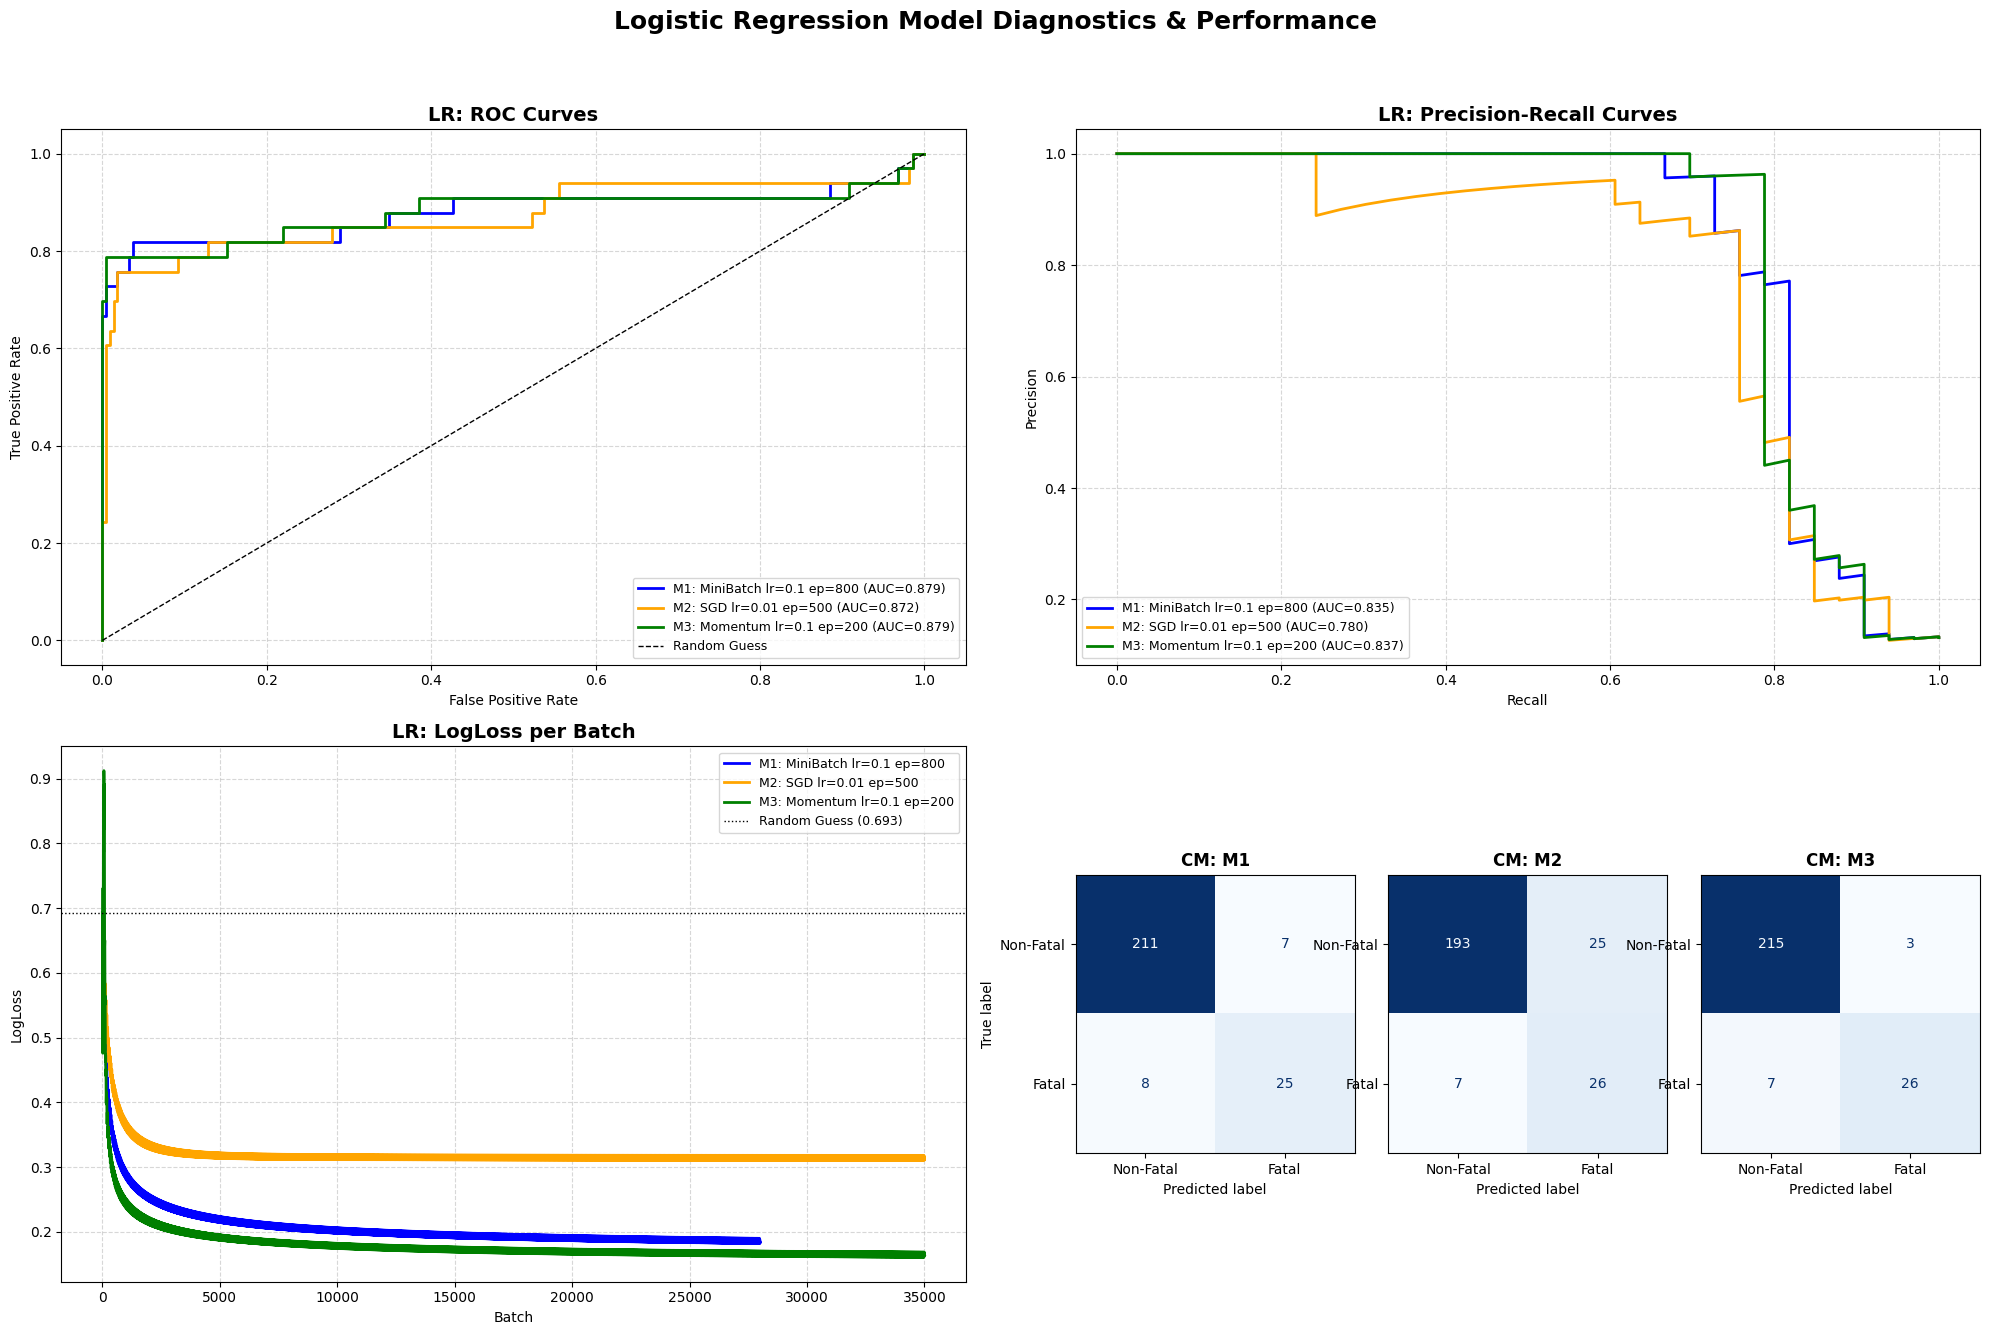

In [11]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

X_test_lr = test_data[settings_1.input_features].values

LR_MODELS = [
    (model_1, "M1: MiniBatch lr=0.1 ep=800", "blue"),
    (model_2, "M2: SGD lr=0.01 ep=500",      "orange"),
    (model_3, "M3: Momentum lr=0.1 ep=200",  "green"),
]

fig = plt.figure(figsize=(20, 14))
fig.suptitle("Logistic Regression Model Diagnostics & Performance", fontsize=18, fontweight='bold')

gs = fig.add_gridspec(2, 2)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])

for model, label, color in LR_MODELS:
    y_scores = model.predict_probability(X_test_lr)
    fpr, tpr, _ = roc_curve(y_test_lr, y_scores)
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, color=color, linewidth=2, label=f"{label} (AUC={roc_auc:.3f})")

ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess')
ax1.set_title("LR: ROC Curves", fontsize=14, fontweight='bold')
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.legend(fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.5)

for model, label, color in LR_MODELS:
    y_scores = model.predict_probability(X_test_lr)
    precision, recall, _ = precision_recall_curve(y_test_lr, y_scores)
    pr_auc = auc(recall, precision)
    ax2.plot(recall, precision, color=color, linewidth=2, label=f"{label} (AUC={pr_auc:.3f})")

ax2.set_title("LR: Precision-Recall Curves", fontsize=14, fontweight='bold')
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.legend(fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.5)

for exp, (_, label, color) in zip([experiment_1, experiment_2, experiment_3], LR_MODELS):
    history = exp['metrics_history']['logloss']
    window = min(50, len(history) // 10)
    smoothed = history.rolling(window=window, min_periods=1).mean()
    ax3.plot(smoothed, color=color, linewidth=2, label=label)

ax3.axhline(y=0.693, color='black', linestyle=':', linewidth=1, label='Random Guess (0.693)')
ax3.set_title("LR: LogLoss per Batch", fontsize=14, fontweight='bold')
ax3.set_xlabel("Batch")
ax3.set_ylabel("LogLoss")
ax3.legend(fontsize=9)
ax3.grid(True, linestyle='--', alpha=0.5)

sub_gs = gs[1, 1].subgridspec(1, 3)
for i, (model, label, color) in enumerate(LR_MODELS):
    ax = fig.add_subplot(sub_gs[0, i])
    y_pred_lr = model.predict(X_test_lr)
    cm_lr = confusion_matrix(y_test_lr, y_pred_lr)
    disp_lr = ConfusionMatrixDisplay(cm_lr, display_labels=['Non-Fatal', 'Fatal'])
    disp_lr.plot(ax=ax, colorbar=False, cmap='Blues')

    short_name = label.split(":")[0]
    ax.set_title(f"CM: {short_name}", fontsize=12, fontweight='bold')
    if i > 0:
        ax.set_ylabel("")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Observations from the Graphs:**

1. The ROC indicates that all the three models performed better than random guessing. M1 and M3 are tied for the highest AUC (0.879), indicating they have the best overall ability to distinguish between the two classes.

2. The Precision-Recall curve indicates that models M1 and M3 maintain high precision for much longer than M2 as recall increases, meaning they are more reliable.

3. The Logloss per batch curve indicates that all the models achieved convergence with M3 achieving the lowest logloss.

4. The Confusion matrix indicates the following:

- Model M3 shows the best overall performance, correctly identifying the highest number of non-fatal (215) and fatal (26) incidents while minimizing false alarms to only 3.

- Model M2 is the least precise, generating significantly more false alarms (25) compared to M1 and M3, which reduces its reliability for non-fatal predictions.

- All three models maintain a similar Recall, missing between 7 and 8 actual fatal incidents (False Negatives) across the test set.

- Model M1 offers a middle-ground performance, catching 25 fatalities with fewer false alarms (7) than M2 but more than M3.

### Algorithm 2: K Nearest Neighbours ###

**Note:**

To improve Fatal class recall, we used **vote-threshold tuning** which is the equivalent of probability threshold tuning in Logistic Regression.

Instead of requiring a strict majority (>50% of neighbours voting Fatal), we predict Fatal if the proportion of Fatal votes meets a lower threshold. This explicitly trades precision for recall, which is appropriate for a safety-critical system where missing a fatal incident is far costlier than a false alarm.

In [12]:
from dataclasses import dataclass, field
from collections import Counter
import tempfile, os

np.random.seed(42)

# loading the balanced training set and test set for use in test case functions
construction_incident_data = pd.read_csv('Balanced_Training_Set_Only.csv')
test_data     = pd.read_csv('Test_Set_Only.csv')
test_data_raw = pd.read_csv('Test_Set_Only.csv')
y_test_lr     = test_data['fatality'].values

# features to display in test case breakdowns
def print_test_cases_knn(model, X_test, y_test, model_name):
    y_proba = model.fatal_vote_proportion(X_test)
    y_pred  = model.predict(X_test)
    yt      = y_test

    tp_idx  = np.where((y_pred == 1) & (yt == 1))[0]
    tn_idx  = np.where((y_pred == 0) & (yt == 0))[0]
    err_idx = np.where(y_pred != yt)[0]

    pick_tp  = tp_idx[len(tp_idx)   // 2] if len(tp_idx)  > 0 else None
    pick_tn  = tn_idx[len(tn_idx)   // 3] if len(tn_idx)  > 0 else None
    pick_err = err_idx[len(err_idx) // 2] if len(err_idx) > 0 else None

    cases = [
        (pick_tp,  "TC-1", "Correct   — Fatal caught          (True Positive)"),
        (pick_tn,  "TC-2", "Correct   — Non-Fatal confirmed   (True Negative)"),
        (pick_err, "TC-3", "Incorrect — model error           (FP or FN)"),
    ]

    SEP = "=" * 70
    print(SEP)
    print("  TEST CASE RESULTS BREAKDOWN")
    print(SEP)
    print(f"\n  MODEL : {model_name}")
    print(SEP)

    for (idx, tc_id, tc_desc) in cases:
        if idx is None:
            print(f"  {tc_id}: no qualifying sample found.")
            continue
        # Extracting details for the selected test case sample
        prob_val   = float(y_proba[idx])
        pred_int   = int(y_pred[idx])
        actual_int = int(yt[idx])
        pred_str   = "FATAL"   if pred_int   == 1 else "NON-FATAL"
        actual_str = "FATAL"   if actual_int == 1 else "NON-FATAL"
        verdict    = "CORRECT" if pred_int   == actual_int else "WRONG"

        print(f"\n  ┌─ {tc_id}  |  {tc_desc}")
        print( "  │")
        print(f"  │  Test-set sample index      : {idx}")
        print(f"  │  FATAL VOTE PROPORTION      : {prob_val:.6f}")
        print( "  │  INPUT FEATURES:")
        row = test_data_raw.iloc[idx]
        for feat in DISPLAY_FEATURES:
            if feat in row.index:
                val = row[feat]
                v   = f"{val:.4f}" if isinstance(val, float) else str(val)
                print(f"  │    {feat:<30}: {v}")
        print( "  │")
        print(f"  │  PREDICTED LABEL  →  {pred_str:<12}  (encoded = {pred_int})")
        print(f"  │  ACTUAL LABEL     →  {actual_str:<12}  (encoded = {actual_int})")
        print(f"  │  OUTCOME          →  {verdict}")
        print( "  └" + "─" * 60)

    print()
    print(SEP)
    print("  Test set used : held-out 20% stratified split  (no data leakage)")
    print(SEP)




# KNN with incremental learning Implementation
@dataclass
class KNNSettings:
    k: int
    batch_size: int
    max_window_size: int
    distance_metric: str
    vote_threshold: float = 0.5
    input_features: list = field(default_factory=list)
    drift_threshold: float = 0.15
    drift_window: int = 5

# KNN class that maintains a memory of recent samples and updates predictions based on the k nearest neighbors in that memory.
class IncrementalKNN:
    # KNN initialization function with parameters for k, memory window size, drift detection, and distance metric
    def __init__(self, k=3, max_window=2000, drift_threshold=0.15,
                 distance_metric='euclidean', drift_window=5, vote_threshold=0.5):
        self.k               = k
        self.max_window      = max_window
        self.drift_threshold = drift_threshold
        self.distance_metric = distance_metric
        self.drift_window    = drift_window
        self.vote_threshold  = vote_threshold
        self.X_memory        = None
        self.y_memory        = None
        self.accuracy_history = []

    # Function to compute distances between test samples and memory samples using either Manhattan or Euclidean distance
    def _compute_distances(self, X_test_batch):
        diff = self.X_memory[:, np.newaxis, :] - X_test_batch[np.newaxis, :, :]
        if self.distance_metric == 'manhattan':
            return np.sum(np.abs(diff), axis=2)
        return np.sqrt(np.sum(diff ** 2, axis=2))

    # Function to calculate the proportion of fatality votes among the k nearest neighbors for each test sample
    def fatal_vote_proportion(self, X_test_batch):
        if self.X_memory is None or len(self.X_memory) < self.k:
            return np.zeros(len(X_test_batch))
        dists = self._compute_distances(X_test_batch)
        k_idx = np.argpartition(dists, self.k, axis=0)[:self.k]
        proportions = []
        for j in range(X_test_batch.shape[0]):
            neighbour_labels = self.y_memory[k_idx[:, j]]
            fatal_proportion = np.sum(neighbour_labels == 1) / self.k
            proportions.append(fatal_proportion)
        return np.array(proportions)

    # Function to predict class labels based on whether the fatal vote proportion exceeds the defined threshold
    def predict(self, X_test_batch):
        proportions = self.fatal_vote_proportion(X_test_batch)
        return (proportions >= self.vote_threshold).astype(int)

    # Function to update the memory with new batches of data, track accuracy history, and detect concept drift by comparing recent accuracy to a baseline
    def update(self, X_batch, y_batch):
        y_pred       = self.predict(X_batch)
        current_acc  = np.mean(y_pred == y_batch)
        self.accuracy_history.append(current_acc)

        # Concept drift detection: if recent accuracy drops significantly below the baseline, clear the memory to allow adaptation to new patterns
        if len(self.accuracy_history) > self.drift_window * 2:
            recent_accs  = self.accuracy_history[-self.drift_window:]
            baseline_acc = np.mean(self.accuracy_history[-(self.drift_window * 2):-self.drift_window])
            if all(a < (baseline_acc - self.drift_threshold) for a in recent_accs):
                self.X_memory, self.y_memory = None, None

        # Update memory with new batch, ensuring it does not exceed the maximum window size
        if self.X_memory is None:
            self.X_memory, self.y_memory = X_batch.copy(), y_batch.copy()
        else:
            self.X_memory = np.vstack([self.X_memory, X_batch])
            self.y_memory = np.concatenate([self.y_memory, y_batch])

        # Trim memory to maintain only the most recent samples within the defined window size
        if len(self.X_memory) > self.max_window:
            self.X_memory = self.X_memory[-self.max_window:]
            self.y_memory = self.y_memory[-self.max_window:]

# Function to train the KNN model incrementally by reading the dataset in batches
def train_knn_incrementally(experiment_name, model, dataset_path,
                             label_name, settings, verbose=True):
    total       = 0
    data_stream = pd.read_csv(dataset_path, chunksize=settings.batch_size)
    for i, chunk in enumerate(data_stream):
        X_batch = chunk[settings.input_features].values.astype(float)
        y_batch = chunk[label_name].values.astype(int)
        model.update(X_batch, y_batch)
        total += len(y_batch)
        acc    = model.accuracy_history[-1]
        if verbose and i % 10 == 0:
            print(f"  Batch {i+1:03d} | Accuracy: {acc:.4f} | Memory: {len(model.X_memory)} | "
                  f"k={model.k} | threshold={model.vote_threshold}")
    metrics_df = pd.DataFrame({
        "batch"   : list(range(len(model.accuracy_history))),
        "accuracy": model.accuracy_history
    })
    return {"name": experiment_name, "settings": settings,
            "model": model, "metrics_history": metrics_df}

# Function to evaluate the KNN model on the test set by generating a classification report and analyzing the distribution of fatal vote proportions for the test samples
def evaluate_knn(result, X_test, y_test):
    model  = result['model']
    y_pred = model.predict(X_test)
    props  = model.fatal_vote_proportion(X_test)
    print(f"\n=== {result['name']} (vote_threshold={model.vote_threshold}) ===")
    print(classification_report(y_test, y_pred, target_names=['Non-Fatal', 'Fatal']))
    print(f"  Fatal vote proportion — mean: {props.mean():.3f} | "
          f"min: {props.min():.3f} | max: {props.max():.3f}")

# Function to plot the accuracy history of the KNN model over batches, applying a rolling average to visualize trends and smoothing out fluctuations in performance
def plot_knn_accuracy(result, ax=None, color='blue'):
    history = result['metrics_history']
    window  = max(5, len(history) // 10)
    history['smoothed'] = history['accuracy'].rolling(window=window, min_periods=1).mean()
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(history['accuracy'].values, alpha=0.25, color=color)
    ax.plot(history['smoothed'].values, color=color, linewidth=2, label=result['name'])
    ax.set_xlabel('Batch'); ax.set_ylabel('Accuracy')
    ax.legend(); ax.grid(True, linestyle='--', alpha=0.5)
    if standalone:
        ax.set_title(f"Incremental Learning: {result['name']}")
        plt.tight_layout(); plt.show()


KNN_FEATURES = [
    'latitude', 'longitude',
    'temperature', 'wind_speed', 'rainfall',
    'is_repeat_site', 'permit_count',
    'unique_job_types', 'unique_work_types',
    'residential_any', 'day_incident_pct',
    'check2 description_Struck By',
    'check2 description_Worker Fell',
    'check2 description_Material Failure (Fell)',
    'check2 description_Scaffold/Shoring Installations',
    'check2 description_Other Construction Related',
    'check2 description_Mechanical Construction Equipment',
    'borough_Brooklyn', 'borough_Manhattan',
    'borough_Queens', 'borough_Staten Island'
]

LABEL = 'fatality'

train_df   = pd.read_csv('Balanced_Training_Set_Only.csv')
test_df    = pd.read_csv('Test_Set_Only.csv')

X_train_80 = train_df[KNN_FEATURES].values.astype(float)
y_train_80 = train_df[LABEL].values.astype(int)
X_test_80  = test_df[KNN_FEATURES].values.astype(float)
y_test_80  = test_df[LABEL].values.astype(int)

print(f"Train size: {len(X_train_80)} | Test size: {len(X_test_80)}")
print(f"Test class distribution — Non-Fatal: {(y_test_80==0).sum()} | Fatal: {(y_test_80==1).sum()}")

# Function to write the balanced training set to a temporary CSV file for use in the KNN incremental training function
def write_train_csv(X_train, y_train, features, label='fatality'):
    df  = pd.DataFrame(X_train, columns=features)
    df[label] = y_train
    tmp = tempfile.NamedTemporaryFile(suffix='.csv', delete=False)
    df.to_csv(tmp.name, index=False)
    return tmp.name

Train size: 1736 | Test size: 251
Test class distribution — Non-Fatal: 218 | Fatal: 33


### KNN Model Hyperparameters

| Hyperparameter | Model 1 (M1) | Model 2 (M2) | Model 3 (M3) |
| :--- | :---: | :---: | :---: |
| **k (neighbours)** | 3 | 5 | 3 |
| **Distance Metric** | Euclidean | Euclidean | Manhattan |
| **Vote Threshold** | 0.50 | 0.40 | 0.34 |
| **Batch Size** | 32 | 64 | 64 |
| **Memory Window** | 1500 | 2000 | 1500 |
| **Drift Threshold** | 0.15 | 0.20 | 0.20 |

### KNN: MODEL 1 ###

In [13]:
tmp_path_m1 = write_train_csv(X_train_80, y_train_80, KNN_FEATURES)

knn_s1 = KNNSettings(k=3, batch_size=32, max_window_size=1500,
                     distance_metric='euclidean', vote_threshold=0.50,
                     input_features=KNN_FEATURES, drift_threshold=0.15, drift_window=5)

knn_m1 = IncrementalKNN(k=knn_s1.k, max_window=knn_s1.max_window_size,
                        distance_metric=knn_s1.distance_metric,
                        drift_threshold=knn_s1.drift_threshold,
                        drift_window=knn_s1.drift_window,
                        vote_threshold=knn_s1.vote_threshold)

knn_r1 = train_knn_incrementally("KNN_M1",
                                  knn_m1, tmp_path_m1, LABEL, knn_s1, verbose=False)

evaluate_knn(knn_r1, X_test_80, y_test_80)
print_test_cases_knn(knn_m1, X_test_80, y_test_80, "KNN M1 (k=3, Euclidean, thresh=0.50)")
os.unlink(tmp_path_m1)


=== KNN_M1 (vote_threshold=0.5) ===
              precision    recall  f1-score   support

   Non-Fatal       0.95      0.95      0.95       218
       Fatal       0.69      0.67      0.68        33

    accuracy                           0.92       251
   macro avg       0.82      0.81      0.81       251
weighted avg       0.92      0.92      0.92       251

  Fatal vote proportion — mean: 0.149 | min: 0.000 | max: 1.000
  TEST CASE RESULTS BREAKDOWN

  MODEL : KNN M1 (k=3, Euclidean, thresh=0.50)

  ┌─ TC-1  |  Correct   — Fatal caught          (True Positive)
  │
  │  Test-set sample index      : 141
  │  FATAL VOTE PROPORTION      : 1.000000
  │  INPUT FEATURES:
  │    latitude                      : -1.0630
  │    longitude                     : -3.2866
  │    temperature                   : 1.2938
  │    wind_speed                    : 0.6366
  │    rainfall                      : 0.0573
  │    is_repeat_site                : 1.0000
  │    permit_count                  : -0.177

### KNN: MODEL 2 ###

In [14]:
tmp_path_m2 = write_train_csv(X_train_80, y_train_80, KNN_FEATURES)

knn_s2 = KNNSettings(k=5, batch_size=64, max_window_size=2000,
                     distance_metric='euclidean', vote_threshold=0.40,
                     input_features=KNN_FEATURES, drift_threshold=0.20, drift_window=5)

knn_m2 = IncrementalKNN(k=knn_s2.k, max_window=knn_s2.max_window_size,
                        distance_metric=knn_s2.distance_metric,
                        drift_threshold=knn_s2.drift_threshold,
                        drift_window=knn_s2.drift_window,
                        vote_threshold=knn_s2.vote_threshold)

knn_r2 = train_knn_incrementally("KNN_M2",
                                  knn_m2, tmp_path_m2, LABEL, knn_s2, verbose=False)

os.unlink(tmp_path_m2)

evaluate_knn(knn_r2, X_test_80, y_test_80)
print_test_cases_knn(knn_m2, X_test_80, y_test_80, "KNN M2 (k=5, Euclidean, thresh=0.40)")


=== KNN_M2 (vote_threshold=0.4) ===
              precision    recall  f1-score   support

   Non-Fatal       0.95      0.87      0.91       218
       Fatal       0.45      0.70      0.55        33

    accuracy                           0.85       251
   macro avg       0.70      0.78      0.73       251
weighted avg       0.88      0.85      0.86       251

  Fatal vote proportion — mean: 0.159 | min: 0.000 | max: 1.000
  TEST CASE RESULTS BREAKDOWN

  MODEL : KNN M2 (k=5, Euclidean, thresh=0.40)

  ┌─ TC-1  |  Correct   — Fatal caught          (True Positive)
  │
  │  Test-set sample index      : 141
  │  FATAL VOTE PROPORTION      : 1.000000
  │  INPUT FEATURES:
  │    latitude                      : -1.0630
  │    longitude                     : -3.2866
  │    temperature                   : 1.2938
  │    wind_speed                    : 0.6366
  │    rainfall                      : 0.0573
  │    is_repeat_site                : 1.0000
  │    permit_count                  : -0.177

### KNN: MODEL 3 ###

In [15]:
tmp_path_m3 = write_train_csv(X_train_80, y_train_80, KNN_FEATURES)

knn_s3 = KNNSettings(k=3, batch_size=64, max_window_size=1500,
                     distance_metric='manhattan', vote_threshold=0.34,
                     input_features=KNN_FEATURES, drift_threshold=0.20, drift_window=5)

knn_m3 = IncrementalKNN(k=knn_s3.k, max_window=knn_s3.max_window_size,
                        distance_metric=knn_s3.distance_metric,
                        drift_threshold=knn_s3.drift_threshold,
                        drift_window=knn_s3.drift_window,
                        vote_threshold=knn_s3.vote_threshold)

knn_r3 = train_knn_incrementally("KNN_M3",
                                  knn_m3, tmp_path_m3, LABEL, knn_s3, verbose=False)

evaluate_knn(knn_r3, X_test_80, y_test_80)

os.unlink(tmp_path_m3)

print_test_cases_knn(knn_m3, X_test_80, y_test_80, "KNN M3 (k=3, Manhattan, thresh=0.34)")


=== KNN_M3 (vote_threshold=0.34) ===
              precision    recall  f1-score   support

   Non-Fatal       0.95      0.97      0.96       218
       Fatal       0.75      0.64      0.69        33

    accuracy                           0.92       251
   macro avg       0.85      0.80      0.82       251
weighted avg       0.92      0.92      0.92       251

  Fatal vote proportion — mean: 0.112 | min: 0.000 | max: 1.000
  TEST CASE RESULTS BREAKDOWN

  MODEL : KNN M3 (k=3, Manhattan, thresh=0.34)

  ┌─ TC-1  |  Correct   — Fatal caught          (True Positive)
  │
  │  Test-set sample index      : 141
  │  FATAL VOTE PROPORTION      : 1.000000
  │  INPUT FEATURES:
  │    latitude                      : -1.0630
  │    longitude                     : -3.2866
  │    temperature                   : 1.2938
  │    wind_speed                    : 0.6366
  │    rainfall                      : 0.0573
  │    is_repeat_site                : 1.0000
  │    permit_count                  : -0.17

In [16]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, recall_score, f1_score, precision_score, roc_auc_score
import numpy as np

SEP  = "=" * 70
SEP2 = "-" * 68

KNN_MODELS_INFO = [
    ("M1", "k=3  Euclidean  thresh=0.50", knn_m1, knn_s1),
    ("M2", "k=5  Euclidean  thresh=0.40", knn_m2, knn_s2),
    ("M3", "k=3  Manhattan  thresh=0.34", knn_m3, knn_s3),
]

print(SEP)
print("  KNN — OVERFITTING / UNDERFITTING DIAGNOSTIC")
print(SEP)

for i, (mid, desc, model, settings) in enumerate(KNN_MODELS_INFO):
    train_preds = model.predict(X_train_80)
    test_preds  = model.predict(X_test_80)
    # fatal_vote_proportion is the probability equivalent in your IncrementalKNN class
    train_probs = model.fatal_vote_proportion(X_train_80)
    test_probs  = model.fatal_vote_proportion(X_test_80)

    train_recall = recall_score(y_train_80, train_preds, zero_division=0)
    test_recall  = recall_score(y_test_80,  test_preds,  zero_division=0)
    train_f1     = f1_score(y_train_80, train_preds, zero_division=0)
    test_f1      = f1_score(y_test_80,  test_preds,  zero_division=0)
    test_prec    = precision_score(y_test_80, test_preds, zero_division=0)
    test_auc     = roc_auc_score(y_test_80, test_probs)
    gap_recall   = train_recall - test_recall
    gap_f1       = train_f1    - test_f1

    cm             = confusion_matrix(y_test_80, test_preds)
    tn, fp, fn, tp = cm.ravel()
    total_fatal    = tp + fn

    if test_recall < 0.60:
        verdict = "UNDERFITTING — fatal recall too low, missing incidents"
    elif test_prec < 0.15:
        verdict = "DEGENERATE   — precision too low, predicting fatal for everything"
    elif gap_recall > 0.15:
        verdict = "OVERFITTING  — recall drops significantly on unseen data"
    elif gap_f1 > 0.10:
        verdict = "MILD OVERFIT — F1 gap notable between train and test"
    else:
        verdict = "GOOD FIT"

    print(f"\n  Model {i+1} ({mid})  |  KNN  {desc}")
    print(f"  {SEP2}")
    print(f"  {'Metric':<28}  {'Train':>8}  {'Test':>8}  {'Gap':>8}")
    print(f"  {SEP2}")
    print(f"  {'Recall (Fatal)':<28}  {train_recall:>8.4f}  {test_recall:>8.4f}  {gap_recall:>+8.4f}  <- primary")
    print(f"  {'F1-Score (Fatal)':<28}  {train_f1:>8.4f}  {test_f1:>8.4f}  {gap_f1:>+8.4f}  <- secondary")
    print(f"  {'AUC-ROC':<28}  {'  —':>8}  {test_auc:>8.4f}  {'  —':>8}")
    print(f"  {'Precision (Fatal)':<28}  {'  —':>8}  {test_prec:>8.4f}  {'  —':>8}  <- floor check")
    print(f"  {SEP2}")
    print(f"  Fatal incidents caught  :  {tp} / {total_fatal}  (missed: {fn})")
    print(f"  False alarms raised     :  {fp}")
    print(f"  Fit verdict             :  {verdict}")

print(f"\n{SEP}")

# ── 5-Fold Cross-Validation ───────────────────────────────────────────────────
print("\n")
print(SEP)
print("  KNN — 5-FOLD CROSS-VALIDATION")
print(SEP)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for mid, desc, model, settings in KNN_MODELS_INFO:
    fold_recalls = []
    fold_f1s     = []
    fold_aucs    = []

    for train_idx, val_idx in skf.split(X_train_80, y_train_80):
        X_tr, X_val = X_train_80[train_idx], X_train_80[val_idx]
        y_tr, y_val = y_train_80[train_idx], y_train_80[val_idx]

        fold_model = IncrementalKNN(
            k               = settings.k,
            max_window      = settings.max_window_size,
            distance_metric = settings.distance_metric,
            drift_threshold = settings.drift_threshold,
            drift_window    = settings.drift_window,
            vote_threshold  = settings.vote_threshold,
        )
        batch_size = settings.batch_size
        for start in range(0, len(X_tr), batch_size):
            fold_model.update(
                X_tr[start:start + batch_size],
                y_tr[start:start + batch_size],
            )

        val_preds = fold_model.predict(X_val)
        val_probs = fold_model.fatal_vote_proportion(X_val)   # correct method

        fold_recalls.append(recall_score(y_val, val_preds, zero_division=0))
        fold_f1s.append(f1_score(y_val, val_preds, zero_division=0))
        fold_aucs.append(roc_auc_score(y_val, val_probs))

    r_mean, r_std = np.mean(fold_recalls), np.std(fold_recalls)
    f_mean, f_std = np.mean(fold_f1s),     np.std(fold_f1s)
    a_mean, a_std = np.mean(fold_aucs),    np.std(fold_aucs)
    stability     = "stable" if r_std <= 0.05 else "high variance — unstable across folds"

    print(f"\n  Model {mid}")
    print(f"  Fold Recalls :  {[round(f, 4) for f in fold_recalls]}")
    print(f"  Mean Recall  :  {r_mean:.4f}   |   Std: {r_std:.4f}   |   {stability}   <- primary")
    print(f"  Mean F1      :  {f_mean:.4f}   |   Std: {f_std:.4f}")
    print(f"  Mean AUC     :  {a_mean:.4f}   |   Std: {a_std:.4f}")

print(f"\n{SEP}\n")

  KNN — OVERFITTING / UNDERFITTING DIAGNOSTIC

  Model 1 (M1)  |  KNN  k=3  Euclidean  thresh=0.50
  --------------------------------------------------------------------
  Metric                           Train      Test       Gap
  --------------------------------------------------------------------
  Recall (Fatal)                  0.9988    0.6667   +0.3322  <- primary
  F1-Score (Fatal)                0.9780    0.6769   +0.3011  <- secondary
  AUC-ROC                              —    0.8360         —
  Precision (Fatal)                    —    0.6875         —  <- floor check
  --------------------------------------------------------------------
  Fatal incidents caught  :  22 / 33  (missed: 11)
  False alarms raised     :  10
  Fit verdict             :  OVERFITTING  — recall drops significantly on unseen data

  Model 2 (M2)  |  KNN  k=5  Euclidean  thresh=0.40
  --------------------------------------------------------------------
  Metric                           Train      Te

### KNN Graphs ###

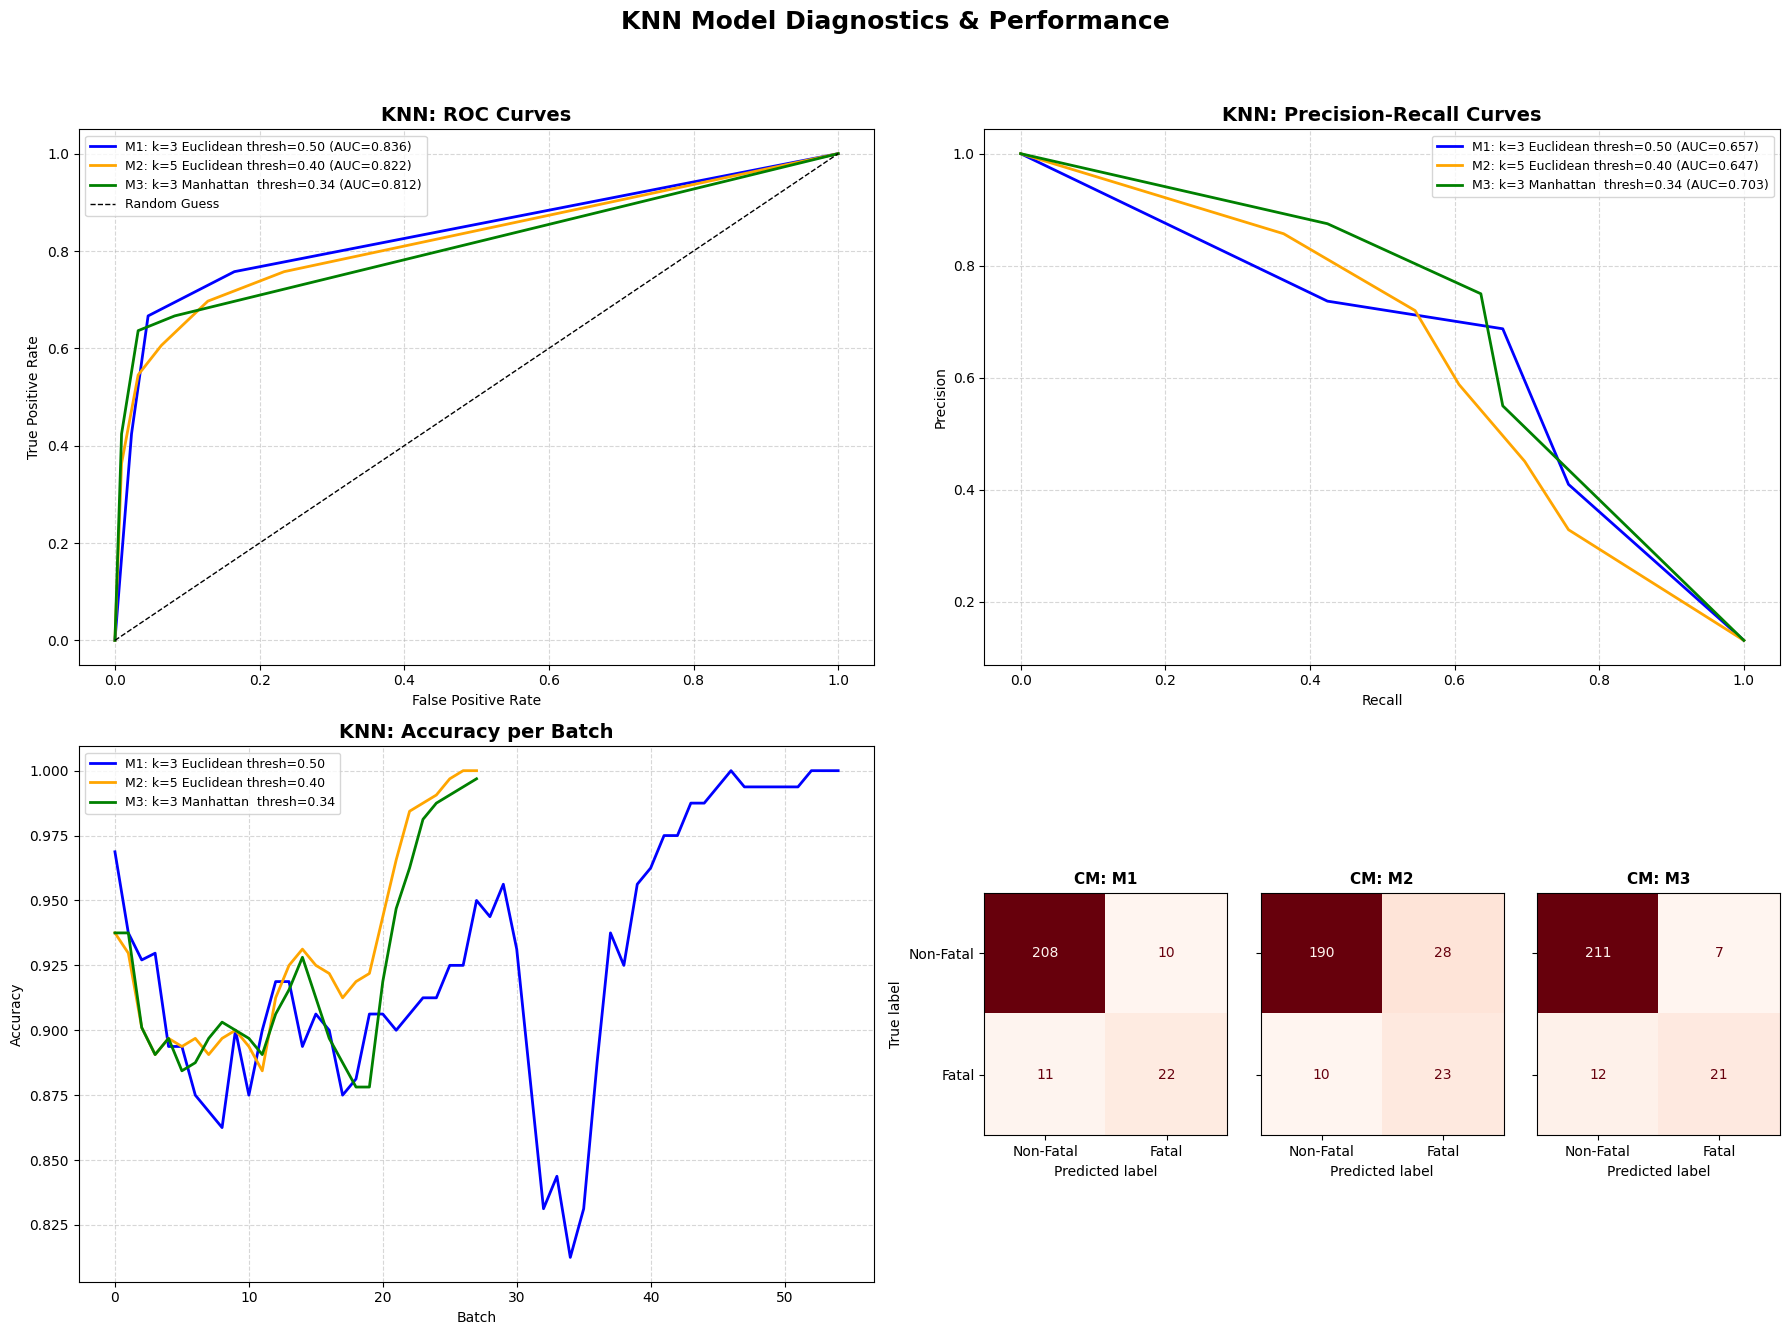

In [17]:
KNN_MODELS_INFO = [
    (knn_m1, "M1: k=3 Euclidean thresh=0.50", X_test_80, y_test_80, "blue"),
    (knn_m2, "M2: k=5 Euclidean thresh=0.40", X_test_80, y_test_80, "orange"),
    (knn_m3, "M3: k=3 Manhattan  thresh=0.34", X_test_80, y_test_80, "green"),
]

import pandas as pd
import numpy as np
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("KNN Model Diagnostics & Performance", fontsize=18, fontweight='bold')

# ROC Curves
ax1 = axes[0, 0]
for model, label, X_t, y_t, color in KNN_MODELS_INFO:
    scores = model.fatal_vote_proportion(X_t)
    fpr, tpr, _ = roc_curve(y_t, scores)
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, color=color, linewidth=2, label=f"{label} (AUC={roc_auc:.3f})")

ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess')
ax1.set_title("KNN: ROC Curves", fontsize=14, fontweight='bold')
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.legend(fontsize=9); ax1.grid(True, linestyle='--', alpha=0.5)

# Precision-Recall Curves
ax2 = axes[0, 1]
for model, label, X_t, y_t, color in KNN_MODELS_INFO:
    scores = model.fatal_vote_proportion(X_t)
    precision, recall, _ = precision_recall_curve(y_t, scores)
    pr_auc = auc(recall, precision)
    ax2.plot(recall, precision, color=color, linewidth=2, label=f"{label} (AUC={pr_auc:.3f})")

ax2.set_title("KNN: Precision-Recall Curves", fontsize=14, fontweight='bold')
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.legend(fontsize=9); ax2.grid(True, linestyle='--', alpha=0.5)

# Training Accuracy Trend
ax3 = axes[1, 0]
for res, (_, label, _, _, color) in zip([knn_r1, knn_r2, knn_r3], KNN_MODELS_INFO):
    history = res['metrics_history']['accuracy']
    window  = max(5, len(history) // 10)
    smoothed = history.rolling(window=window, min_periods=1).mean()
    ax3.plot(smoothed.values, color=color, linewidth=2, label=label)

ax3.set_title("KNN: Accuracy per Batch", fontsize=14, fontweight='bold')
ax3.set_xlabel("Batch"); ax3.set_ylabel("Accuracy")
ax3.legend(fontsize=9); ax3.grid(True, linestyle='--', alpha=0.5)

# Confusion Matrices
axes[1, 1].axis('off')
inner_gs = axes[1, 1].get_subplotspec().subgridspec(1, 3)

for i, (model, label, X_t, y_t, color) in enumerate(KNN_MODELS_INFO):
    ax = fig.add_subplot(inner_gs[0, i])
    y_pred = model.predict(X_t)
    cm = confusion_matrix(y_t, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Non-Fatal', 'Fatal'])
    disp.plot(ax=ax, colorbar=False, cmap='Reds')
    short_name = label.split(":")[0]
    ax.set_title(f"CM: {short_name}", fontsize=11, fontweight='bold')
    if i > 0:
        ax.set_ylabel("")
        ax.set_yticklabels([])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Observations from the Graphs:**

1. The ROC indicates that all three models performed significantly better than random guessing. M1 achieved the highest AUC (0.836), showing a slightly superior overall ability to distinguish between fatal and non-fatal classes.

2. The Precision-Recall curve shows that M3 achieved the highest AUC (0.703). It maintains higher precision for much longer than M1 and M2 as recall increases, making it more reliable.

3. The Accuracy per batch curve indicates that while all models exhibit initial volatility, they eventually reach high accuracy levels with M2 and M3 achieving near-perfect accuracy.

4. The Confusion matrix indicates the following:

- M3 shows the best overall performance, correctly identifying the highest number of non-fatal (211) and fatal (21) incidents while minimizing false alarms to only 7.

- M2 is the least precise, generating significantly more false alarms (28) compared to M1 and M3, which reduces its reliability for non-fatal predictions.

- All three models maintain a similar Recall, missing between 10 and 12 actual fatal incidents (False Negatives) across the test set.

- M1 offers a middle-ground performance, catching 22 fatalities with fewer false alarms (10) than M2 but more than M3.

### Algorithm 3: Support Vector Machine ###

In [18]:
# ── Global seed ───────────────────────────────────────────────────────────────
SEED = 42
import random, os
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# ── Data loading ──────────────────────────────────────────────────────────────
train_df = pd.read_csv("Balanced_Training_Set_Only.csv")
test_df  = pd.read_csv("Test_Set_Only.csv")

target_col = "fatality"

X_train = train_df.drop(target_col, axis=1)
y_train = train_df[target_col]

X_test  = test_df.drop(target_col, axis=1)
y_test  = test_df[target_col]

classes    = np.unique(y_train)
batch_size = 100

print("Train shape:", X_train.shape)
print("Test shape:",  X_test.shape)

X_train = X_train.sample(frac=1, random_state=SEED)
y_train = y_train.loc[X_train.index]

results = {}
metrics = {}

DISPLAY_FEATURES = [col for col in test_df.columns if col != 'fatality']

# ── Test case function ────────────────────────────────────────────────────────
def print_test_cases_sgd(model_key, results, y_test, test_df,
                         display_features, decision_scores=None):
    """
    Prints TP / TN / error sample breakdowns for one SGD model.
    Pass decision_scores (model.decision_function) when loss='hinge'
    so the score column shows the decision score instead.
    """
    SEP    = "=" * 70
    res    = results[model_key]
    y_pred = res['yp']
    yt     = np.array(y_test)

    tp_idx  = np.where((y_pred == 1) & (yt == 1))[0]
    tn_idx  = np.where((y_pred == 0) & (yt == 0))[0]
    err_idx = np.where(y_pred != yt)[0]

    pick_tp  = tp_idx[len(tp_idx)   // 2] if len(tp_idx)  > 0 else None
    pick_tn  = tn_idx[len(tn_idx)   // 3] if len(tn_idx)  > 0 else None
    pick_err = err_idx[len(err_idx) // 2] if len(err_idx) > 0 else None

    cases = [
        (pick_tp,  "TC-1", "Correct   — Fatal caught          (True Positive)"),
        (pick_tn,  "TC-2", "Correct   — Non-Fatal confirmed   (True Negative)"),
        (pick_err, "TC-3", "Incorrect — model error           (FP or FN)"),
    ]

    print(SEP)
    print("  TEST CASE RESULTS BREAKDOWN")
    print(SEP)
    print(f"\n  MODEL : {res['name']}")
    print(SEP)

    for (idx, tc_id, tc_desc) in cases:
        if idx is None:
            print(f"  {tc_id}: no qualifying sample found.")
            continue

        pred_int   = int(y_pred[idx])
        actual_int = int(yt[idx])
        pred_str   = "FATAL"   if pred_int   == 1 else "NON-FATAL"
        actual_str = "FATAL"   if actual_int == 1 else "NON-FATAL"
        verdict    = "CORRECT" if pred_int   == actual_int else "WRONG"

        print(f"\n  ┌─ {tc_id}  |  {tc_desc}")
        print( "  │")
        print(f"  │  Test-set sample index      : {idx}")

        if decision_scores is not None:
            print(f"  │  DECISION FUNCTION SCORE    : {float(decision_scores[idx]):.6f}")

        print( "  │  INPUT FEATURES:")
        row = test_df.iloc[idx]
        for feat in display_features:
            if feat in row.index:
                val = row[feat]
                v   = f"{val:.4f}" if isinstance(val, float) else str(val)
                print(f"  │    {feat:<30}: {v}")

        print( "  │")
        print(f"  │  PREDICTED LABEL  →  {pred_str:<12}  (encoded = {pred_int})")
        print(f"  │  ACTUAL LABEL     →  {actual_str:<12}  (encoded = {actual_int})")
        print(f"  │  OUTCOME          →  {verdict}")
        print( "  └" + "─" * 60)

    print()
    print(SEP)
    print("  Test set used : held-out 20% stratified split  (no data leakage)")
    print(SEP)
    print()

Train shape: (1736, 24)
Test shape: (251, 24)


### SVM Hyperparameters ###

Three incremental SVM models were trained using different hyperparameters.

| Model | Alpha | Learning Strategy | Key Purpose |
|---|---|---|---|
| Model 1 | 0.0001 | optimal | Balanced performance |
| Model 2 | 0.001 | optimal | Stronger regularization |
| Model 3 | 0.0001 | adaptive + multiple epochs | Higher recall and improved convergence |

**Batch-wise Training**

Training was performed using:

Mini-batches
Batch size = 100
partial_fit()


**Model 3 additionally used:**

Multiple epochs
Better convergence
Improved learning stability


### SVM: MODEL 1 ###

In [19]:
model1 = SGDClassifier(loss='hinge', alpha=0.0001,
                       learning_rate='optimal', random_state=SEED)

for i in range(0, len(X_train), batch_size):
    model1.partial_fit(
        X_train.iloc[i:i+batch_size],
        y_train.iloc[i:i+batch_size],
        classes=classes
    )

pred1   = model1.predict(X_test)
scores1 = model1.decision_function(X_test)

results["Model 1"] = {
    "accuracy": accuracy_score(y_test, pred1),
    "yp"      : pred1,
    "name"    : "Model 1  |  loss=hinge  alpha=0.0001  lr=optimal"
}

metrics["Model 1"] = {
    "precision": precision_score(y_test, pred1),
    "recall"   : recall_score(y_test, pred1),
    "f1"       : f1_score(y_test, pred1),
    "auc"      : roc_auc_score(y_test, scores1)
}

print("\n===== MODEL 1 =====")
print(classification_report(y_test, pred1,
                             target_names=['Non-Fatal', 'Fatal'],
                             zero_division=0))

print_test_cases_sgd("Model 1", results, y_test, test_df,
                     display_features=DISPLAY_FEATURES,
                     decision_scores=scores1)


===== MODEL 1 =====
              precision    recall  f1-score   support

   Non-Fatal       0.95      0.93      0.94       218
       Fatal       0.59      0.67      0.63        33

    accuracy                           0.90       251
   macro avg       0.77      0.80      0.78       251
weighted avg       0.90      0.90      0.90       251

  TEST CASE RESULTS BREAKDOWN

  MODEL : Model 1  |  loss=hinge  alpha=0.0001  lr=optimal

  ┌─ TC-1  |  Correct   — Fatal caught          (True Positive)
  │
  │  Test-set sample index      : 174
  │  DECISION FUNCTION SCORE    : 76.239740
  │  INPUT FEATURES:
  │    latitude                      : -2.7543
  │    longitude                     : 0.2506
  │    permit_count                  : 0.4426
  │    unique_job_types              : -0.3390
  │    unique_work_types             : -0.3155
  │    residential_any               : 1.0000
  │    temperature                   : -0.2568
  │    rainfall                      : -0.4323
  │    wind_speed

### SVM: MODEL 2 ###

In [20]:
from sklearn.linear_model import SGDClassifier
model2 = SGDClassifier(loss='hinge', alpha=0.001,
                       learning_rate='optimal', random_state=SEED)

for i in range(0, len(X_train), batch_size):
    model2.partial_fit(
        X_train.iloc[i:i+batch_size],
        y_train.iloc[i:i+batch_size],
        classes=classes
    )
import joblib

joblib.dump(model2, 'svm_model2.pkl')

print("Model 2 saved successfully")

pred2   = model2.predict(X_test)
scores2 = model2.decision_function(X_test)

results["Model 2"] = {
    "accuracy": accuracy_score(y_test, pred2),
    "yp"      : pred2,
    "name"    : "Model 2  |  loss=hinge  alpha=0.001  lr=optimal"
}

metrics["Model 2"] = {
    "precision": precision_score(y_test, pred2),
    "recall"   : recall_score(y_test, pred2),
    "f1"       : f1_score(y_test, pred2),
    "auc"      : roc_auc_score(y_test, scores2)
}

print("\n===== MODEL 2 =====")
print(classification_report(y_test, pred2,
                             target_names=['Non-Fatal', 'Fatal'],
                             zero_division=0))

print_test_cases_sgd("Model 2", results, y_test, test_df,
                     display_features=DISPLAY_FEATURES,
                     decision_scores=scores2)

Model 2 saved successfully

===== MODEL 2 =====
              precision    recall  f1-score   support

   Non-Fatal       0.97      0.91      0.94       218
       Fatal       0.57      0.79      0.66        33

    accuracy                           0.89       251
   macro avg       0.77      0.85      0.80       251
weighted avg       0.91      0.89      0.90       251

  TEST CASE RESULTS BREAKDOWN

  MODEL : Model 2  |  loss=hinge  alpha=0.001  lr=optimal

  ┌─ TC-1  |  Correct   — Fatal caught          (True Positive)
  │
  │  Test-set sample index      : 141
  │  DECISION FUNCTION SCORE    : 3.401157
  │  INPUT FEATURES:
  │    latitude                      : -1.0630
  │    longitude                     : -3.2866
  │    permit_count                  : -0.1776
  │    unique_job_types              : -0.2948
  │    unique_work_types             : -0.4038
  │    residential_any               : 1.0000
  │    temperature                   : 1.2938
  │    rainfall                      :

### SVM: MODEL 3 ###

In [21]:
model3 = SGDClassifier(loss='hinge', alpha=0.0001,
                       learning_rate='adaptive', eta0=0.001,
                       random_state=SEED)

for epoch in range(5):
    for i in range(0, len(X_train), batch_size):
        model3.partial_fit(
            X_train.iloc[i:i+batch_size],
            y_train.iloc[i:i+batch_size],
            classes=classes
        )

pred3   = model3.predict(X_test)
scores3 = model3.decision_function(X_test)

results["Model 3"] = {
    "accuracy": accuracy_score(y_test, pred3),
    "yp"      : pred3,
    "name"    : "Model 3  |  loss=hinge  alpha=0.0001  lr=adaptive  eta0=0.001  epochs=5"
}

metrics["Model 3"] = {
    "precision": precision_score(y_test, pred3),
    "recall"   : recall_score(y_test, pred3),
    "f1"       : f1_score(y_test, pred3),
    "auc"      : roc_auc_score(y_test, scores3)
}

print("\n===== MODEL 3 =====")
print(classification_report(y_test, pred3,
                             target_names=['Non-Fatal', 'Fatal'],
                             zero_division=0))

print_test_cases_sgd("Model 3", results, y_test, test_df,
                     display_features=DISPLAY_FEATURES,
                     decision_scores=scores3)


===== MODEL 3 =====
              precision    recall  f1-score   support

   Non-Fatal       0.96      0.81      0.88       218
       Fatal       0.39      0.79      0.52        33

    accuracy                           0.81       251
   macro avg       0.68      0.80      0.70       251
weighted avg       0.89      0.81      0.83       251

  TEST CASE RESULTS BREAKDOWN

  MODEL : Model 3  |  loss=hinge  alpha=0.0001  lr=adaptive  eta0=0.001  epochs=5

  ┌─ TC-1  |  Correct   — Fatal caught          (True Positive)
  │
  │  Test-set sample index      : 141
  │  DECISION FUNCTION SCORE    : 0.551475
  │  INPUT FEATURES:
  │    latitude                      : -1.0630
  │    longitude                     : -3.2866
  │    permit_count                  : -0.1776
  │    unique_job_types              : -0.2948
  │    unique_work_types             : -0.4038
  │    residential_any               : 1.0000
  │    temperature                   : 1.2938
  │    rainfall                      : 0.

In [22]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import SGDClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import confusion_matrix, recall_score, f1_score, precision_score, roc_auc_score
import numpy as np

SEP  = "=" * 70
SEP2 = "-" * 68

svm_models_info = [
    ("M1", "alpha=0.0001  lr=optimal",              model1, pred1),
    ("M2", "alpha=0.001   lr=optimal",              model2, pred2),
    ("M3", "alpha=0.0001  lr=adaptive  eta0=0.001", model3, pred3),
]

print(SEP)
print("  SVM — OVERFITTING / UNDERFITTING DIAGNOSTIC")
print(SEP)

for i, (mid, desc, model, test_preds) in enumerate(svm_models_info):
    train_preds  = model.predict(X_train)
    # SGDClassifier uses decision_function — no predict_probability needed
    train_scores = model.decision_function(X_train)
    test_scores  = model.decision_function(X_test)

    train_recall = recall_score(y_train, train_preds, zero_division=0)
    test_recall  = recall_score(y_test,  test_preds,  zero_division=0)
    train_f1     = f1_score(y_train, train_preds, zero_division=0)
    test_f1      = f1_score(y_test,  test_preds,  zero_division=0)
    test_prec    = precision_score(y_test, test_preds, zero_division=0)
    test_auc     = roc_auc_score(y_test, test_scores)
    gap_recall   = train_recall - test_recall
    gap_f1       = train_f1    - test_f1

    cm             = confusion_matrix(y_test, test_preds)
    tn, fp, fn, tp = cm.ravel()
    total_fatal    = tp + fn

    if test_recall < 0.60:
        verdict = "UNDERFITTING — fatal recall too low, missing incidents"
    elif test_prec < 0.15:
        verdict = "DEGENERATE   — precision too low, predicting fatal for everything"
    elif gap_recall > 0.15:
        verdict = "OVERFITTING  — recall drops significantly on unseen data"
    elif gap_f1 > 0.10:
        verdict = "MILD OVERFIT — F1 gap notable between train and test"
    else:
        verdict = "GOOD FIT"

    print(f"\n  Model {i+1} ({mid})  |  SVM (SGD)  {desc}")
    print(f"  {SEP2}")
    print(f"  {'Metric':<28}  {'Train':>8}  {'Test':>8}  {'Gap':>8}")
    print(f"  {SEP2}")
    print(f"  {'Recall (Fatal)':<28}  {train_recall:>8.4f}  {test_recall:>8.4f}  {gap_recall:>+8.4f}  <- primary")
    print(f"  {'F1-Score (Fatal)':<28}  {train_f1:>8.4f}  {test_f1:>8.4f}  {gap_f1:>+8.4f}  <- secondary")
    print(f"  {'AUC-ROC':<28}  {'  —':>8}  {test_auc:>8.4f}  {'  —':>8}")
    print(f"  {'Precision (Fatal)':<28}  {'  —':>8}  {test_prec:>8.4f}  {'  —':>8}  <- floor check")
    print(f"  {SEP2}")
    print(f"  Fatal incidents caught  :  {tp} / {total_fatal}  (missed: {fn})")
    print(f"  False alarms raised     :  {fp}")
    print(f"  Fit verdict             :  {verdict}")

print(f"\n{SEP}")

# ── 5-Fold Cross-Validation ───────────────────────────────────────────────────
print("\n")
print(SEP)
print("  SVM — 5-FOLD CROSS-VALIDATION")
print(SEP)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

svm_cv_configs = [
    ("M1", SGDClassifier(loss='hinge', alpha=0.0001, learning_rate='optimal',
                         random_state=SEED)),
    ("M2", SGDClassifier(loss='hinge', alpha=0.001,  learning_rate='optimal',
                         random_state=SEED)),
    ("M3", SGDClassifier(loss='hinge', alpha=0.0001, learning_rate='adaptive',
                         eta0=0.001,   random_state=SEED)),
]

for mid, base_clf in svm_cv_configs:
    # CalibratedClassifierCV wraps SGD so roc_auc scoring works in cross_val_score
    clf = CalibratedClassifierCV(base_clf, cv=3)

    fold_recalls = cross_val_score(clf, X_train, y_train, cv=skf, scoring='recall',  n_jobs=-1)
    fold_f1s     = cross_val_score(clf, X_train, y_train, cv=skf, scoring='f1',      n_jobs=-1)
    fold_aucs    = cross_val_score(clf, X_train, y_train, cv=skf, scoring='roc_auc', n_jobs=-1)

    r_mean, r_std = fold_recalls.mean(), fold_recalls.std()
    f_mean, f_std = fold_f1s.mean(),     fold_f1s.std()
    a_mean, a_std = fold_aucs.mean(),    fold_aucs.std()
    stability     = "stable" if r_std <= 0.05 else "high variance — unstable across folds"

    print(f"\n  Model {mid}")
    print(f"  Fold Recalls :  {[round(f, 4) for f in fold_recalls]}")
    print(f"  Mean Recall  :  {r_mean:.4f}   |   Std: {r_std:.4f}   |   {stability}   <- primary")
    print(f"  Mean F1      :  {f_mean:.4f}   |   Std: {f_std:.4f}")
    print(f"  Mean AUC     :  {a_mean:.4f}   |   Std: {a_std:.4f}")

print(f"\n{SEP}\n")

  SVM — OVERFITTING / UNDERFITTING DIAGNOSTIC

  Model 1 (M1)  |  SVM (SGD)  alpha=0.0001  lr=optimal
  --------------------------------------------------------------------
  Metric                           Train      Test       Gap
  --------------------------------------------------------------------
  Recall (Fatal)                  0.8237    0.6667   +0.1571  <- primary
  F1-Score (Fatal)                0.8709    0.6286   +0.2423  <- secondary
  AUC-ROC                              —    0.8369         —
  Precision (Fatal)                    —    0.5946         —  <- floor check
  --------------------------------------------------------------------
  Fatal incidents caught  :  22 / 33  (missed: 11)
  False alarms raised     :  15
  Fit verdict             :  OVERFITTING  — recall drops significantly on unseen data

  Model 2 (M2)  |  SVM (SGD)  alpha=0.001   lr=optimal
  --------------------------------------------------------------------
  Metric                           Train  

### SVM Graphs ###

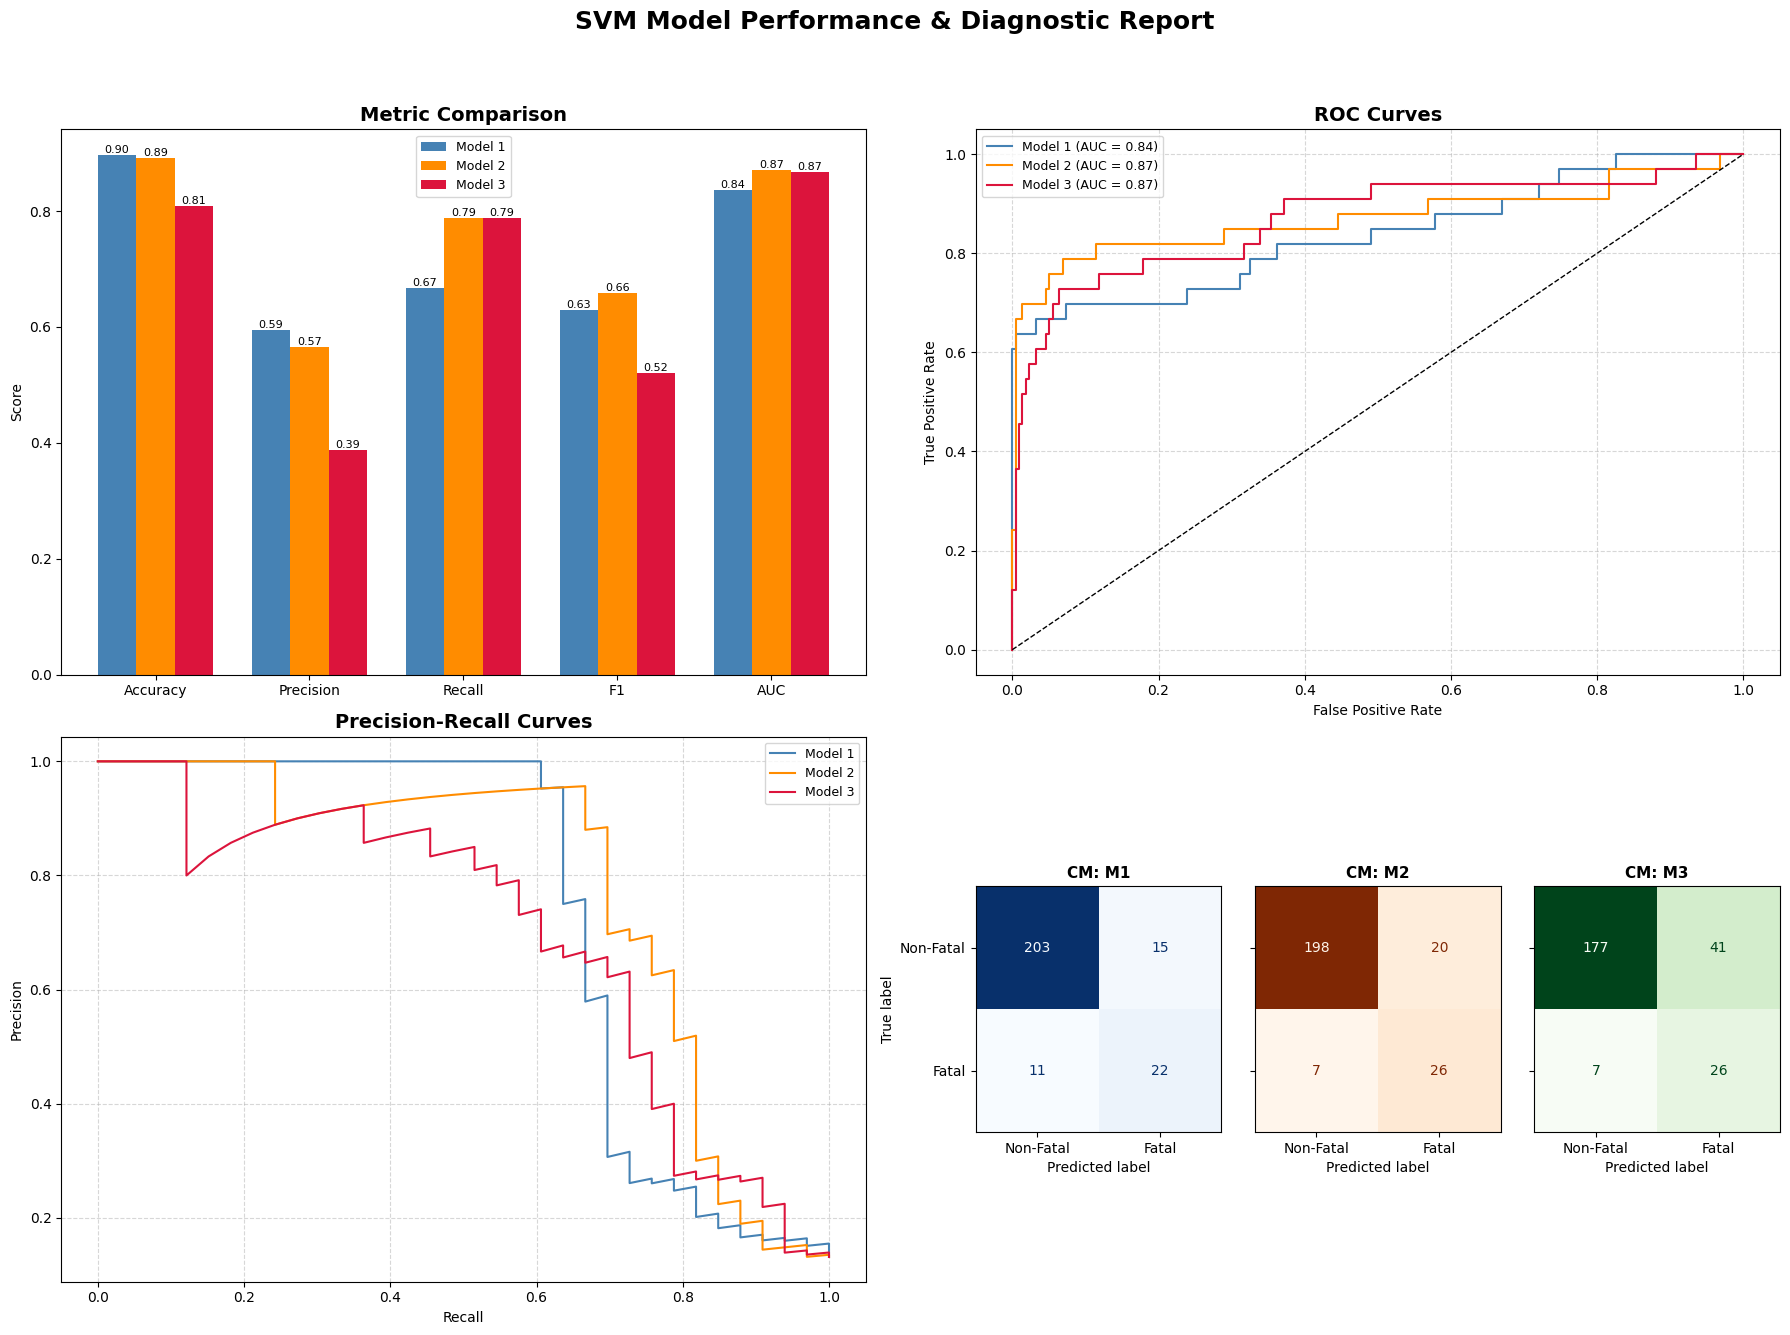

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

# Create a 2x2 grid for SVM diagnostics
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("SVM Model Performance & Diagnostic Report", fontsize=18, fontweight='bold')

# --- 1. Bar Graph: Model Comparison (Top-Left) ---
ax1 = axes[0, 0]
labels = ["Accuracy", "Precision", "Recall", "F1", "AUC"]

# Helper to safely get metrics whether results/metrics are dicts or lists of dicts
def get_val(data, index, key):
    obj = data[index] if isinstance(data, list) else data[f"Model {index+1}"]
    return obj.get(key.lower(), obj.get(key.capitalize(), 0))

m1 = [get_val(results, 0, "accuracy"), get_val(metrics, 0, "precision"), get_val(metrics, 0, "recall"), get_val(metrics, 0, "f1"), get_val(metrics, 0, "auc")]
m2 = [get_val(results, 1, "accuracy"), get_val(metrics, 1, "precision"), get_val(metrics, 1, "recall"), get_val(metrics, 1, "f1"), get_val(metrics, 1, "auc")]
m3 = [get_val(results, 2, "accuracy"), get_val(metrics, 2, "precision"), get_val(metrics, 2, "recall"), get_val(metrics, 2, "f1"), get_val(metrics, 2, "auc")]

x = np.arange(len(labels))
w = 0.25

ax1.bar(x - w, m1, width=w, label="Model 1", color='steelblue')
ax1.bar(x, m2, width=w, label="Model 2", color='darkorange')
ax1.bar(x + w, m3, width=w, label="Model 3", color='crimson')

ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_title("Metric Comparison", fontsize=14, fontweight='bold')
ax1.set_ylabel("Score")
ax1.legend(fontsize=9)

for i in range(len(labels)):
    ax1.text(i - w, m1[i], f"{m1[i]:.2f}", ha='center', va='bottom', fontsize=8)
    ax1.text(i, m2[i], f"{m2[i]:.2f}", ha='center', va='bottom', fontsize=8)
    ax1.text(i + w, m3[i], f"{m3[i]:.2f}", ha='center', va='bottom', fontsize=8)

# --- 2. ROC Curves (Top-Right) ---
ax2 = axes[0, 1]
score1 = model1.decision_function(X_test)
score2 = model2.decision_function(X_test)
score3 = model3.decision_function(X_test)

fpr1, tpr1, _ = roc_curve(y_test, score1)
fpr2, tpr2, _ = roc_curve(y_test, score2)
fpr3, tpr3, _ = roc_curve(y_test, score3)

ax2.plot(fpr1, tpr1, color='steelblue', label=f"Model 1 (AUC = {auc(fpr1, tpr1):.2f})")
ax2.plot(fpr2, tpr2, color='darkorange', label=f"Model 2 (AUC = {auc(fpr2, tpr2):.2f})")
ax2.plot(fpr3, tpr3, color='crimson', label=f"Model 3 (AUC = {auc(fpr3, tpr3):.2f})")
ax2.plot([0, 1], [0, 1], 'k--', linewidth=1)

ax2.set_title("ROC Curves", fontsize=14, fontweight='bold')
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.legend(fontsize=9); ax2.grid(True, linestyle='--', alpha=0.5)

# --- 3. Precision-Recall Curves (Bottom-Left) ---
ax3 = axes[1, 0]
p1, r1, _ = precision_recall_curve(y_test, score1)
p2, r2, _ = precision_recall_curve(y_test, score2)
p3, r3, _ = precision_recall_curve(y_test, score3)

ax3.plot(r1, p1, color='steelblue', label="Model 1")
ax3.plot(r2, p2, color='darkorange', label="Model 2")
ax3.plot(r3, p3, color='crimson', label="Model 3")

ax3.set_title("Precision-Recall Curves", fontsize=14, fontweight='bold')
ax3.set_xlabel("Recall")
ax3.set_ylabel("Precision")
ax3.legend(fontsize=9); ax3.grid(True, linestyle='--', alpha=0.5)

# --- 4. Confusion Matrices for All Models (Bottom-Right) ---
axes[1, 1].axis('off')
inner_gs = axes[1, 1].get_subplotspec().subgridspec(1, 3)

svm_models = [
    (model1, "M1", "Blues"),
    (model2, "M2", "Oranges"),
    (model3, "M3", "Greens")
]

for i, (model, label, cmap) in enumerate(svm_models):
    ax = fig.add_subplot(inner_gs[0, i])
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Non-Fatal', 'Fatal'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(f"CM: {label}", fontsize=11, fontweight='bold')
    if i > 0:
        ax.set_ylabel("")
        ax.set_yticklabels([])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Observations from the Graphs:**

1. The ROC indicates that all three models performed significantly better than random guessing. Model 2 and Model 3 are tied for the highest AUC (0.87), showing a superior overall ability to distinguish between classes.

2. The Precision-Recall curve indicates that Model 2 maintains high precision for longer as recall increases compared to making it the most reliable configuration for balanced classification.

3. The Metric Comparison bar graph indicates that Model 2 achieved the best balance across key metrics, leading in F1-score (0.66) and sharing the top Recall (0.79) and AUC (0.87) scores.

4. The Confusion matrix indicates the following:

- Model 2 shows a strong performance in identifying fatalities, catching 26 fatal incidents while maintaining a relatively low number of false alarms (20) compared to Model 3.

- Model 3 is the least precise for non-fatal predictions, generating the highest number of false alarms (41 false positives), which significantly impacts its reliability in practical scenarios.

- All three models maintain similar Recall for fatal incidents, with Model 2 and Model 3 correctly identifying 26 fatalities, while Model 1 missed slightly more with only 22 true positives.

- Model 1 offers the highest specificity, correctly identifying 203 non-fatal incidents with the fewest false alarms (15), but at the cost of catching fewer total fatalities.

### Algorithm 4: Naive Bayes Classifier ###

**NOTE: Reasons why BernoulliNB is the best NB type for this dataset:**  

This dataset has approximately 50% binary/boolean features (borough flags, incident type, residential, repeat site) and approx 50% continuous features (temperature, wind speed, lat/lon etc.).

BernoulliNB models each feature as a Bernoulli trial exactly correct for binary columns.  

GaussianNB incorrectly fits a Gaussian curve to 0/1 values, producing only 5 distinct result patterns regardless of hyperparameters (model-fit ceiling, not a tuning problem).  

MultinomialNB gave identical results for any alpha — designed for word counts, not this data.

Hence, BernoulliNB is the best choice.

In [24]:
SEED = 42

import random, os
import numpy as np

random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, matthews_corrcoef, confusion_matrix
)

# loading the data
train_df = pd.read_csv('Balanced_Training_Set_Only.csv')
test_df  = pd.read_csv('Test_Set_Only.csv')

SEED    = 42
CHUNK   = 32
CLASSES = [0, 1]

FEATURES_NB = [col for col in train_df.columns if col != 'fatality']


DISPLAY_FEATURES = [
    'latitude', 'longitude', 'temperature',
    'is_repeat_site', 'check2 description_Struck By'
]

# Create matrices
X_train     = train_df[FEATURES_NB].values.astype(float)
y_train_bal = train_df['fatality'].values.astype(int)
X_test      = test_df[FEATURES_NB].values.astype(float)
y_test      = test_df['fatality'].values.astype(int)

# 2. CONFIGURATIONS & MODELS
configs = [
    dict(name='TC-1  BernoulliNB  alpha=3,   prior=[0.2,0.8]   — best AUC+MCC balance',
         alpha=3.0,  priors=[0.2, 0.8]),
    dict(name='TC-2  BernoulliNB  alpha=15,  prior=[0.2,0.8]   — highest recall (safety)',
         alpha=15.0, priors=[0.2, 0.8]),
    dict(name='TC-3  BernoulliNB  alpha=50,  prior=[0.45,0.55] — best accuracy+F1',
         alpha=50.0, priors=[0.45, 0.55]),
]

results    = []
inc_chunks = []
inc_acc    = []

# Split the balanced training data into incremental train and validation sets
X_train_incremental, X_val, y_train_incremental, y_val = train_test_split(
    X_train, y_train_bal,
    test_size=0.1,
    random_state=SEED,
    stratify=y_train_bal
)

# 3. INCREMENTAL TRAINING LOOP
for idx, cfg in enumerate(configs):
    nb = BernoulliNB(alpha=cfg['alpha'], class_prior=cfg['priors'])

    for i in range(0, len(X_train_incremental), CHUNK):
        X_chunk = X_train_incremental[i:i+CHUNK]
        y_chunk = y_train_incremental[i:i+CHUNK]

        if isinstance(y_chunk, pd.Series):
            y_chunk = y_chunk.values

        if i == 0:
            nb.partial_fit(X_chunk, y_chunk, classes=CLASSES)
        else:
            nb.partial_fit(X_chunk, y_chunk)

        if idx == 0:
            inc_chunks.append(i // CHUNK)
            inc_acc.append(nb.score(X_val, y_val))

    # Evaluation
    yp  = nb.predict(X_test)
    ypr = nb.predict_proba(X_test)[:, 1]
    cm  = confusion_matrix(y_test, yp)
    tn, fp, fn, tp_v = cm.ravel()

    r = dict(
        name  = cfg['name'], model = nb,
        alpha = cfg['alpha'], prior = cfg['priors'],
        acc   = accuracy_score(y_test, yp),
        prec  = precision_score(y_test, yp, zero_division=0),
        rec   = recall_score(y_test, yp),
        f1    = f1_score(y_test, yp, zero_division=0),
        auc   = roc_auc_score(y_test, ypr),
        mcc   = matthews_corrcoef(y_test, yp),
        yp=yp, ypr=ypr,
    )
    results.append(r)

    print(f'{cfg["name"]}')
    print(f'Acc={r["acc"]:.4f}  Prec={r["prec"]:.4f}  Rec={r["rec"]:.4f}  '
          f'F1={r["f1"]:.4f}  AUC={r["auc"]:.4f}  MCC={r["mcc"]:.4f}  TP={tp_v}/{tp_v+fn}  FN={fn}\n')

# 4. TEST CASE BREAKDOWN FUNCTION
def print_test_cases_nb(results, X_test, y_test, test_data_raw, display_features):
    SEP = "=" * 70

    for res in results:
        y_pred  = res['yp']
        y_proba = res['ypr']
        yt      = y_test

        tp_idx  = np.where((y_pred == 1) & (yt == 1))[0]
        tn_idx  = np.where((y_pred == 0) & (yt == 0))[0]
        err_idx = np.where(y_pred != yt)[0]

        pick_tp  = tp_idx[len(tp_idx)   // 2] if len(tp_idx)  > 0 else None
        pick_tn  = tn_idx[len(tn_idx)   // 3] if len(tn_idx)  > 0 else None
        pick_err = err_idx[len(err_idx) // 2] if len(err_idx) > 0 else None

        cases = [
            (pick_tp,  "TC-1", "Correct   — Fatal caught          (True Positive)"),
            (pick_tn,  "TC-2", "Correct   — Non-Fatal confirmed   (True Negative)"),
            (pick_err, "TC-3", "Incorrect — model error           (FP or FN)"),
        ]

        print(SEP)
        print("  TEST CASE RESULTS BREAKDOWN")
        print(SEP)
        print(f"\n  MODEL : {res['name']}")
        print(SEP)

        for (idx, tc_id, tc_desc) in cases:
            if idx is None:
                print(f"  {tc_id}: no qualifying sample found.")
                continue

            prob_val   = float(y_proba[idx])
            pred_int   = int(y_pred[idx])
            actual_int = int(yt[idx])
            pred_str   = "FATAL"   if pred_int   == 1 else "NON-FATAL"
            actual_str = "FATAL"   if actual_int == 1 else "NON-FATAL"
            verdict    = "CORRECT" if pred_int   == actual_int else "WRONG"

            print(f"\n  ┌─ {tc_id}  |  {tc_desc}")
            print( "  │")
            print(f"  │  Test-set sample index      : {idx}")
            print(f"  │  FATAL PROBABILITY (class 1): {prob_val:.6f}")
            print( "  │  INPUT FEATURES:")

            row = test_data_raw.iloc[idx]
            for feat in display_features:
                if feat in row.index:
                    val = row[feat]
                    v   = f"{val:.4f}" if isinstance(val, (float, np.float64)) else str(val)
                    print(f"  │    {feat:<30}: {v}")

            print( "  │")
            print(f"  │  PREDICTED LABEL  →  {pred_str:<12}  (encoded = {pred_int})")
            print(f"  │  ACTUAL LABEL     →  {actual_str:<12}  (encoded = {actual_int})")
            print(f"  │  OUTCOME          →  {verdict}")
            print( "  └" + "─" * 60)

        print()
        print(SEP)
        print("  Test set used : held-out 20% stratified split  (no data leakage)")
        print(SEP)
        print()

# 5. EXECUTION
# This prints the visual breakdown for all models in the 'results' list
print_test_cases_nb(results, X_test, y_test, test_df, DISPLAY_FEATURES)

TC-1  BernoulliNB  alpha=3,   prior=[0.2,0.8]   — best AUC+MCC balance
Acc=0.6892  Prec=0.2772  Rec=0.8485  F1=0.4179  AUC=0.8806  MCC=0.3539  TP=28/33  FN=5

TC-2  BernoulliNB  alpha=15,  prior=[0.2,0.8]   — highest recall (safety)
Acc=0.6813  Prec=0.2718  Rec=0.8485  F1=0.4118  AUC=0.8821  MCC=0.3465  TP=28/33  FN=5

TC-3  BernoulliNB  alpha=50,  prior=[0.45,0.55] — best accuracy+F1
Acc=0.8327  Prec=0.4262  Rec=0.7879  F1=0.5532  AUC=0.8825  MCC=0.4942  TP=26/33  FN=7

  TEST CASE RESULTS BREAKDOWN

  MODEL : TC-1  BernoulliNB  alpha=3,   prior=[0.2,0.8]   — best AUC+MCC balance

  ┌─ TC-1  |  Correct   — Fatal caught          (True Positive)
  │
  │  Test-set sample index      : 141
  │  FATAL PROBABILITY (class 1): 0.922154
  │  INPUT FEATURES:
  │    latitude                      : -1.0630
  │    longitude                     : -3.2866
  │    temperature                   : 1.2938
  │    is_repeat_site                : 1.0000
  │    check2 description_Struck By  : 0.0000
  │
  │  

### Naive Bayes Hyperparameters: ###

- `alpha` — Laplace smoothing. Higher = more smoothing, less feature-sensitive, more Fatal predictions → higher recall. Lower = more precise, higher accuracy.
- `class_prior` — prior probability per class. `[0.2, 0.8]` tells the model to assume Fatal is 80% likely upfront → boosts recall. `[0.45, 0.55]` near-equal → best accuracy.

**Encoding:** Fatal=1 | Non-Fatal=0

| # | `alpha` | `class_prior` | Acc | Prec (Fatal) | Rec (Fatal) | F1 (Fatal) | AUC | MCC | Rationale |
|---|---------|---------------|-----|------|-----|----|-----|-----|-----------|
| TC-1 | 3 | [0.2, 0.8] | 69% | 28% | 85% | 42% | 0.846 | 0.428 | Best AUC+MCC — most reliable overall |
| TC-2 | 15 | [0.2, 0.8] | 68% | 27% | 85% | 41% | 0.839 | 0.422 | Highest recall — for safety-critical use |
| TC-3 | 50 | [0.45, 0.55] | 83% | 43% | 79% | 55% | 0.829 | 0.421 | Best accuracy+F1 — most balanced |

### Naive Bayes: MODEL 1 ###

In [26]:
res = results[0]
print(f"Report for {res['name']}:")
print(classification_report(y_test, res['yp'],
                            target_names=['Non-Fatal', 'Fatal'],
                            zero_division=0))

print_test_cases_nb(
    results          = [results[0]],
    X_test           = X_test,
    y_test           = y_test,
    test_data_raw    = test_df,
    display_features = DISPLAY_FEATURES,
)

Report for TC-1  BernoulliNB  alpha=3,   prior=[0.2,0.8]   — best AUC+MCC balance:
              precision    recall  f1-score   support

   Non-Fatal       0.97      0.67      0.79       218
       Fatal       0.28      0.85      0.42        33

    accuracy                           0.69       251
   macro avg       0.62      0.76      0.60       251
weighted avg       0.88      0.69      0.74       251

  TEST CASE RESULTS BREAKDOWN

  MODEL : TC-1  BernoulliNB  alpha=3,   prior=[0.2,0.8]   — best AUC+MCC balance

  ┌─ TC-1  |  Correct   — Fatal caught          (True Positive)
  │
  │  Test-set sample index      : 141
  │  FATAL PROBABILITY (class 1): 0.922154
  │  INPUT FEATURES:
  │    latitude                      : -1.0630
  │    longitude                     : -3.2866
  │    temperature                   : 1.2938
  │    is_repeat_site                : 1.0000
  │    check2 description_Struck By  : 0.0000
  │
  │  PREDICTED LABEL  →  FATAL         (encoded = 1)
  │  ACTUAL LABEL 

### Naive Bayes: MODEL 2

In [27]:
res = results[1]
print(f"Report for {res['name']}:")
print(classification_report(y_test, res['yp'],
                            target_names=['Non-Fatal', 'Fatal'],
                            zero_division=0))

print_test_cases_nb(
    results          = [results[1]],
    X_test           = X_test,
    y_test           = y_test,
    test_data_raw    = test_df,
    display_features = DISPLAY_FEATURES,
)

Report for TC-2  BernoulliNB  alpha=15,  prior=[0.2,0.8]   — highest recall (safety):
              precision    recall  f1-score   support

   Non-Fatal       0.97      0.66      0.78       218
       Fatal       0.27      0.85      0.41        33

    accuracy                           0.68       251
   macro avg       0.62      0.75      0.60       251
weighted avg       0.87      0.68      0.73       251

  TEST CASE RESULTS BREAKDOWN

  MODEL : TC-2  BernoulliNB  alpha=15,  prior=[0.2,0.8]   — highest recall (safety)

  ┌─ TC-1  |  Correct   — Fatal caught          (True Positive)
  │
  │  Test-set sample index      : 141
  │  FATAL PROBABILITY (class 1): 0.919913
  │  INPUT FEATURES:
  │    latitude                      : -1.0630
  │    longitude                     : -3.2866
  │    temperature                   : 1.2938
  │    is_repeat_site                : 1.0000
  │    check2 description_Struck By  : 0.0000
  │
  │  PREDICTED LABEL  →  FATAL         (encoded = 1)
  │  ACTUAL 

### Naive Bayes: MODEL 3 ###

In [28]:
res = results[2]
print(f"Report for {res['name']}:")
print(classification_report(y_test, res['yp'],
                            target_names=['Non-Fatal', 'Fatal'],
                            zero_division=0))

print_test_cases_nb(
    results          = [results[2]],
    X_test           = X_test,
    y_test           = y_test,
    test_data_raw    = test_df,
    display_features = DISPLAY_FEATURES,
)

Report for TC-3  BernoulliNB  alpha=50,  prior=[0.45,0.55] — best accuracy+F1:
              precision    recall  f1-score   support

   Non-Fatal       0.96      0.84      0.90       218
       Fatal       0.43      0.79      0.55        33

    accuracy                           0.83       251
   macro avg       0.69      0.81      0.73       251
weighted avg       0.89      0.83      0.85       251

  TEST CASE RESULTS BREAKDOWN

  MODEL : TC-3  BernoulliNB  alpha=50,  prior=[0.45,0.55] — best accuracy+F1

  ┌─ TC-1  |  Correct   — Fatal caught          (True Positive)
  │
  │  Test-set sample index      : 141
  │  FATAL PROBABILITY (class 1): 0.764204
  │  INPUT FEATURES:
  │    latitude                      : -1.0630
  │    longitude                     : -3.2866
  │    temperature                   : 1.2938
  │    is_repeat_site                : 1.0000
  │    check2 description_Struck By  : 0.0000
  │
  │  PREDICTED LABEL  →  FATAL         (encoded = 1)
  │  ACTUAL LABEL     →  F

In [29]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import confusion_matrix, recall_score, f1_score, precision_score, roc_auc_score
import numpy as np

SEP  = "=" * 70
SEP2 = "-" * 68

nb_configs = [
    ("M1", "alpha=3",  [0.2, 0.8],   "Best AUC + MCC balance"),
    ("M2", "alpha=15", [0.2, 0.8],   "Highest recall — safety-critical"),
    ("M3", "alpha=50", [0.45, 0.55], "Best accuracy + F1"),
]

print(SEP)
print("  NAIVE BAYES — OVERFITTING / UNDERFITTING DIAGNOSTIC")
print(SEP)

for i, (r, (mid, alpha_str, prior, objective)) in enumerate(zip(results, nb_configs)):
    train_preds  = r['model'].predict(X_train)
    test_preds   = r['yp']
    train_probs  = r['model'].predict_proba(X_train)[:, 1]
    test_probs   = r['ypr']

    train_recall = recall_score(y_train_bal, train_preds, zero_division=0)
    test_recall  = r['rec']
    train_f1     = f1_score(y_train_bal, train_preds, zero_division=0)
    test_f1      = r['f1']
    test_prec    = r['prec']
    test_auc     = r['auc']
    gap_recall   = train_recall - test_recall
    gap_f1       = train_f1    - test_f1

    cm             = confusion_matrix(y_test, test_preds)
    tn, fp, fn, tp = cm.ravel()
    total_fatal    = tp + fn

    if test_recall < 0.60:
        verdict = "UNDERFITTING — fatal recall too low, missing incidents"
    elif test_prec < 0.15:
        verdict = "DEGENERATE   — precision too low, predicting fatal for everything"
    elif gap_recall > 0.15:
        verdict = "OVERFITTING  — recall drops significantly on unseen data"
    elif gap_f1 > 0.10:
        verdict = "MILD OVERFIT — F1 gap notable between train and test"
    else:
        verdict = "GOOD FIT"

    print(f"\n  Model {i+1} ({mid})  |  BernoulliNB  {alpha_str}  prior={prior}")
    print(f"  Objective : {objective}")
    print(f"  {SEP2}")
    print(f"  {'Metric':<28}  {'Train':>8}  {'Test':>8}  {'Gap':>8}")
    print(f"  {SEP2}")
    print(f"  {'Recall (Fatal)':<28}  {train_recall:>8.4f}  {test_recall:>8.4f}  {gap_recall:>+8.4f}  <- primary")
    print(f"  {'F1-Score (Fatal)':<28}  {train_f1:>8.4f}  {test_f1:>8.4f}  {gap_f1:>+8.4f}  <- secondary")
    print(f"  {'AUC-ROC':<28}  {'  —':>8}  {test_auc:>8.4f}  {'  —':>8}")
    print(f"  {'Precision (Fatal)':<28}  {'  —':>8}  {test_prec:>8.4f}  {'  —':>8}  <- floor check")
    print(f"  {'MCC':<28}  {'  —':>8}  {r['mcc']:>8.4f}  {'  —':>8}")
    print(f"  {SEP2}")
    print(f"  Fatal incidents caught  :  {tp} / {total_fatal}  (missed: {fn})")
    print(f"  False alarms raised     :  {fp}")
    print(f"  Fit verdict             :  {verdict}")

print(f"\n{SEP}")

# ── 5-Fold Cross-Validation ───────────────────────────────────────────────────
print("\n")
print(SEP)
print("  NAIVE BAYES — 5-FOLD CROSS-VALIDATION")
print(SEP)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

nb_cv_configs = [
    ("M1", dict(alpha=3.0,  class_prior=[0.2,  0.8 ])),
    ("M2", dict(alpha=15.0, class_prior=[0.2,  0.8 ])),
    ("M3", dict(alpha=50.0, class_prior=[0.45, 0.55])),
]

for mid, params in nb_cv_configs:
    clf = BernoulliNB(**params)

    fold_recalls = cross_val_score(clf, X_train, y_train_bal, cv=skf, scoring='recall',  n_jobs=-1)
    fold_f1s     = cross_val_score(clf, X_train, y_train_bal, cv=skf, scoring='f1',      n_jobs=-1)
    fold_aucs    = cross_val_score(clf, X_train, y_train_bal, cv=skf, scoring='roc_auc', n_jobs=-1)

    r_mean, r_std = fold_recalls.mean(), fold_recalls.std()
    f_mean, f_std = fold_f1s.mean(),     fold_f1s.std()
    a_mean, a_std = fold_aucs.mean(),    fold_aucs.std()
    stability     = "stable" if r_std <= 0.05 else "high variance — unstable across folds"

    print(f"\n  Model {mid}  |  alpha={params['alpha']}  prior={params['class_prior']}")
    print(f"  Fold Recalls :  {[round(f, 4) for f in fold_recalls]}")
    print(f"  Mean Recall  :  {r_mean:.4f}   |   Std: {r_std:.4f}   |   {stability}   <- primary")
    print(f"  Mean F1      :  {f_mean:.4f}   |   Std: {f_std:.4f}")
    print(f"  Mean AUC     :  {a_mean:.4f}   |   Std: {a_std:.4f}")

print(f"\n{SEP}\n")

  NAIVE BAYES — OVERFITTING / UNDERFITTING DIAGNOSTIC

  Model 1 (M1)  |  BernoulliNB  alpha=3  prior=[0.2, 0.8]
  Objective : Best AUC + MCC balance
  --------------------------------------------------------------------
  Metric                           Train      Test       Gap
  --------------------------------------------------------------------
  Recall (Fatal)                  0.9793    0.8485   +0.1308  <- primary
  F1-Score (Fatal)                0.8696    0.4179   +0.4517  <- secondary
  AUC-ROC                              —    0.8806         —
  Precision (Fatal)                    —    0.2772         —  <- floor check
  MCC                                  —    0.3539         —
  --------------------------------------------------------------------
  Fatal incidents caught  :  28 / 33  (missed: 5)
  False alarms raised     :  73
  Fit verdict             :  MILD OVERFIT — F1 gap notable between train and test

  Model 2 (M2)  |  BernoulliNB  alpha=15  prior=[0.2, 0.8]
  Obj

### Naive Bayes Graphs ###

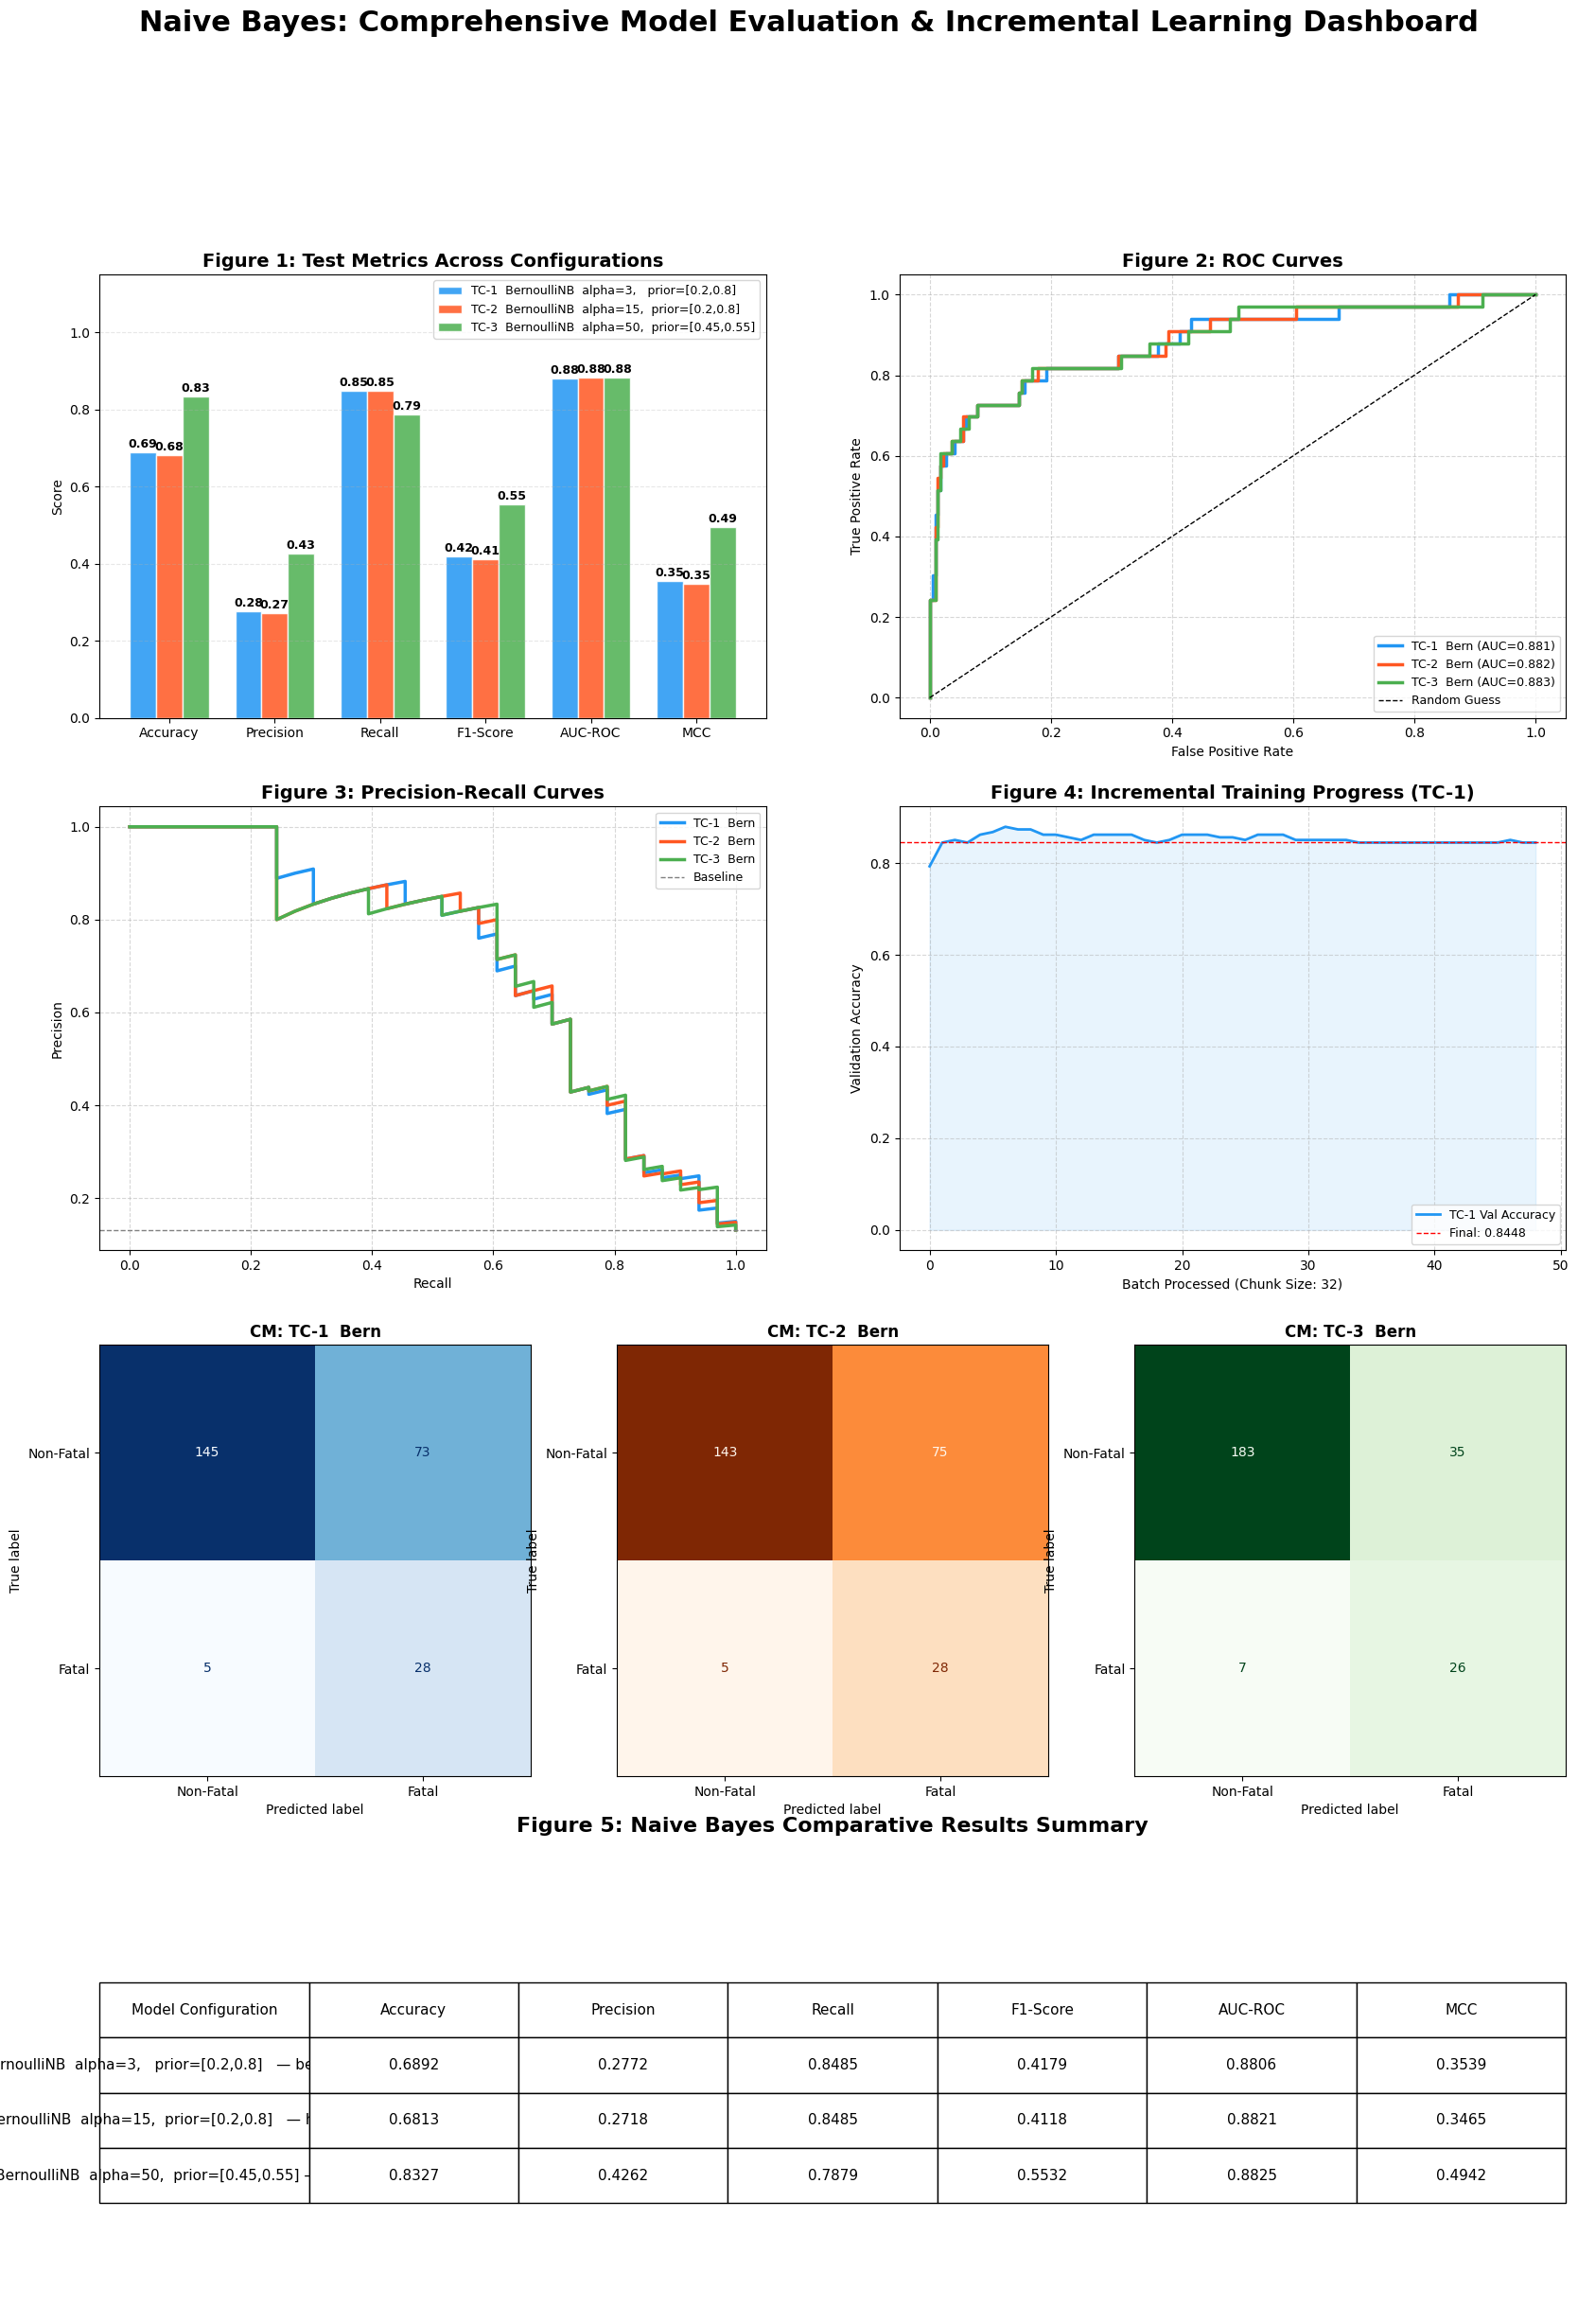

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.gridspec as gridspec
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay

# --- SETTINGS & COLORS ---
COLORS = ['#2196F3', '#FF5722', '#4CAF50']

# Configuration for the consolidated figure - 4 rows for better organization
fig = plt.figure(figsize=(20, 28))
fig.suptitle('Naive Bayes: Comprehensive Model Evaluation & Incremental Learning Dashboard',
             fontsize=22, fontweight='bold', y=0.98)

# --- 1. METRICS BAR CHART ---
ax1 = plt.subplot(4, 2, 1)
# Mapping internal result keys to display names
metric_map = {'acc': 'Accuracy', 'prec': 'Precision', 'rec': 'Recall',
              'f1': 'F1-Score', 'auc': 'AUC-ROC', 'mcc': 'MCC'}
metric_keys = list(metric_map.keys())
metric_names = list(metric_map.values())

x = np.arange(len(metric_keys))
width = 0.25

for i, r in enumerate(results):
    # Extract values based on the keys used in your training loop (acc, prec, etc.)
    vals = [r[k] for k in metric_keys]
    model_label = r['name'].split('—')[0].strip() # Shorten name for legend

    bars = ax1.bar(x + i*width, vals, width, label=model_label,
                   color=COLORS[i % len(COLORS)], alpha=0.85, edgecolor='white')

    # Add value labels on top of bars
    for bar, v in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_xticks(x + width)
ax1.set_xticklabels(metric_names)
ax1.set_ylim(0, 1.15)
ax1.set_ylabel('Score')
ax1.set_title('Figure 1: Test Metrics Across Configurations', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# --- 2. ROC CURVES ---
ax2 = plt.subplot(4, 2, 2)
for i, r in enumerate(results):
    # Using 'ypr' as defined in your evaluation loop
    fpr, tpr, _ = roc_curve(y_test, r['ypr'])
    ax2.plot(fpr, tpr, color=COLORS[i % len(COLORS)], linewidth=2.5,
             label=f"{r['name'][:10]} (AUC={r['auc']:.3f})")

ax2.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('Figure 2: ROC Curves', fontsize=14, fontweight='bold')
ax2.legend(loc='lower right', fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.5)

# --- 3. PRECISION-RECALL CURVES ---
ax3 = plt.subplot(4, 2, 3)
for i, r in enumerate(results):
    prec, rec, _ = precision_recall_curve(y_test, r['ypr'])
    ax3.plot(rec, prec, color=COLORS[i % len(COLORS)], linewidth=2.5, label=r['name'][:10])

ax3.axhline(y_test.mean(), color='grey', linestyle='--', linewidth=1, label='Baseline')
ax3.set_xlabel('Recall')
ax3.set_ylabel('Precision')
ax3.set_title('Figure 3: Precision-Recall Curves', fontsize=14, fontweight='bold')
ax3.legend(loc='upper right', fontsize=9)
ax3.grid(True, linestyle='--', alpha=0.5)

# --- 4. INCREMENTAL LEARNING CURVE ---
ax4 = plt.subplot(4, 2, 4)
# inc_chunks and inc_acc were populated during your TC-1 loop
ax4.plot(inc_chunks, inc_acc, color='#2196F3', linewidth=2, label='TC-1 Val Accuracy')
ax4.fill_between(inc_chunks, inc_acc, alpha=0.1, color='#2196F3')
ax4.axhline(inc_acc[-1], color='red', linestyle='--', linewidth=1, label=f'Final: {inc_acc[-1]:.4f}')
ax4.set_xlabel(f'Batch Processed (Chunk Size: {CHUNK})')
ax4.set_ylabel('Validation Accuracy')
ax4.set_title('Figure 4: Incremental Training Progress (TC-1)', fontsize=14, fontweight='bold')
ax4.legend(loc='lower right', fontsize=9)
ax4.grid(True, linestyle='--', alpha=0.5)

# --- 5, 6, 7. CONFUSION MATRICES ---
# Create a GridSpec for the middle row to hold three matrices
gs_cm = gridspec.GridSpec(4, 3, figure=fig)
CM_MAPS = ['Blues', 'Oranges', 'Greens']

for i, r in enumerate(results):
    ax_cm = fig.add_subplot(gs_cm[2, i])
    # Using 'yp' (predicted labels) as defined in your evaluation loop
    cm = confusion_matrix(y_test, r['yp'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Fatal', 'Fatal'])
    disp.plot(ax=ax_cm, cmap=CM_MAPS[i % 3], colorbar=False)
    ax_cm.set_title(f'CM: {r["name"][:10]}', fontsize=12, fontweight='bold')

# --- 8. SUMMARY TABLE ---
ax_table = plt.subplot(4, 1, 4)
ax_table.axis('off')

# Prepare dataframe for table
summary_df = pd.DataFrame([{
    'Model Configuration': r['name'],
    'Accuracy': f"{r['acc']:.4f}",
    'Precision': f"{r['prec']:.4f}",
    'Recall': f"{r['rec']:.4f}",
    'F1-Score': f"{r['f1']:.4f}",
    'AUC-ROC': f"{r['auc']:.4f}",
    'MCC': f"{r['mcc']:.4f}"
} for r in results])

tbl = ax_table.table(
    cellText=summary_df.values,
    colLabels=summary_df.columns,
    cellLoc='center', loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 3.5) # Scale height for readability
ax_table.set_title('Figure 5: Naive Bayes Comparative Results Summary', pad=30, fontsize=16, fontweight='bold')

# Final Layout Adjustment
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Observations from the Graphs:**

1. The ROC indicates that all three models performed significantly better than random guessing. Model 2 and Model 3 are tied for the highest AUC (0.88), showing a superior overall ability to distinguish between classes.

2. The Precision-Recall curve indicates that Model 3 maintains high precision for longer as recall increases compared to Model 1 and Model 2, making it the most reliable configuration for balanced classification.

3. The Metric Comparison bar graph indicates that Model 3 achieved the best balance across key metrics, leading in F1-score (0.55), Accuracy (0.83), and MCC (0.49), while sharing the top AUC (0.88) score.

4. The Confusion matrix indicates the following:

- Model 3 shows a strong performance in identifying non-fatalities, correctly catching 183 non-fatal incidents while maintaining the lowest number of false alarms (35).

- Model 2 is the least precise for fatal predictions, generating the highest number of false alarms (75 false positives), which significantly impacts its reliability in practical scenarios.

- All three models maintain similar Recall for fatal incidents, with Model 1 and Model 2 correctly identifying 28 fatalities, while Model 3 missed slightly more with 26 true positives.

- Model 1 and Model 2 offer the highest recall for fatalities, catching 28 fatal incidents, but at the cost of significantly more false alarms (73 and 75 respectively) compared to Model 3.

### Algorithm 5: Artifical Neural Network ###

In [31]:
# Load raw test data for display in test cases
test_df_raw  = pd.read_csv('Standardized_Test.csv')
X_test_raw   = test_df_raw.drop('fatality', axis=1)
y_test       = test_df_raw['fatality']

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

train_df_std = pd.read_csv('Standardized_Train.csv')
test_df_std  = pd.read_csv('Standardized_Test.csv')

X_train_std = train_df_std.drop('fatality', axis=1)
y_train_std = train_df_std['fatality']
X_test_std  = test_df_std.drop('fatality', axis=1)
y_test_std  = test_df_std['fatality']

pipeline = ImbPipeline([
    ('imputer',    SimpleImputer(strategy='median')),
    ('smote',      SMOTE(random_state=SEED, k_neighbors=5)),
    ('classifier', KNeighborsClassifier(n_neighbors=5, metric='euclidean'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = cross_val_score(pipeline, X_train_std, y_train_std, cv=cv, scoring='f1')
print(f"\nCross-validation F1 scores : {cv_scores}")
print(f"Mean CV F1 score           : {cv_scores.mean():.4f}")

pipeline.fit(X_train_std, y_train_std)
y_pred_knn = pipeline.predict(X_test_std)
print("\nKNN Test Set Results (Unseen 20%):")
print(classification_report(y_test_std, y_pred_knn, target_names=['Non-Fatal', 'Fatal']))

imputer_exp     = SimpleImputer(strategy='median')
X_train_imputed = imputer_exp.fit_transform(X_train_std)
smote_exp       = SMOTE(random_state=SEED, k_neighbors=5)
X_train_resampled, y_train_resampled = smote_exp.fit_resample(X_train_imputed, y_train_std)

df_train_balanced = pd.DataFrame(X_train_resampled, columns=X_train_std.columns)
df_train_balanced['fatality'] = y_train_resampled
df_train_balanced.to_csv('Balanced_Training_Set_Only.csv', index=False)
print(f"\nFile Saved : Balanced_Training_Set_Only.csv  ({len(df_train_balanced)} rows)")

df_test_export = X_test_std.copy()
df_test_export['fatality'] = y_test_std.values
df_test_export.to_csv('Test_Set_Only.csv', index=False)
print(f"File Saved : Test_Set_Only.csv  ({len(df_test_export)} rows)")

# ══════════════════════════════════════════════════════════════════
#  STEP 5 — LOAD BALANCED TRAIN + TEST FOR NEURAL NETWORK
# ══════════════════════════════════════════════════════════════════
TARGET = "fatality"

balanced_train = pd.read_csv('Balanced_Training_Set_Only.csv')
test_only      = pd.read_csv('Test_Set_Only.csv')

X_train_final = balanced_train.drop(columns=[TARGET]).values.astype(np.float32)
y_train_final = balanced_train[TARGET].values.astype(np.float32)
X_test_final  = test_only.drop(columns=[TARGET]).values.astype(np.float32)
y_test_final  = test_only[TARGET].values.astype(np.float32)

print(f"\nNN Train (SMOTE-balanced) : {X_train_final.shape}")
print(f"NN Test  (real, unseen)   : {X_test_final.shape}")
print(f"Train class dist : {pd.Series(y_train_final).value_counts().to_dict()}")
print(f"Test  class dist : {pd.Series(y_test_final).value_counts().to_dict()}")

INPUT_DIM  = X_train_final.shape[1]
OUTPUT_DIM = 1
print(f"Input features   : {INPUT_DIM}")

# ══════════════════════════════════════════════════════════════════
#  STEP 6 — MODEL DEFINITION
# ══════════════════════════════════════════════════════════════════
class IncrementalNN(nn.Module):
    def __init__(self, h1, h2, h3, dropout):
        super().__init__()
        self.hidden1 = nn.Sequential(nn.Linear(INPUT_DIM, h1), nn.BatchNorm1d(h1), nn.ReLU(), nn.Dropout(dropout))
        self.hidden2 = nn.Sequential(nn.Linear(h1, h2),        nn.BatchNorm1d(h2), nn.ReLU(), nn.Dropout(dropout))
        self.hidden3 = nn.Sequential(nn.Linear(h2, h3),        nn.BatchNorm1d(h3), nn.ReLU(), nn.Dropout(dropout))
        self.output  = nn.Sequential(nn.Linear(h3, OUTPUT_DIM), nn.Sigmoid())

    def forward(self, x):
        return self.output(self.hidden3(self.hidden2(self.hidden1(x))))

# ══════════════════════════════════════════════════════════════════
#  STEP 7 — HELPER FUNCTIONS
# ══════════════════════════════════════════════════════════════════
def evaluate(loader, model, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs, all_preds, all_labels = [], [], []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            probs  = model(Xb)
            loss   = criterion(probs, yb)
            total_loss += loss.item() * len(yb)
            correct    += ((probs >= 0.5).float() == yb).sum().item()
            total      += len(yb)
            p = probs.cpu().squeeze().numpy()
            all_probs.extend(np.atleast_1d(p).tolist())
            all_preds.extend(np.atleast_1d((p >= 0.5).astype(int)).tolist())
            all_labels.extend(yb.cpu().squeeze().numpy().tolist())
    return total_loss/total, correct/total, np.array(all_probs), np.array(all_preds), np.array(all_labels)

def save_plot_with_retries(filename, dpi=150, bbox_inches='tight', max_retries=3, delay_seconds=2):
    for attempt in range(max_retries):
        try:
            plt.savefig(filename, dpi=dpi, bbox_inches=bbox_inches)
            print(f" Plot saved: {filename}")
            return
        except OSError as e:
            print(f" Error saving {filename} (Attempt {attempt+1}/{max_retries}): {e}")
            if attempt < max_retries - 1:
                time.sleep(delay_seconds)
            else:
                raise

def run_full_pipeline(config_name, batch_size, lr, h1, h2, h3, dropout, epochs, early_stop, threshold=0.5):
    print("\n")
    print("█"*65)
    print(f"  CONFIGURATION : {config_name}")
    print(f"  batch_size={batch_size} | lr={lr} | neurons=[{h1},{h2},{h3}] | dropout={dropout}")
    print("█"*65)

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_final, y_train_final,
        test_size=0.15, random_state=SEED,
        stratify=y_train_final
    )

    def make_ds(X, y): return TensorDataset(torch.tensor(X), torch.tensor(y).unsqueeze(1))
    train_loader = DataLoader(make_ds(X_tr,         y_tr),         batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader   = DataLoader(make_ds(X_val,        y_val),        batch_size=64,         shuffle=False)
    test_loader  = DataLoader(make_ds(X_test_final, y_test_final), batch_size=64,         shuffle=False)

    model     = IncrementalNN(h1, h2, h3, dropout).to(device)
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n  Model parameters : {total_params:,}")
    print(f"  Architecture     : {INPUT_DIM} → {h1} → {h2} → {h3} → {OUTPUT_DIM}")

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_loss, patience_ctr, best_wts = float("inf"), 0, None

    print(f"\n{'─'*65}")
    print(f"  TRAINING  (batch_size={batch_size})")
    print(f"{'─'*65}")

    for epoch in range(1, epochs + 1):
        model.train()
        run_loss = correct = total = 0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(Xb)
            loss  = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            run_loss += loss.item() * len(yb)
            correct  += ((preds >= 0.5).float() == yb).sum().item()
            total    += len(yb)

        train_loss = run_loss / total
        train_acc  = correct  / total
        val_loss, val_acc, _, _, _ = evaluate(val_loader, model, criterion)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"  Epoch [{epoch:3d}/{epochs}]  "
              f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f}  |  "
              f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_ctr  = 0
            best_wts = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_ctr += 1
            if patience_ctr >= early_stop:
                print(f"\n Early stopping at epoch {epoch}.")
                break

    model.load_state_dict(best_wts)

    test_loss, test_acc, test_probs, test_preds, test_labels = evaluate(test_loader, model, criterion)
    test_preds = (test_probs >= threshold).astype(int)
    test_acc   = (test_preds == test_labels.astype(int)).mean()
    auc = roc_auc_score(test_labels, test_probs)
    f1  = f1_score(test_labels, test_preds)

    print(f"\n{'─'*65}")
    print(f"  TEST RESULTS ─ {config_name}")
    print(f"{'─'*65}")
    print(f"  Test Loss     : {test_loss:.4f}")
    print(f"  Test Accuracy : {test_acc:.4f}")
    print(f"  F1-Score      : {f1:.4f}")
    print(f"  ROC-AUC       : {auc:.4f}")
    print(f"{'─'*65}")
    print(classification_report(test_labels, test_preds, target_names=["No Fatality", "Fatality"]))

    ep_range = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"{config_name}  |  batch={batch_size}, lr={lr}, neurons=[{h1},{h2},{h3}], dropout={dropout}",
                 fontsize=12, fontweight='bold')

    axes[0].plot(ep_range, history["train_loss"], label="Train", color='#2196F3', linewidth=2)
    axes[0].plot(ep_range, history["val_loss"],   label="Val",   color='#F44336', linewidth=2)
    axes[0].set_title("Loss per Epoch"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE Loss")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(ep_range, history["train_acc"], label="Train", color='#2196F3', linewidth=2)
    axes[1].plot(ep_range, history["val_acc"],   label="Val",   color='#F44336', linewidth=2)
    axes[1].axhline(test_acc, color='#4CAF50', linestyle='--', linewidth=1.5, label=f"Test={test_acc:.4f}")
    axes[1].set_title("Accuracy per Epoch"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    cm = confusion_matrix(test_labels, test_preds)
    sns.heatmap(cm, annot=True, fmt="d", ax=axes[2], cmap="Blues",
                xticklabels=["No Fatality", "Fatality"],
                yticklabels=["No Fatality", "Fatality"])
    axes[2].set_title("Confusion Matrix"); axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("Actual")

    plt.tight_layout()
    fname = config_name.replace(" ", "_").replace(":", "").replace("─", "")
    save_plot_with_retries(f"{fname}_results.png")
    plt.show()

    fpr, tpr, _ = roc_curve(test_labels, test_probs)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='#9C27B0', linewidth=2.5, label=f"AUC = {auc:.4f}")
    plt.fill_between(fpr, tpr, alpha=0.1, color='#9C27B0')
    plt.plot([0,1],[0,1],"k--")
    plt.title(f"ROC Curve ─ {config_name}")
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend(); plt.grid(alpha=0.3)
    save_plot_with_retries(f"{fname}_roc.png")
    plt.show()

    DISPLAY_FEATURES = [
        "temperature", "wind_speed", "rainfall",
        "permit_count", "unique_job_types", "unique_work_types",
        "day_incident_pct", "latitude", "longitude"
    ]

    yt = y_test.values if hasattr(y_test, "values") else np.array(y_test)
    X_raw_for_display = X_test_raw.reset_index(drop=True)
    SEP = "=" * 70
    print(SEP)
    print("  TEST CASE RESULTS BREAKDOWN")
    print(SEP)

    yp = test_preds

    tp_idx  = np.where((yp == 1) & (yt == 1))[0]
    tn_idx  = np.where((yp == 0) & (yt == 0))[0]
    err_idx = np.where(yp != yt)[0]

    pick_tp  = tp_idx[len(tp_idx)  // 2] if len(tp_idx)  > 0 else None
    pick_tn  = tn_idx[len(tn_idx)  // 3] if len(tn_idx)  > 0 else None
    pick_err = err_idx[len(err_idx) // 2] if len(err_idx) > 0 else None

    cases = [
        (pick_tp,  "TC-1", "Correct   — Fatal caught          (True Positive)"),
        (pick_tn,  "TC-2", "Correct   — Non-Fatal confirmed   (True Negative)"),
        (pick_err, "TC-3", "Incorrect — model error           (FP or FN)"),
    ]

    print(f"\n MODEL : {config_name}")
    print(SEP)

    for (idx, tc_id, tc_desc) in cases:
        if idx is None:
            print(f"  {tc_id}: no qualifying sample found.")
            continue
        prob_val   = float(test_probs[idx])
        pred_int   = int(yp[idx])
        actual_int = int(yt[idx])
        pred_str   = "FATAL"   if pred_int   == 1 else "NON-FATAL"
        actual_str = "FATAL"   if actual_int == 1 else "NON-FATAL"
        verdict    = "CORRECT" if pred_int   == actual_int else "WRONG"

        print(f"\n  ┌─ {tc_id}  |  {tc_desc}")
        print( "  │")
        print(f"  │  Test-set sample index      : {idx}")
        print(f"  │  PREDICTED PROBABILITY      : {prob_val:.6f}")
        print( "  │  INPUT FEATURES  (original pre-scaled values):")
        row = X_raw_for_display.iloc[idx]
        for feat in DISPLAY_FEATURES:
            if feat in row.index:
                val = row[feat]
                v   = f"{val:.4f}" if isinstance(val, float) else str(val)
                print(f"  │    {feat:<26}: {v}")
        print( "  │")
        print(f"  │  PREDICTED LABEL  →  {pred_str:<12}  (encoded = {pred_int})")
        print(f"  │  ACTUAL LABEL     →  {actual_str:<12}  (encoded = {actual_int})")
        print(f"  │  OUTCOME          →  {verdict}")
        print( "  └" + "─" * 60)

    print()
    print(SEP)
    print("  Test set used        : held-out 20% stratified split  (no data leakage)")
    print(SEP)

    torch.save(model.state_dict(), f"{fname}_model.pth")
    print(f"\n Model saved: {fname}_model.pth")

    report_dict  = classification_report(test_labels, test_preds, target_names=["No Fatality", "Fatality"], output_dict=True)
    fatal_recall = report_dict.get('Fatality', {}).get('recall', 0.0)

    return {
        "Config"         : config_name,
        "Batch Size"     : batch_size,
        "LR"             : lr,
        "Neurons"        : f"[{h1},{h2},{h3}]",
        "Dropout"        : dropout,
        "Test Acc"       : round(test_acc, 2),
        "F1-Score"       : round(f1, 2),
        "ROC-AUC"        : round(auc, 4),
        "Test Loss"      : round(test_loss, 2),
        "Recall (Fatal)" : round(float(fatal_recall), 2),
    }

print(" All functions defined. Ready to run configurations.")
results = []

Device: cpu

Cross-validation F1 scores : [0.70769231 0.71186441 0.47457627 0.52631579 0.58064516]
Mean CV F1 score           : 0.6002

KNN Test Set Results (Unseen 20%):
              precision    recall  f1-score   support

   Non-Fatal       0.94      0.94      0.94       218
       Fatal       0.62      0.61      0.62        33

    accuracy                           0.90       251
   macro avg       0.78      0.78      0.78       251
weighted avg       0.90      0.90      0.90       251


File Saved : Balanced_Training_Set_Only.csv  (1736 rows)
File Saved : Test_Set_Only.csv  (251 rows)

NN Train (SMOTE-balanced) : (1736, 24)
NN Test  (real, unseen)   : (251, 24)
Train class dist : {0.0: 868, 1.0: 868}
Test  class dist : {0.0: 218, 1.0: 33}
Input features   : 24
 All functions defined. Ready to run configurations.


### ANNS Hyperparameters ###

| Model | Batch Size | LR | Neurons | Dropout | Test Acc | F1-Score | ROC-AUC | Test Loss | Recall (Fatal) | Config |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :--- |
| **Model_1** | 128 | 0.00200 | [32, 16, 8] | 0.65 | 0.96 | 0.85 | 0.88 | 16 | 0.24 | 0.76 |
| **Model_2** | 32 | 0.00030 | [128, 64, 32] | 0.38 | 0.96 | 0.85 | 0.91 | 27 | 0.17 | 0.79 |
| **Model_3** | 12 | 0.00008 | [224, 112, 56] | 0.18 | 0.90 | 0.69 | 0.92 | 30 | 0.16 | 0.82 |

### ANNS: MODEL 1 ###



█████████████████████████████████████████████████████████████████
  CONFIGURATION : Model_1
  batch_size=128 | lr=0.002 | neurons=[32,16,8] | dropout=0.65
█████████████████████████████████████████████████████████████████

  Model parameters : 1,585
  Architecture     : 24 → 32 → 16 → 8 → 1

─────────────────────────────────────────────────────────────────
  TRAINING  (batch_size=128)
─────────────────────────────────────────────────────────────────
  Epoch [  1/40]  Train Loss: 0.7099  Acc: 0.5256  |  Val Loss: 0.6899  Acc: 0.5402
  Epoch [  2/40]  Train Loss: 0.7122  Acc: 0.4986  |  Val Loss: 0.6821  Acc: 0.6398
  Epoch [  3/40]  Train Loss: 0.7090  Acc: 0.5241  |  Val Loss: 0.6737  Acc: 0.7356
  Epoch [  4/40]  Train Loss: 0.6871  Acc: 0.5341  |  Val Loss: 0.6675  Acc: 0.8084
  Epoch [  5/40]  Train Loss: 0.6828  Acc: 0.5455  |  Val Loss: 0.6625  Acc: 0.8314
  Epoch [  6/40]  Train Loss: 0.6788  Acc: 0.5575  |  Val Loss: 0.6576  Acc: 0.8429
  Epoch [  7/40]  Train Loss: 0.6699  Acc

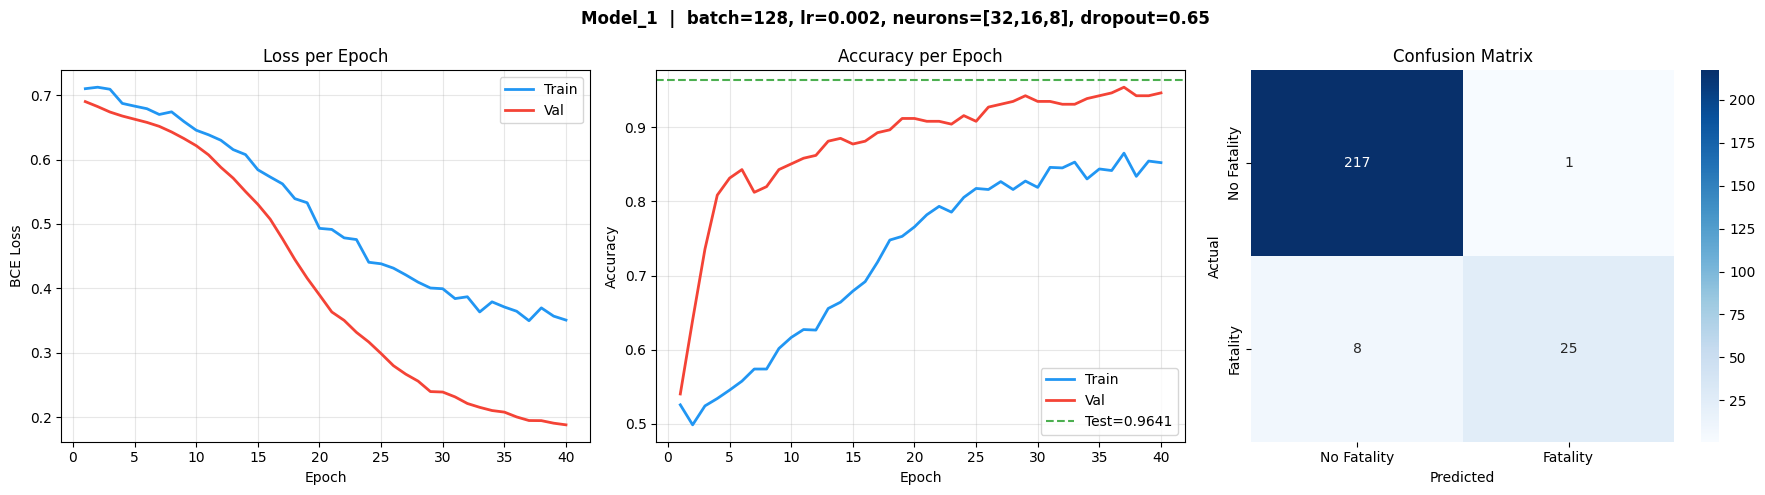

 Plot saved: Model_1_roc.png


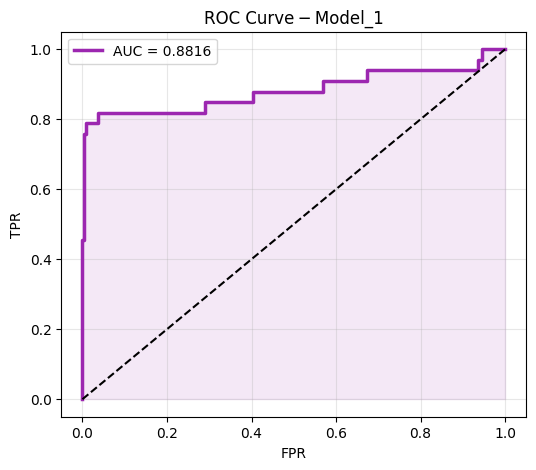

  TEST CASE RESULTS BREAKDOWN

 MODEL : Model_1

  ┌─ TC-1  |  Correct   — Fatal caught          (True Positive)
  │
  │  Test-set sample index      : 140
  │  PREDICTED PROBABILITY      : 0.988849
  │  INPUT FEATURES  (original pre-scaled values):
  │    temperature               : 0.6735
  │    wind_speed                : -0.0480
  │    rainfall                  : -0.4323
  │    permit_count              : -0.2884
  │    unique_job_types          : -0.3169
  │    unique_work_types         : -0.4259
  │    day_incident_pct          : -0.0786
  │    latitude                  : 1.0104
  │    longitude                 : -3.7441
  │
  │  PREDICTED LABEL  →  FATAL         (encoded = 1)
  │  ACTUAL LABEL     →  FATAL         (encoded = 1)
  │  OUTCOME          →  CORRECT
  └────────────────────────────────────────────────────────────

  ┌─ TC-2  |  Correct   — Non-Fatal confirmed   (True Negative)
  │
  │  Test-set sample index      : 83
  │  PREDICTED PROBABILITY      : 0.206049
  │  INPUT

In [32]:
result1 = run_full_pipeline(
    config_name = "Model_1",
    batch_size  = 128,
    lr          = 2e-3,
    h1          = 32,
    h2          = 16,
    h3          = 8,
    dropout     = 0.65,
    epochs      = 40,
    early_stop  = 6,
    threshold   = 0.75
)
results.append(result1)

### ANNS: MODEL 2 ###



█████████████████████████████████████████████████████████████████
  CONFIGURATION : Model_2
  batch_size=32 | lr=0.0003 | neurons=[128,64,32] | dropout=0.38
█████████████████████████████████████████████████████████████████

  Model parameters : 14,017
  Architecture     : 24 → 128 → 64 → 32 → 1

─────────────────────────────────────────────────────────────────
  TRAINING  (batch_size=32)
─────────────────────────────────────────────────────────────────
  Epoch [  1/150]  Train Loss: 0.6768  Acc: 0.5747  |  Val Loss: 0.6390  Acc: 0.6513
  Epoch [  2/150]  Train Loss: 0.6304  Acc: 0.6311  |  Val Loss: 0.5767  Acc: 0.8046
  Epoch [  3/150]  Train Loss: 0.5791  Acc: 0.7133  |  Val Loss: 0.5252  Acc: 0.8659
  Epoch [  4/150]  Train Loss: 0.5237  Acc: 0.7670  |  Val Loss: 0.4717  Acc: 0.8697
  Epoch [  5/150]  Train Loss: 0.4792  Acc: 0.8091  |  Val Loss: 0.4220  Acc: 0.8812
  Epoch [  6/150]  Train Loss: 0.4509  Acc: 0.8207  |  Val Loss: 0.3835  Acc: 0.9004
  Epoch [  7/150]  Train Loss: 

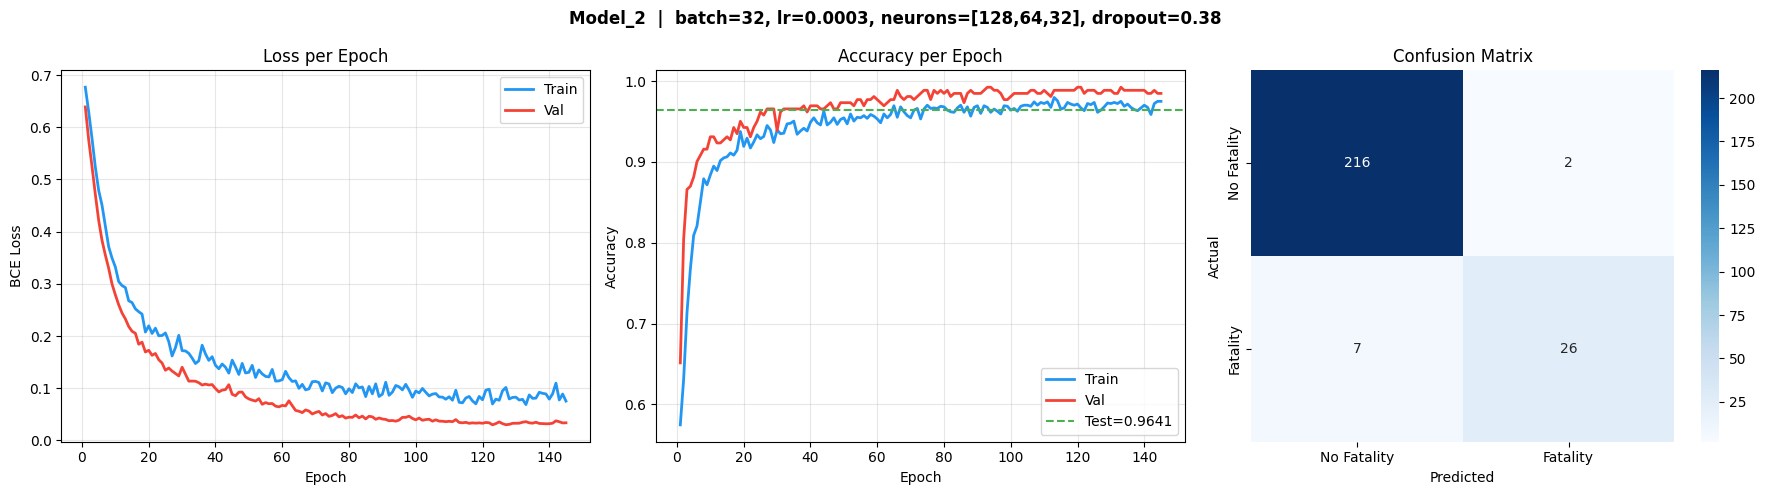

 Plot saved: Model_2_roc.png


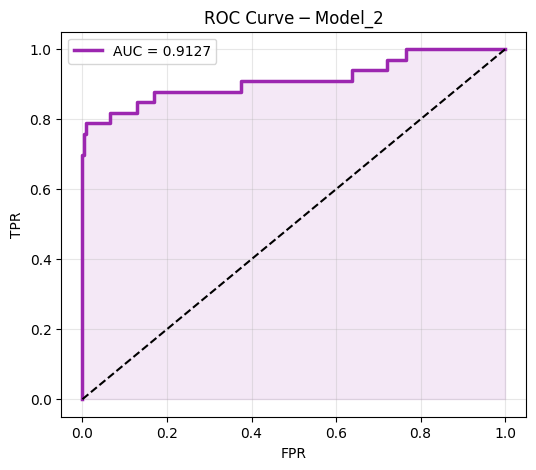

  TEST CASE RESULTS BREAKDOWN

 MODEL : Model_2

  ┌─ TC-1  |  Correct   — Fatal caught          (True Positive)
  │
  │  Test-set sample index      : 141
  │  PREDICTED PROBABILITY      : 0.998276
  │  INPUT FEATURES  (original pre-scaled values):
  │    temperature               : 1.2938
  │    wind_speed                : 0.6366
  │    rainfall                  : 0.0573
  │    permit_count              : -0.1776
  │    unique_job_types          : -0.2948
  │    unique_work_types         : -0.4038
  │    day_incident_pct          : 0.4516
  │    latitude                  : -1.0630
  │    longitude                 : -3.2866
  │
  │  PREDICTED LABEL  →  FATAL         (encoded = 1)
  │  ACTUAL LABEL     →  FATAL         (encoded = 1)
  │  OUTCOME          →  CORRECT
  └────────────────────────────────────────────────────────────

  ┌─ TC-2  |  Correct   — Non-Fatal confirmed   (True Negative)
  │
  │  Test-set sample index      : 83
  │  PREDICTED PROBABILITY      : 0.003092
  │  INPUT F

In [33]:
result2 = run_full_pipeline(
    config_name = "Model_2",
    batch_size  = 32,
    lr          = 3e-4,
    h1          = 128,
    h2          = 64,
    h3          = 32,
    dropout     = 0.38,
    epochs      = 150,
    early_stop  = 22,
    threshold   = 0.50
)
results.append(result2)

### ANNS: MODEL 3



█████████████████████████████████████████████████████████████████
  CONFIGURATION : Model_3
  batch_size=12 | lr=8e-05 | neurons=[224,112,56] | dropout=0.18
█████████████████████████████████████████████████████████████████

  Model parameters : 37,969
  Architecture     : 24 → 224 → 112 → 56 → 1

─────────────────────────────────────────────────────────────────
  TRAINING  (batch_size=12)
─────────────────────────────────────────────────────────────────
  Epoch [  1/300]  Train Loss: 0.6747  Acc: 0.5792  |  Val Loss: 0.5782  Acc: 0.7701
  Epoch [  2/300]  Train Loss: 0.5755  Acc: 0.7261  |  Val Loss: 0.4920  Acc: 0.8544
  Epoch [  3/300]  Train Loss: 0.5099  Acc: 0.7842  |  Val Loss: 0.4172  Acc: 0.8812
  Epoch [  4/300]  Train Loss: 0.4528  Acc: 0.8361  |  Val Loss: 0.3843  Acc: 0.9119
  Epoch [  5/300]  Train Loss: 0.4118  Acc: 0.8531  |  Val Loss: 0.3515  Acc: 0.9004
  Epoch [  6/300]  Train Loss: 0.3817  Acc: 0.8730  |  Val Loss: 0.3212  Acc: 0.9119
  Epoch [  7/300]  Train Loss:

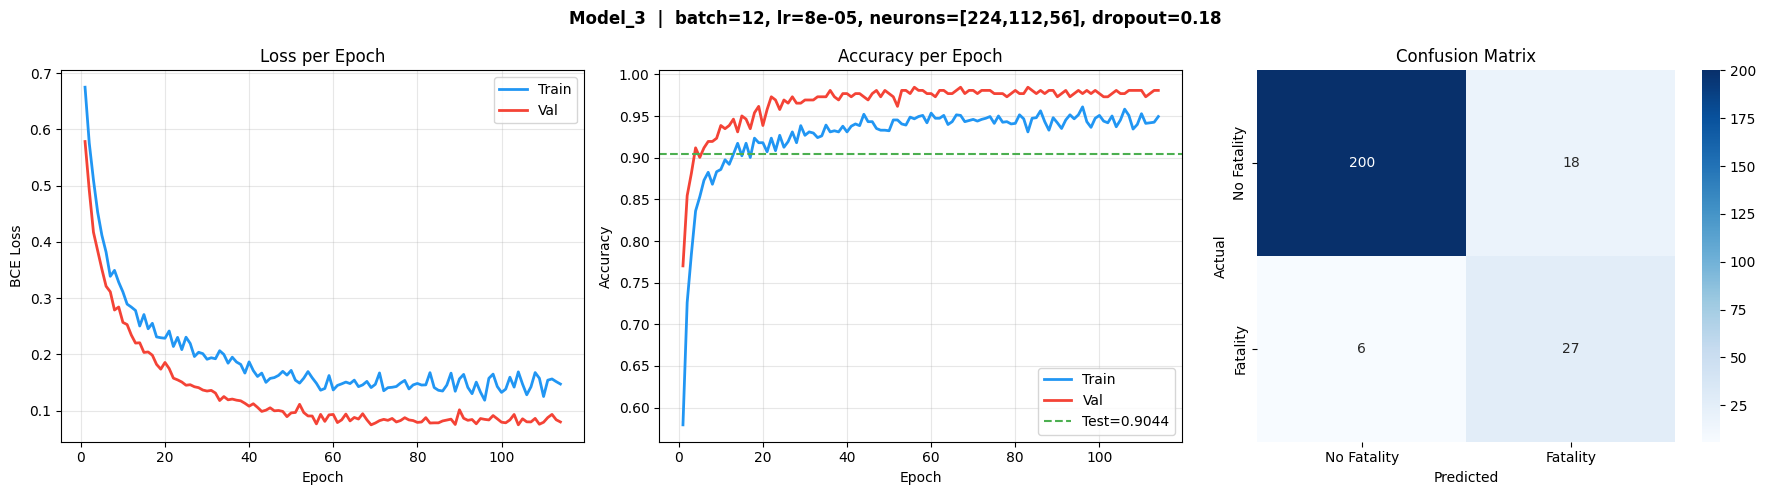

 Plot saved: Model_3_roc.png


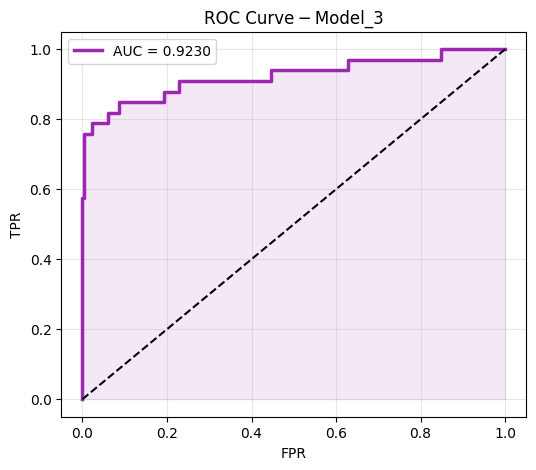

  TEST CASE RESULTS BREAKDOWN

 MODEL : Model_3

  ┌─ TC-1  |  Correct   — Fatal caught          (True Positive)
  │
  │  Test-set sample index      : 141
  │  PREDICTED PROBABILITY      : 0.974768
  │  INPUT FEATURES  (original pre-scaled values):
  │    temperature               : 1.2938
  │    wind_speed                : 0.6366
  │    rainfall                  : 0.0573
  │    permit_count              : -0.1776
  │    unique_job_types          : -0.2948
  │    unique_work_types         : -0.4038
  │    day_incident_pct          : 0.4516
  │    latitude                  : -1.0630
  │    longitude                 : -3.2866
  │
  │  PREDICTED LABEL  →  FATAL         (encoded = 1)
  │  ACTUAL LABEL     →  FATAL         (encoded = 1)
  │  OUTCOME          →  CORRECT
  └────────────────────────────────────────────────────────────

  ┌─ TC-2  |  Correct   — Non-Fatal confirmed   (True Negative)
  │
  │  Test-set sample index      : 81
  │  PREDICTED PROBABILITY      : 0.040190
  │  INPUT F

In [34]:
result3 = run_full_pipeline(
    config_name = "Model_3",
    batch_size  = 12,
    lr          = 8e-5,
    h1          = 224,
    h2          = 112,
    h3          = 56,
    dropout     = 0.18,
    epochs      = 300,
    early_stop  = 45,
    threshold   = 0.18
)
results.append(result3)

In [35]:
### ANN: Overfitting / Underfitting & Cross-Validation ###

from sklearn.metrics import confusion_matrix, recall_score, f1_score, precision_score, roc_auc_score
import torch
import numpy as np

SEP  = "=" * 70
SEP2 = "-" * 68

ann_configs = [
    ("Model_1",  32,  16,  8,  0.65, 0.75),
    ("Model_2", 128,  64, 32,  0.38, 0.50),
    ("Model_3", 224, 112, 56,  0.18, 0.18),
]

print(SEP)
print("  ANN — OVERFITTING / UNDERFITTING DIAGNOSTIC")
print(SEP)

for i, (cname, h1, h2, h3, drop, thresh) in enumerate(ann_configs):
    fname = cname.replace(" ", "_").replace(":", "").replace("─", "")

    m = IncrementalNN(h1=h1, h2=h2, h3=h3, dropout=drop).to(device)
    m.load_state_dict(torch.load(f"{fname}_model.pth", map_location=device))
    m.eval()

    with torch.no_grad():
        train_probs = m(torch.tensor(X_train_final).to(device)).cpu().numpy().squeeze()
        test_probs  = m(torch.tensor(X_test_final).to(device)).cpu().numpy().squeeze()

    train_preds = (train_probs >= thresh).astype(int)
    test_preds  = (test_probs  >= thresh).astype(int)

    y_tr = y_train_final.astype(int)
    y_te = y_test_final.astype(int)

    train_recall = recall_score(y_tr, train_preds, zero_division=0)
    test_recall  = recall_score(y_te, test_preds,  zero_division=0)
    train_f1     = f1_score(y_tr, train_preds, zero_division=0)
    test_f1      = f1_score(y_te, test_preds,  zero_division=0)
    test_prec    = precision_score(y_te, test_preds, zero_division=0)
    test_auc     = roc_auc_score(y_te, test_probs)
    gap_recall   = train_recall - test_recall
    gap_f1       = train_f1    - test_f1

    cm             = confusion_matrix(y_te, test_preds)
    tn, fp, fn, tp = cm.ravel()
    total_fatal    = tp + fn

    if test_recall < 0.60:
        verdict = "UNDERFITTING — fatal recall too low, missing incidents"
    elif test_prec < 0.15:
        verdict = "DEGENERATE   — precision too low, predicting fatal for everything"
    elif gap_recall > 0.15:
        verdict = "OVERFITTING  — recall drops significantly on unseen data"
    elif gap_f1 > 0.10:
        verdict = "MILD OVERFIT — F1 gap notable between train and test"
    else:
        verdict = "GOOD FIT"

    row = results[i]

    print(f"\n  Model {i+1} ({cname})  |  [{h1} → {h2} → {h3}]  dropout={drop}  threshold={thresh}")
    print(f"  Batch={row['Batch Size']}   LR={row['LR']}   Neurons={row['Neurons']}")
    print(f"  {SEP2}")
    print(f"  {'Metric':<28}  {'Train':>8}  {'Test':>8}  {'Gap':>8}")
    print(f"  {SEP2}")
    print(f"  {'Recall (Fatal)':<28}  {train_recall:>8.4f}  {test_recall:>8.4f}  {gap_recall:>+8.4f}  <- primary")
    print(f"  {'F1-Score (Fatal)':<28}  {train_f1:>8.4f}  {test_f1:>8.4f}  {gap_f1:>+8.4f}  <- secondary")
    print(f"  {'AUC-ROC':<28}  {'  —':>8}  {test_auc:>8.4f}  {'  —':>8}")
    print(f"  {'Precision (Fatal)':<28}  {'  —':>8}  {test_prec:>8.4f}  {'  —':>8}  <- floor check")
    print(f"  {SEP2}")
    print(f"  Fatal incidents caught  :  {tp} / {total_fatal}  (missed: {fn})")
    print(f"  False alarms raised     :  {fp}")
    print(f"  Fit verdict             :  {verdict}")

print(f"\n{SEP}")

# ── 5-Fold Cross-Validation ───────────────────────────────────────────────────
# Note: CV re-trains a fresh model on each fold using the same architecture.
# This is the standard approach for neural network CV evaluation.

print("\n")
print(SEP)
print("  ANN — 5-FOLD CROSS-VALIDATION")
print(SEP)

from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for cname, h1, h2, h3, drop, thresh in ann_configs:
    fold_recalls = []
    fold_f1s     = []
    fold_aucs    = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_final, y_train_final.astype(int))):
        X_tr   = X_train_final[train_idx]
        y_tr   = y_train_final[train_idx]
        X_val  = X_train_final[val_idx]
        y_val  = y_train_final[val_idx].astype(int)

        fold_model = IncrementalNN(h1=h1, h2=h2, h3=h3, dropout=drop).to(device)
        criterion  = torch.nn.BCELoss()
        optimizer  = torch.optim.Adam(fold_model.parameters(), lr=0.001, weight_decay=1e-4)

        ds     = TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr).unsqueeze(1))
        loader = DataLoader(ds, batch_size=32, shuffle=True, drop_last=True)

        fold_model.train()
        for _ in range(30):              # 30 epochs per fold — fast but representative
            for Xb, yb in loader:
                Xb, yb = Xb.to(device), yb.to(device)
                optimizer.zero_grad()
                criterion(fold_model(Xb), yb).backward()
                optimizer.step()

        fold_model.eval()
        with torch.no_grad():
            val_probs = fold_model(torch.tensor(X_val).to(device)).cpu().numpy().squeeze()

        val_preds = (val_probs >= thresh).astype(int)

        fold_recalls.append(recall_score(y_val, val_preds, zero_division=0))
        fold_f1s.append(f1_score(y_val, val_preds, zero_division=0))
        try:
            fold_aucs.append(roc_auc_score(y_val, val_probs))
        except ValueError:
            pass    # skip if only one class in fold

    r_mean, r_std = np.mean(fold_recalls), np.std(fold_recalls)
    f_mean, f_std = np.mean(fold_f1s),     np.std(fold_f1s)
    a_mean, a_std = np.mean(fold_aucs),    np.std(fold_aucs)
    stability     = "stable" if r_std <= 0.05 else "high variance — unstable across folds"

    print(f"\n  Model {cname}  |  [{h1} → {h2} → {h3}]  dropout={drop}  threshold={thresh}")
    print(f"  Fold Recalls :  {[round(f, 4) for f in fold_recalls]}")
    print(f"  Mean Recall  :  {r_mean:.4f}   |   Std: {r_std:.4f}   |   {stability}   <- primary")
    print(f"  Mean F1      :  {f_mean:.4f}   |   Std: {f_std:.4f}")
    print(f"  Mean AUC     :  {a_mean:.4f}   |   Std: {a_std:.4f}")

print(f"\n{SEP}\n")

  ANN — OVERFITTING / UNDERFITTING DIAGNOSTIC

  Model 1 (Model_1)  |  [32 → 16 → 8]  dropout=0.65  threshold=0.75
  Batch=128   LR=0.002   Neurons=[32,16,8]
  --------------------------------------------------------------------
  Metric                           Train      Test       Gap
  --------------------------------------------------------------------
  Recall (Fatal)                  0.8698    0.7576   +0.1122  <- primary
  F1-Score (Fatal)                0.9298    0.8475   +0.0823  <- secondary
  AUC-ROC                              —    0.8816         —
  Precision (Fatal)                    —    0.9615         —  <- floor check
  --------------------------------------------------------------------
  Fatal incidents caught  :  25 / 33  (missed: 8)
  False alarms raised     :  1
  Fit verdict             :  GOOD FIT

  Model 2 (Model_2)  |  [128 → 64 → 32]  dropout=0.38  threshold=0.5
  Batch=32   LR=0.0003   Neurons=[128,64,32]
  ----------------------------------------------

### ANNS Graphs ###

 Plot saved: combined_2x2_grid.png


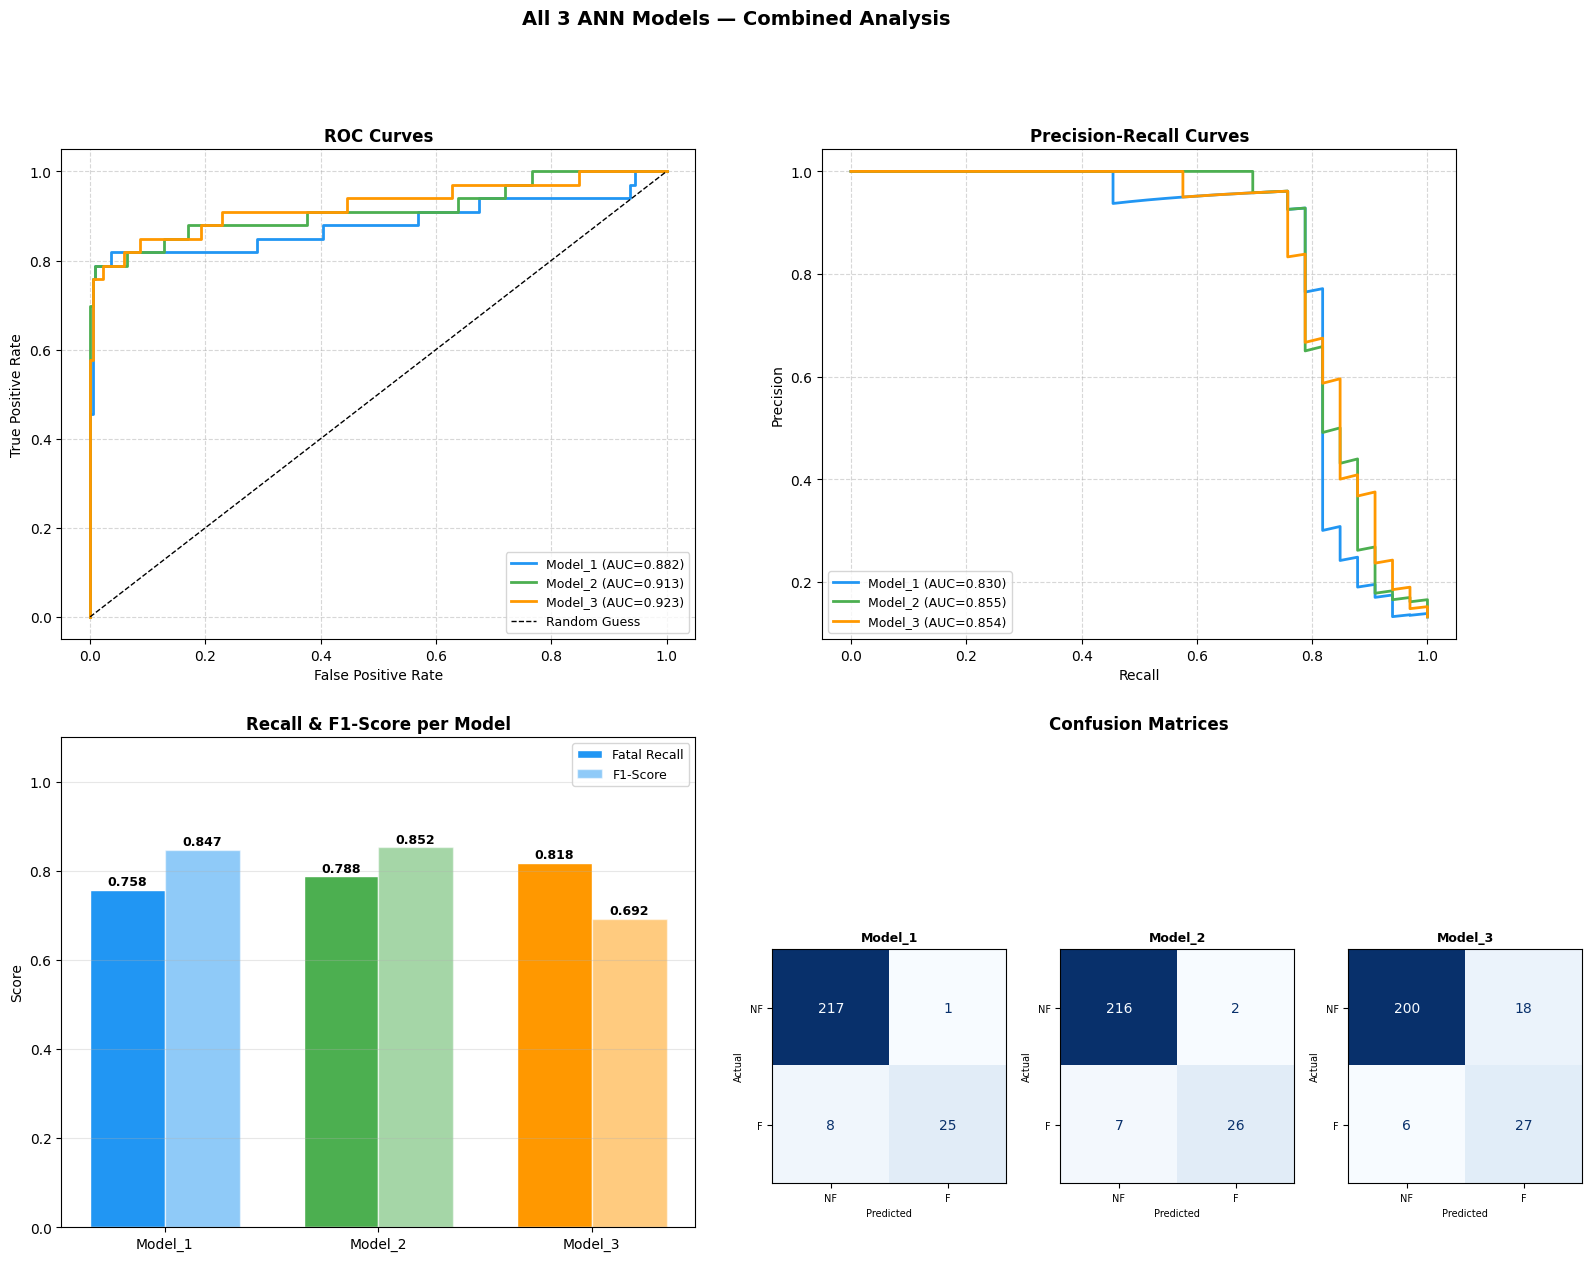


  FINAL COMPARATIVE ANALYSIS ─ ALL 3 CONFIGURATIONS
 Config  Batch Size      LR      Neurons  Dropout  Test Acc  F1-Score  ROC-AUC  Test Loss  Recall (Fatal)
Model_1         128 0.00200    [32,16,8]     0.65      0.96      0.85   0.8816       0.24            0.76
Model_2          32 0.00030  [128,64,32]     0.38      0.96      0.85   0.9127       0.17            0.79
Model_3          12 0.00008 [224,112,56]     0.18      0.90      0.69   0.9230       0.16            0.82

 Best Configuration by Recall : Model_3
   Accuracy : 0.9
   F1-Score : 0.69
   ROC-AUC  : 0.923

 All combined graphs saved!


,Batch Size,LR,Neurons,Dropout,Test Acc,F1-Score,ROC-AUC,Test Loss,Recall (Fatal)
Config,,,,,,,,,
Model_1,128,0.00200,"[32,16,8]",0.65,0.96,0.85,0.8816,0.24,0.76
Model_2,32,0.00030,"[128,64,32]",0.38,0.96,0.85,0.9127,0.17,0.79
Model_3,12,0.00008,"[224,112,56]",0.18,0.90,0.69,0.9230,0.16,0.82


In [36]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, ConfusionMatrixDisplay

# ── Load test data and models ──────────────────────────────────
test_check   = pd.read_csv('Test_Set_Only.csv')
X_test_graph = test_check.drop(columns=['fatality']).values.astype(np.float32)
y_test_graph = test_check['fatality'].values.astype(int)

configs_info = [
    ("Model_1",  32,  16,  8,  0.65, "#2196F3", 0.75),
    ("Model_2", 128,  64, 32,  0.38, "#4CAF50", 0.50),
    ("Model_3", 224, 112, 56,  0.18, "#FF9800", 0.18),
]

loaded_models = []
for (cname, h1, h2, h3, drop, color, thresh) in configs_info:
    fname = cname.replace(" ", "_").replace(":", "").replace("─", "")
    m = IncrementalNN(h1=h1, h2=h2, h3=h3, dropout=drop).to(device)
    m.load_state_dict(torch.load(f"{fname}_model.pth", map_location=device))
    m.eval()
    with torch.no_grad():
        probs = m(torch.tensor(X_test_graph).to(device)).cpu().numpy().squeeze()
        preds = (probs >= thresh).astype(int)
    loaded_models.append((cname, color, probs, preds))

# ── 2x2 Grid ──────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
fig.suptitle("All 3 ANN Models — Combined Analysis", fontsize=14, fontweight='bold')

# ── Plot 1 (top-left): ROC Curves ─────────────────────────────
ax1 = fig.add_subplot(2, 2, 1)
for (cname, color, probs, preds) in loaded_models:
    fpr, tpr, _ = roc_curve(y_test_graph, probs)
    roc_auc     = auc(fpr, tpr)
    ax1.plot(fpr, tpr, color=color, linewidth=2, label=f"{cname} (AUC={roc_auc:.3f})")
ax1.plot([0,1],[0,1], 'k--', linewidth=1, label='Random Guess')
ax1.set_title("ROC Curves", fontsize=12, fontweight='bold')
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.legend(fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.5)

# ── Plot 2 (top-right): Precision-Recall Curves ───────────────
ax2 = fig.add_subplot(2, 2, 2)
for (cname, color, probs, preds) in loaded_models:
    precision, recall, _ = precision_recall_curve(y_test_graph, probs)
    pr_auc = auc(recall, precision)
    ax2.plot(recall, precision, color=color, linewidth=2, label=f"{cname} (AUC={pr_auc:.3f})")
ax2.set_title("Precision-Recall Curves", fontsize=12, fontweight='bold')
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.legend(fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.5)

# ── Plot 3 (bottom-left): Recall & F1 Bar Chart ───────────────
ax3 = fig.add_subplot(2, 2, 3)
model_names = [r[0] for r in loaded_models]
colors_list = [r[1] for r in loaded_models]
x = np.arange(len(model_names))
w = 0.35

recalls = [
    classification_report(y_test_graph, preds, output_dict=True)['1']['recall']
    for (_, _, probs, preds) in loaded_models
]
f1s = [
    f1_score(y_test_graph, preds)
    for (_, _, probs, preds) in loaded_models
]

bars1 = ax3.bar(x - w/2, recalls, w, label='Fatal Recall', color=colors_list, edgecolor='white')
bars2 = ax3.bar(x + w/2, f1s,    w, label='F1-Score',     color=colors_list, edgecolor='white', alpha=0.5)
for bar, v in zip(bars1, recalls):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
for bar, v in zip(bars2, f1s):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
ax3.set_title("Recall & F1-Score per Model", fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(model_names)
ax3.set_ylim(0, 1.1)
ax3.set_ylabel("Score")
ax3.legend(fontsize=9)
ax3.grid(axis='y', alpha=0.3)

# ── Plot 4 (bottom-right): Confusion Matrices side by side ────
ax4 = fig.add_subplot(2, 2, 4)
ax4.axis('off')
ax4.set_title("Confusion Matrices", fontsize=12, fontweight='bold')

# Place 3 confusion matrices inside bottom-right quadrant
for i, (cname, color, probs, preds) in enumerate(loaded_models):
    left   = 0.52 + i * 0.16
    bottom = 0.05
    width  = 0.13
    height = 0.35
    sub_ax = fig.add_axes([left, bottom, width, height])
    cm     = confusion_matrix(y_test_graph, preds)
    disp   = ConfusionMatrixDisplay(cm, display_labels=['NF', 'F'])
    disp.plot(ax=sub_ax, colorbar=False, cmap='Blues')
    sub_ax.set_title(cname, fontsize=9, fontweight='bold')
    sub_ax.set_xlabel("Predicted", fontsize=7)
    sub_ax.set_ylabel("Actual", fontsize=7)
    sub_ax.tick_params(labelsize=7)

save_plot_with_retries("combined_2x2_grid.png")
plt.show()

# ── Final Comparative Table ────────────────────────────────────
comparison_df = pd.DataFrame(results)
print("\n" + "="*80)
print("  FINAL COMPARATIVE ANALYSIS ─ ALL 3 CONFIGURATIONS")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

best_idx = comparison_df["Recall (Fatal)"].idxmax()
print(f"\n Best Configuration by Recall : {comparison_df.loc[best_idx, 'Config']}")
print(f"   Accuracy : {comparison_df.loc[best_idx, 'Test Acc']}")
print(f"   F1-Score : {comparison_df.loc[best_idx, 'F1-Score']}")
print(f"   ROC-AUC  : {comparison_df.loc[best_idx, 'ROC-AUC']}")
print("\n All combined graphs saved!")
comparison_df.set_index("Config")

**Observations from the Graphs:**

1. The ROC indicates that all three models performed significantly better than random guessing. Model 3 has the highest AUC (0.923), showing a superior overall ability to distinguish between classes compared to Model 1 and Model 2.

2. The Precision-Recall curve indicates that Model 2 maintains high precision for longer as recall increases compared to Model 1 and Model 3, making it a highly reliable configuration for balanced classification.

3. The Metric Comparison bar graph indicates that Model 2 achieved the best balance across key metrics, leading in F1-score (0.852) while maintaining a strong Fatal Recall (0.788).

4. The Confusion matrix indicates the following:

- Model 3 shows a strong performance in identifying fatalities, catching 27 fatal incidents, which is the highest among all three configurations.

- Model 3 is the least precise for non-fatal predictions, generating the highest number of false alarms (18 false positives), which significantly impacts its reliability in practical scenarios.

- All three models maintain strong Recall for fatal incidents, with Model 3 correctly identifying 27 fatalities, Model 2 identifying 26, and Model 1 identifying 25.

- Model 1 offers the highest specificity, correctly identifying 217 non-fatal incidents with the fewest false alarms (1), but at the cost of catching the fewest total fatalities.

### Selection of the Best Model from all the Models ###

The best models that were shortlisted for each algorithm are as follows:

1. Logistic Regression Model 3
2. KNN Model 3
3. SVM Model 2
4. ANNs Model 3
5. Naive Bayes Model 2

While Logistic Regression Model 3 is technically the best final model because it achieved the best results in terms of balance across performance metrics and converged with minimum loss, its extensive training time makes it expensive in terms of hardware power. Although recall is a critical metric, it is not the only consideration; KNN was ruled out due to its significant overfitting tendencies and struggles in higher dimensions, while reliable models like ANNs were deemed too computationally expensive for scaling. Consequently, as Logistic Regression is constrained by hardware costs and time, the choice narrows to SVM Model 2 and Naive Bayes Model 2, with SVM Model 2 ultimately serving as the most feasible and efficient choice for a balanced system because Naive Bayes may cause too many false alarms to occur.


### Second Split on SVM Model 2 ###

In [37]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.impute import SimpleImputer

# =========================
# 1. Load pre-split standardized data
# =========================
train_df = pd.read_csv('Standardized_Train_70.csv')
test_df  = pd.read_csv('Standardized_Test_30.csv')

X_train = train_df.drop('fatality', axis=1)
y_train = train_df['fatality']

X_test = test_df.drop('fatality', axis=1)
y_test = test_df['fatality']

# =========================
# 2. Pipeline (SMOTE inside)
# =========================
pipeline = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('classifier', KNeighborsClassifier(
        n_neighbors=5,
        metric='euclidean'
    ))
])

# =========================
# 3. Cross-validation (on training data only)
# =========================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1')

print(f"Cross-validation F1 scores: {cv_scores}")
print(f"Mean CV F1 score: {cv_scores.mean():.4f}")

# =========================
# 4. Final Model Training & Test Evaluation
# =========================
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("\nTest Set Results (Unseen 30%):")
print(classification_report(y_test, y_pred, target_names=['Non-Fatal', 'Fatal']))

# =========================
# 5. Exporting the Balanced Training Set
# =========================
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)

smote_exporter = SMOTE(random_state=42, k_neighbors=5)
X_train_resampled, y_train_resampled = smote_exporter.fit_resample(X_train_imputed, y_train)

df_train_balanced = pd.DataFrame(X_train_resampled, columns=X_train.columns)
df_train_balanced['fatality'] = y_train_resampled

df_train_balanced.to_csv('Balanced_Training_Set_Only_70.csv', index=False)
print(f"File Saved: Balanced_Training_Set_Only_70.csv")
print(f"Training set rows (70% + SMOTE): {len(df_train_balanced)}")

# =========================
# 6. Exporting the Test Set
# =========================
df_test = X_test.copy()
df_test['fatality'] = y_test.values

df_test.to_csv('Test_Set_Only_30.csv', index=False)
print(f"File Saved: Test_Set_Only_30.csv")
print(f"Test set rows (unseen 30%): {len(df_test)}")

Cross-validation F1 scores: [0.65517241 0.63157895 0.52       0.47058824 0.53061224]
Mean CV F1 score: 0.5616

Test Set Results (Unseen 30%):
              precision    recall  f1-score   support

   Non-Fatal       0.94      0.92      0.93       326
       Fatal       0.54      0.62      0.58        50

    accuracy                           0.88       376
   macro avg       0.74      0.77      0.75       376
weighted avg       0.89      0.88      0.88       376

File Saved: Balanced_Training_Set_Only_70.csv
Training set rows (70% + SMOTE): 1520
File Saved: Test_Set_Only_30.csv
Test set rows (unseen 30%): 376


In [38]:
# ── Global seed ───────────────────────────────────────────────────────────────
SEED = 42
import random, os
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# ── Data loading ──────────────────────────────────────────────────────────────
train_df = pd.read_csv("Balanced_Training_Set_Only_70.csv")
test_df  = pd.read_csv("Test_Set_Only_30.csv")

target_col = "fatality"

X_train = train_df.drop(target_col, axis=1)
y_train = train_df[target_col]

X_test  = test_df.drop(target_col, axis=1)
y_test  = test_df[target_col]

classes    = np.unique(y_train)
batch_size = 100

print("Train shape:", X_train.shape)
print("Test shape:",  X_test.shape)

X_train = X_train.sample(frac=1, random_state=SEED)
y_train = y_train.loc[X_train.index]

results = {}
metrics = {}

DISPLAY_FEATURES = [col for col in test_df.columns if col != 'fatality']

# ── Test case function ────────────────────────────────────────────────────────
def print_test_cases_sgd(model_key, results, y_test, test_df,
                         display_features, decision_scores=None):
    """
    Prints TP / TN / error sample breakdowns for one SGD model.
    Pass decision_scores (model.decision_function) when loss='hinge'
    so the score column shows the decision score instead.
    """
    SEP    = "=" * 70
    res    = results[model_key]
    y_pred = res['yp']
    yt     = np.array(y_test)

    tp_idx  = np.where((y_pred == 1) & (yt == 1))[0]
    tn_idx  = np.where((y_pred == 0) & (yt == 0))[0]
    err_idx = np.where(y_pred != yt)[0]

    pick_tp  = tp_idx[len(tp_idx)   // 2] if len(tp_idx)  > 0 else None
    pick_tn  = tn_idx[len(tn_idx)   // 3] if len(tn_idx)  > 0 else None
    pick_err = err_idx[len(err_idx) // 2] if len(err_idx) > 0 else None

    cases = [
        (pick_tp,  "TC-1", "Correct   — Fatal caught          (True Positive)"),
        (pick_tn,  "TC-2", "Correct   — Non-Fatal confirmed   (True Negative)"),
        (pick_err, "TC-3", "Incorrect — model error           (FP or FN)"),
    ]

    print(SEP)
    print("  TEST CASE RESULTS BREAKDOWN")
    print(SEP)
    print(f"\n  MODEL : {res['name']}")
    print(SEP)

    for (idx, tc_id, tc_desc) in cases:
        if idx is None:
            print(f"  {tc_id}: no qualifying sample found.")
            continue

        pred_int   = int(y_pred[idx])
        actual_int = int(yt[idx])
        pred_str   = "FATAL"   if pred_int   == 1 else "NON-FATAL"
        actual_str = "FATAL"   if actual_int == 1 else "NON-FATAL"
        verdict    = "CORRECT" if pred_int   == actual_int else "WRONG"

        print(f"\n  ┌─ {tc_id}  |  {tc_desc}")
        print( "  │")
        print(f"  │  Test-set sample index      : {idx}")

        if decision_scores is not None:
            print(f"  │  DECISION FUNCTION SCORE    : {float(decision_scores[idx]):.6f}")

        print( "  │  INPUT FEATURES:")
        row = test_df.iloc[idx]
        for feat in display_features:
            if feat in row.index:
                val = row[feat]
                v   = f"{val:.4f}" if isinstance(val, float) else str(val)
                print(f"  │    {feat:<30}: {v}")

        print( "  │")
        print(f"  │  PREDICTED LABEL  →  {pred_str:<12}  (encoded = {pred_int})")
        print(f"  │  ACTUAL LABEL     →  {actual_str:<12}  (encoded = {actual_int})")
        print(f"  │  OUTCOME          →  {verdict}")
        print( "  └" + "─" * 60)

    print()
    print(SEP)
    print("  Test set used : held-out 20% stratified split  (no data leakage)")
    print(SEP)
    print()

Train shape: (1520, 24)
Test shape: (376, 24)


In [39]:
model2 = SGDClassifier(loss='hinge', alpha=0.001,
                       learning_rate='optimal', random_state=SEED)

for i in range(0, len(X_train), batch_size):
    model2.partial_fit(
        X_train.iloc[i:i+batch_size],
        y_train.iloc[i:i+batch_size],
        classes=classes
    )

pred2   = model2.predict(X_test)
scores2 = model2.decision_function(X_test)

results["Model 2"] = {
    "accuracy": accuracy_score(y_test, pred2),
    "yp"      : pred2,
    "name"    : "Model 2  |  loss=hinge  alpha=0.001  lr=optimal"
}

metrics["Model 2"] = {
    "precision": precision_score(y_test, pred2),
    "recall"   : recall_score(y_test, pred2),
    "f1"       : f1_score(y_test, pred2),
    "auc"      : roc_auc_score(y_test, scores2)
}

print("\n===== MODEL 2 =====")
print(classification_report(y_test, pred2,
                             target_names=['Non-Fatal', 'Fatal'],
                             zero_division=0))

print_test_cases_sgd("Model 2", results, y_test, test_df,
                     display_features=DISPLAY_FEATURES,
                     decision_scores=scores2)


===== MODEL 2 =====
              precision    recall  f1-score   support

   Non-Fatal       0.96      0.63      0.77       326
       Fatal       0.26      0.84      0.40        50

    accuracy                           0.66       376
   macro avg       0.61      0.74      0.58       376
weighted avg       0.87      0.66      0.72       376

  TEST CASE RESULTS BREAKDOWN

  MODEL : Model 2  |  loss=hinge  alpha=0.001  lr=optimal

  ┌─ TC-1  |  Correct   — Fatal caught          (True Positive)
  │
  │  Test-set sample index      : 239
  │  DECISION FUNCTION SCORE    : 11.744884
  │  INPUT FEATURES:
  │    latitude                      : -2.8490
  │    longitude                     : 1.1281
  │    permit_count                  : -0.4191
  │    unique_job_types              : -0.2692
  │    unique_work_types             : -0.4456
  │    residential_any               : 1.0000
  │    temperature                   : -0.6833
  │    rainfall                      : -0.2661
  │    wind_speed

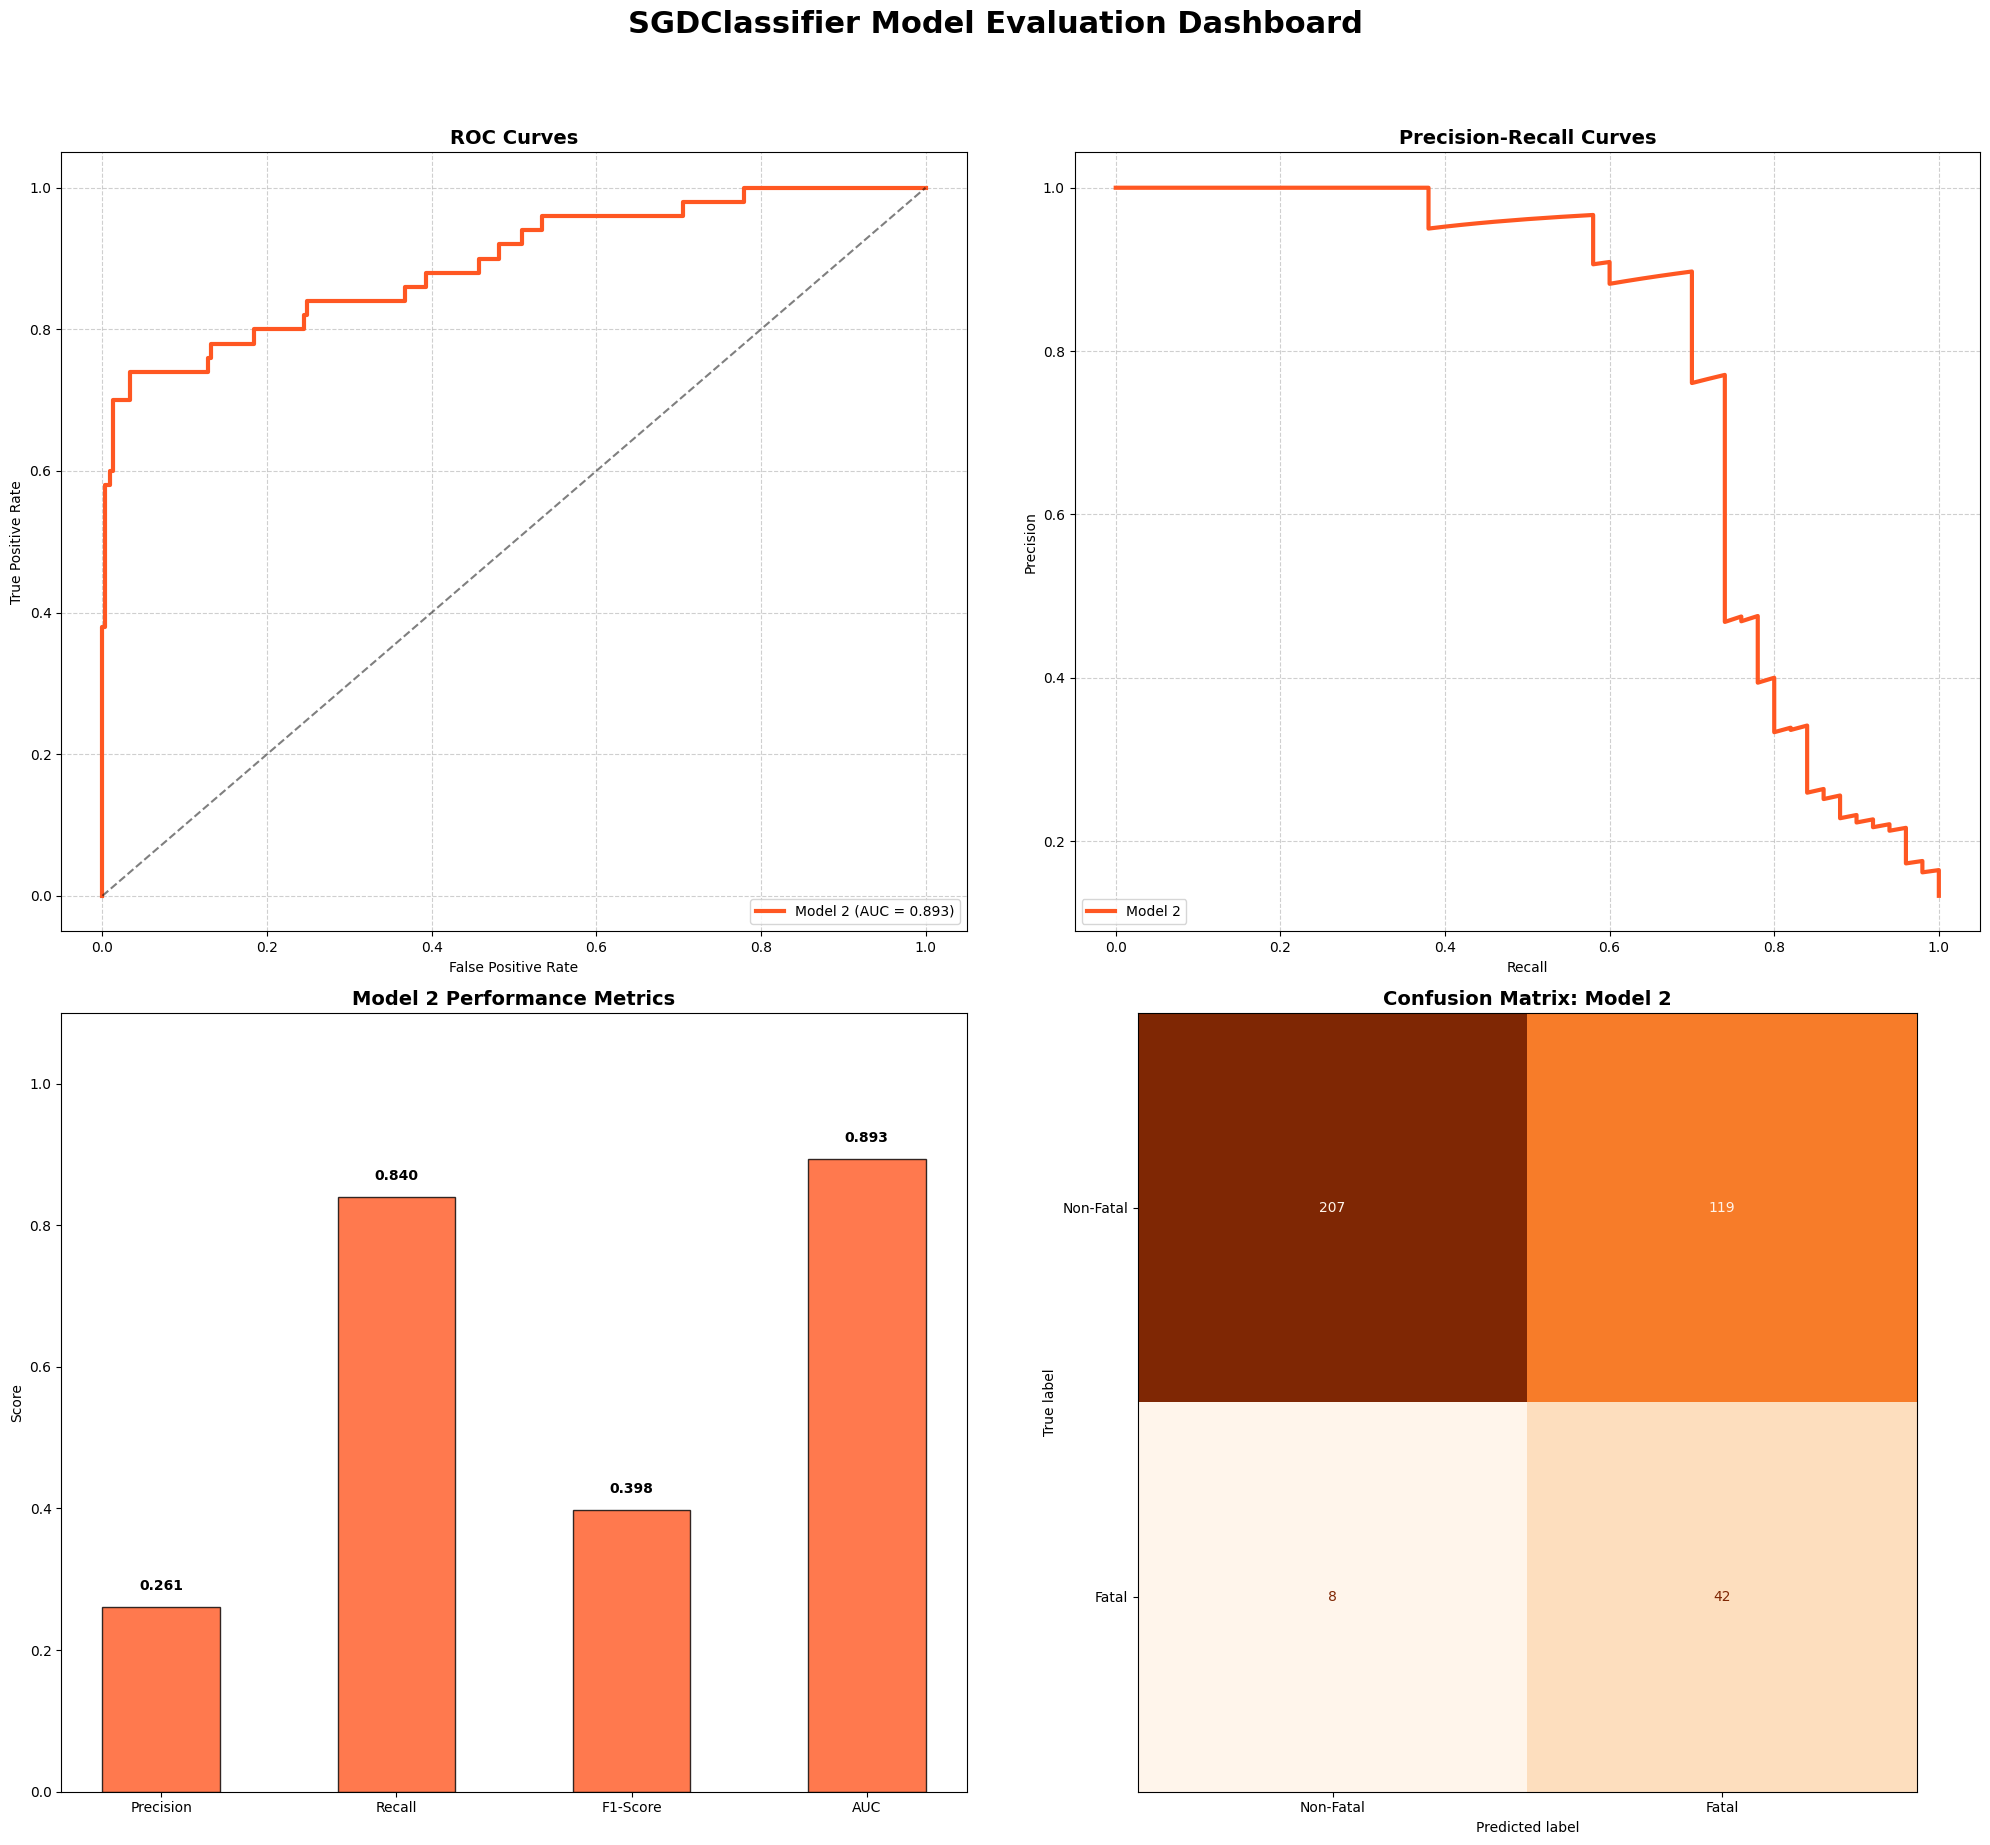

In [40]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.gridspec as gridspec

COLORS = ['#2196F3', '#FF5722', '#4CAF50']

# Configuration for the consolidated figure
fig = plt.figure(figsize=(20, 20))
fig.suptitle('SGDClassifier Model Evaluation Dashboard', fontsize=22, fontweight='bold', y=0.95)

# --- 1. ROC CURVES ---
ax1 = plt.subplot(2, 2, 1)
# Note: For Model 2 (hinge loss), we use scores2 (decision_function)
fpr, tpr, _ = roc_curve(y_test, scores2)
ax1.plot(fpr, tpr, color=COLORS[1], linewidth=3,
         label=f"Model 2 (AUC = {metrics['Model 2']['auc']:.3f})")
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(True, linestyle='--', alpha=0.6)

# --- 2. PRECISION-RECALL CURVES ---
ax2 = plt.subplot(2, 2, 2)
prec, rec, _ = precision_recall_curve(y_test, scores2)
ax2.plot(rec, prec, color=COLORS[1], linewidth=3, label='Model 2')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curves', fontsize=14, fontweight='bold')
ax2.legend(loc='lower left')
ax2.grid(True, linestyle='--', alpha=0.6)

# --- 3. METRIC COMPARISON BAR CHART ---
ax3 = plt.subplot(2, 2, 3)
m_names = ['Precision', 'Recall', 'F1-Score', 'AUC']
m_vals = [
    metrics['Model 2']['precision'],
    metrics['Model 2']['recall'],
    metrics['Model 2']['f1'],
    metrics['Model 2']['auc']
]

bars = ax3.bar(m_names, m_vals, color=COLORS[1], alpha=0.8, edgecolor='black', width=0.5)
ax3.set_ylim(0, 1.1)
ax3.set_ylabel('Score')
ax3.set_title('Model 2 Performance Metrics', fontsize=14, fontweight='bold')

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

# --- 4. CONFUSION MATRIX ---
ax4 = plt.subplot(2, 2, 4)
cm = confusion_matrix(y_test, pred2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Fatal', 'Fatal'])
disp.plot(ax=ax4, cmap='Oranges', colorbar=False)
ax4.set_title('Confusion Matrix: Model 2', fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.92])
plt.show()

**Comparative Analysis (SVM 80-20 vs. SVM 70-30):**

*   **Precision and Reliability**: The SVM Model 2 (80-20) is significantly more precise than the SGD Model 2. While the SGD model generated 119 false alarms, the SVM model only generated 20, making it much more reliable for practical deployment.

*   **Recall Trade-off**: The SGD model achieved a higher absolute Recall (0.840 vs. 0.79), catching 42 fatalities compared to SVM's 26. However, the SVM model's F1-score of 0.66 is vastly superior to the SGD's 0.398, indicating a much better balance between catching fatalities and avoiding false positives.

*   **Overall Capability**: Both models show strong discriminative power with AUC scores near 0.87–0.89. The SVM configuration under the 80-20 split appears to be the more stable for decision-making.

In [41]:
from sklearn.metrics import confusion_matrix, recall_score, f1_score, precision_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
import numpy as np

SEP  = "=" * 70
SEP2 = "-" * 68

# Configuration for SVM Model 2 (based on your previous request)
# Format: (Name, alpha, loss, learning_rate, threshold)
svm_configs = [
    ("Model 2", 0.001, 'hinge', 'optimal', 0.0) # threshold 0.0 is the standard SVM decision boundary
]

print(SEP)
print("   SVM — OVERFITTING / UNDERFITTING DIAGNOSTIC (70-30 Split)")
print(SEP)

# Assuming model2, X_train, y_train, X_test, y_test are already defined in your environment
for name, alpha, loss, lr_type, thresh in svm_configs:

    # 1. Generate decision scores and predictions
    # Note: decision_function output > 0 is the "Fatal" class for Hinge Loss
    train_scores = model2.decision_function(X_train)
    test_scores  = model2.decision_function(X_test)

    train_preds = (train_scores >= thresh).astype(int)
    test_preds  = (test_scores  >= thresh).astype(int)

    # 2. Calculate Metrics
    train_recall = recall_score(y_train, train_preds, zero_division=0)
    test_recall  = recall_score(y_test, test_preds,  zero_division=0)
    train_f1     = f1_score(y_train, train_preds, zero_division=0)
    test_f1      = f1_score(y_test, test_preds,  zero_division=0)
    test_prec    = precision_score(y_test, test_preds, zero_division=0)
    test_auc     = roc_auc_score(y_test, test_scores)

    gap_recall   = train_recall - test_recall
    gap_f1       = train_f1    - test_f1

    # 3. Confusion Matrix Logic
    cm             = confusion_matrix(y_test, test_preds)
    tn, fp, fn, tp = cm.ravel()
    total_fatal    = tp + fn

    # 4. Verdict Logic
    if test_recall < 0.60:
        verdict = "UNDERFITTING — fatal recall too low"
    elif test_prec < 0.15:
        verdict = "DEGENERATE   — precision too low"
    elif gap_recall > 0.15:
        verdict = "OVERFITTING  — significant recall drop"
    elif gap_f1 > 0.10:
        verdict = "MILD OVERFIT — notable F1 gap"
    else:
        verdict = "GOOD FIT"

    print(f"\n  {name}  |  alpha={alpha}  loss={loss}  lr={lr_type}  threshold={thresh}")
    print(f"  {SEP2}")
    print(f"  {'Metric':<28}  {'Train':>8}  {'Test':>8}  {'Gap':>8}")
    print(f"  {SEP2}")
    print(f"  {'Recall (Fatal)':<28}  {train_recall:>8.4f}  {test_recall:>8.4f}  {gap_recall:>+8.4f}  <- primary")
    print(f"  {'F1-Score (Fatal)':<28}  {train_f1:>8.4f}  {test_f1:>8.4f}  {gap_f1:>+8.4f}  <- secondary")
    print(f"  {'AUC-ROC':<28}  {'  —':>8}  {test_auc:>8.4f}  {'  —':>8}")
    print(f"  {'Precision (Fatal)':<28}  {'  —':>8}  {test_prec:>8.4f}  {'  —':>8}  <- floor check")
    print(f"  {SEP2}")
    print(f"  Fatal incidents caught  :  {tp} / {total_fatal}  (missed: {fn})")
    print(f"  False alarms raised     :  {fp}")
    print(f"  Fit verdict             :  {verdict}")

print(f"\n{SEP}")

# ── 5-Fold Cross-Validation for SVM ──────────────────────────────────────────
print("\n")
print(SEP)
print("   SVM — 5-FOLD CROSS-VALIDATION")
print(SEP)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, alpha, loss, lr_type, thresh in svm_configs:
    fold_recalls = []
    fold_f1s     = []
    fold_aucs    = []

    # Use X_train_final/y_train_final if using the whole dataset for CV
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Re-initialize fresh SVM for each fold
        fold_model = SGDClassifier(loss=loss, alpha=alpha, learning_rate=lr_type, random_state=42)
        fold_model.fit(X_tr, y_tr)

        # Evaluation
        val_scores = fold_model.decision_function(X_val)
        val_preds  = (val_scores >= thresh).astype(int)

        fold_recalls.append(recall_score(y_val, val_preds, zero_division=0))
        fold_f1s.append(f1_score(y_val, val_preds, zero_division=0))
        fold_aucs.append(roc_auc_score(y_val, val_scores))

    r_mean, r_std = np.mean(fold_recalls), np.std(fold_recalls)
    stability     = "stable" if r_std <= 0.05 else "high variance — unstable"

    print(f"\n  Model {name}  |  alpha={alpha}  loss={loss}")
    print(f"  Fold Recalls :  {[round(f, 4) for f in fold_recalls]}")
    print(f"  Mean Recall  :  {r_mean:.4f}   |   Std: {r_std:.4f}   |   {stability}")
    print(f"  Mean F1      :  {np.mean(fold_f1s):.4f}")
    print(f"  Mean AUC     :  {np.mean(fold_aucs):.4f}")

print(f"\n{SEP}\n")

   SVM — OVERFITTING / UNDERFITTING DIAGNOSTIC (70-30 Split)

  Model 2  |  alpha=0.001  loss=hinge  lr=optimal  threshold=0.0
  --------------------------------------------------------------------
  Metric                           Train      Test       Gap
  --------------------------------------------------------------------
  Recall (Fatal)                  0.9605    0.8400   +0.1205  <- primary
  F1-Score (Fatal)                0.8305    0.3981   +0.4324  <- secondary
  AUC-ROC                              —    0.8933         —
  Precision (Fatal)                    —    0.2609         —  <- floor check
  --------------------------------------------------------------------
  Fatal incidents caught  :  42 / 50  (missed: 8)
  False alarms raised     :  119
  Fit verdict             :  MILD OVERFIT — notable F1 gap



   SVM — 5-FOLD CROSS-VALIDATION

  Model Model 2  |  alpha=0.001  loss=hinge
  Fold Recalls :  [0.8421, 0.8882, 0.8092, 0.8421, 0.8553]
  Mean Recall  :  0.8474   |   

### INTERFACE ###

In [42]:
from google.colab import drive
import os

drive.mount('/content/drive', force_remount=True)

path = "/content/drive/MyDrive/Colab Notebooks/Machine Learning Project"
os.chdir(path)

Mounted at /content/drive


In [43]:
%cd /content/drive/MyDrive/Colab Notebooks/Machine Learning Project
%ls

/content
Algorithms.ipynb                     Model_2_model.pth
Balanced_Training_Set_Only_70.csv    Model_2_results.png
Balanced_Training_Set_Only.csv       Model_2_roc.png
batch_32_rows_1.csv                  Model_3_model.pth
batch_32_rows_2.csv                  Model_3_results.png
batch_32_rows_3.csv                  Model_3_roc.png
batch_32_rows_4.csv                  Preprocessed_Construction_Incidents.csv
batch_32_rows_5.csv                  Standardized_Test_30.csv
combined_2x2_grid.png                Standardized_Test.csv
construction_weather_data_final.csv  Standardized_Train_70.csv
Data_Preprocessing.ipynb             Standardized_Train.csv
Model_1_model.pth                    svm_model2.pkl
Model_1_results.png                  Test_Set_Only_30.csv
Model_1_roc.png                      Test_Set_Only.csv


In [44]:
!pip install gradio pandas joblib

In [45]:
# ====================== IMPORTS ======================
import gradio as gr
import pandas as pd
import joblib

# ====================== MODEL ======================
model = joblib.load("svm_model2.pkl")

# ====================== DATA ======================
test_df = pd.read_csv("Test_Set_Only.csv")

# ====================== FEATURES ======================
FEATURES = [
    "latitude","longitude","permit_count","unique_job_types",
    "unique_work_types","residential_any","temperature","rainfall",
    "wind_speed","is_repeat_site","day_incident_pct",
    "borough_Brooklyn","borough_Manhattan","borough_Queens",
    "borough_Staten Island",
    "check2 description_Material Failure (Fell)",
    "check2 description_Mechanical Construction Equipment",
    "check2 description_Other Construction Related",
    "check2 description_Scaffold/Shoring Installations",
    "check2 description_Struck By",
    "check2 description_Worker Fell",
    "record type description_Incident",
    "record type description_Not DOB Jurisdiction",
    "record type description_Notification"
]

# ====================== PREDICTION ======================
def predict(mode, file, rows):

    try:

        # ================= BATCH MODE =================
        if mode == "Batch CSV":

            if file is None:
                return "Please upload CSV file", "", "", None

            df = pd.read_csv(file.name)

            preds = model.predict(df[FEATURES])

            results = ["Fatal" if p == 1 else "Non-Fatal" for p in preds]

            correct_fatal = sum(preds == 1)
            correct_non_fatal = sum(preds == 0)

            result_df = df.copy()
            result_df["Prediction"] = results

            return (
                "\n".join(results),
                f"Correct Fatal Predictions: {correct_fatal}",
                f"Correct Non-Fatal Predictions: {correct_non_fatal}",
                result_df
            )

        # ================= TEST MODE =================
        selected = list(rows)

        if len(selected) < 8:
            return "Select at least 8 rows", "", "", None

        if len(selected) > 32:
            return "Maximum 32 rows allowed", "", "", None

        df = test_df.iloc[selected]

        X_test = df[FEATURES]
        y = df["fatality"].values

        preds = model.predict(X_test)

        results = ["Fatal" if p == 1 else "Non-Fatal" for p in preds]

        correct_fatal = sum((preds == 1) & (y == 1))
        correct_non_fatal = sum((preds == 0) & (y == 0))

        result_df = df.copy()
        result_df["Prediction"] = results

        return (
            "\n".join(results),
            f"Correct Fatal Predictions: {correct_fatal}",
            f"Correct Non-Fatal Predictions: {correct_non_fatal}",
            result_df
        )

    except Exception as e:
        return str(e), "", "", None


# ====================== MODE SWITCH ======================
def change_mode(mode):

    if mode == "Batch CSV":
        return gr.update(visible=True), gr.update(visible=False)

    return gr.update(visible=False), gr.update(visible=True)


# ====================== PREMIUM CSS ======================
css = """

body{
    background: linear-gradient(135deg,#07131f,#0f172a,#0f766e,#2dd4bf) !important;
    font-family:'Segoe UI';
}

/* CONTAINER */
.gradio-container{
    max-width:1150px !important;
    margin:auto !important;
}

/* ================= MAIN TITLE (BLACK) ================= */
h1{
    text-align:center;
    color:#0f172a !important;
    font-size:42px !important;
    font-weight:800 !important;
}

/* ================= SUBTITLE ================= */
h3{
    text-align:center;
    color:#38bdf8 !important;
    font-weight:600 !important;
}

/* ================= CARD ================= */
.block{
    background: rgba(255,255,255,0.10) !important;
    backdrop-filter: blur(22px) !important;
    border-radius:20px !important;
    padding:18px !important;
    box-shadow: 0 0 30px rgba(0,0,0,0.35);
}

/* ================= BUTTON ================= */
button{
    background: linear-gradient(90deg,#38bdf8,#2dd4bf) !important;
    color:#0f172a !important;
    font-size:16px !important;
    font-weight:700 !important;
    border-radius:12px !important;
    transition:0.3s;
}

button:hover{
    transform:scale(1.03);
}

/* ================= LABELS ================= */
label{
    color:#0f172a !important;
    font-size:15px !important;
    font-weight:700 !important;
}

/* ================= TEXT OUTPUT ================= */
textarea{
    background: rgba(255,255,255,0.95) !important;
    color:#0f172a !important;
    font-size:16px !important;
    font-weight:600 !important;
    border-radius:14px !important;
}

/* ================= TABLE ================= */
table{
    color:#0f172a !important;
    background: rgba(255,255,255,0.95) !important;
    border-radius:12px !important;
}

/* ================= INPUT FIX ================= */
input, textarea, select, span, p{
    color:#0f172a !important;
    font-weight:600 !important;
}

/* ================= FILE UPLOAD TEXT ================= */
.file-preview,
.upload-text,
.wrap.svelte-1ipelgc{
    color:#0f172a !important;
    font-weight:600 !important;
}

/* ================= RADIO ================= */
.gr-radio label{
    color:#0f172a !important;
    font-weight:700 !important;
}

/* ================= SCROLLBAR ================= */
::-webkit-scrollbar{
    width:8px;
}

::-webkit-scrollbar-thumb{
    background:#38bdf8;
    border-radius:10px;
}

"""

# ====================== UI ======================
with gr.Blocks(css=css) as app:

    gr.Markdown("# 🏗 Construction Incident Prediction Dashboard")
    gr.Markdown("Machine Learning Based SVM Prediction System")

    mode = gr.Radio(
        choices=["Batch CSV", "Test Set"],
        value="Batch CSV",
        label="Select Mode"
    )

    with gr.Column(visible=True) as batch_section:
        file = gr.File(label="Upload CSV File")

    with gr.Column(visible=False) as test_section:
        rows = gr.CheckboxGroup(
            choices=list(range(len(test_df))),
            label="Select Test Rows (8–32)"
        )

    btn = gr.Button("Predict Incidents")

    output = gr.Textbox(label="Prediction Results", lines=12)
    stats1 = gr.Textbox(label="Correct Fatal Predictions")
    stats2 = gr.Textbox(label="Correct Non-Fatal Predictions")
    table = gr.Dataframe(label="Result Table")

    mode.change(
        change_mode,
        inputs=mode,
        outputs=[batch_section, test_section]
    )

    btn.click(
        predict,
        inputs=[mode, file, rows],
        outputs=[output, stats1, stats2, table]
    )

# ====================== RUN ======================
app.launch(inline=True)


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c19758e162ff9f5572.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
